# Прогнозирование стоимости недвижимости

## Введение

Оценка стоимости недвижимости является одной из наиболее востребованных задач в сфере анализа данных и машинного обучения. Точное прогнозирование цен на объекты недвижимости используется агентствами, застройщиками, финансовыми организациями и частными инвесторами для принятия обоснованных решений при покупке, продаже и оценке имущества.

Стоимость объекта недвижимости зависит от множества факторов, включая площадь помещений, качество строительства, возраст здания, расположение и наличие дополнительных удобств. Выявление закономерностей между этими характеристиками и итоговой ценой позволяет построить модель, способную автоматически оценивать рыночную стоимость объектов с высокой точностью.

В рамках данного проекта будет рассмотрена задача прогнозирования стоимости жилой недвижимости на основе набора характеристик объектов с использованием различных методов машинного обучения и ансамблевых подходов.

---

## 1. Постановка задачи

В рамках данного проекта решается задача прогнозирования стоимости жилой недвижимости на основе характеристик домов и прилегающих участков. Для исследования используется набор данных **House Prices: Advanced Regression Techniques**, содержащий информацию о различных параметрах объектов недвижимости, включая площадь помещений, качество строительства, год постройки, наличие гаража, состояние подвала и другие характеристики.

Целью проекта является построение модели машинного обучения, способной максимально точно предсказывать рыночную стоимость объекта недвижимости по совокупности его признаков.

Поскольку целевая переменная **SalePrice** представляет собой непрерывную числовую величину, рассматриваемая задача относится к задачам регрессии.

Для достижения поставленной цели в проекте планируется выполнить следующие этапы:

1. Провести исследовательский анализ данных (EDA), изучить структуру набора данных, распределения признаков и выявить основные закономерности.
2. Выполнить предобработку данных, включая анализ и обработку пропущенных значений, исследование выбросов и сильно коррелирующих признаков, а также подготовку категориальных признаков для различных моделей.
3. Провести Feature Engineering и сформировать новые признаки на основе имеющихся характеристик объектов недвижимости.
4. Организовать процедуру валидации моделей с использованием K-Fold кросс-валидации.
5. Обучить и сравнить различные алгоритмы машинного обучения:
   - Linear Regression;
   - Ridge Regression;
   - Lasso Regression;
   - ElasticNet;
   - K-Nearest Neighbors;
   - Decision Tree Regressor;
   - Random Forest Regressor;
   - CatBoost Regressor;
   - LightGBM Regressor;
   - XGBoost Regressor;
   - Deep Neural Network (MLP).
6. Выполнить подбор гиперпараметров для наиболее перспективных моделей.
7. Исследовать ансамблевые методы, включая усреднение прогнозов, Voting и Stacking.
8. Сравнить результаты всех моделей и определить наиболее эффективное решение.

Для оценки качества моделей будут использоваться следующие метрики:

- **RMSE (Root Mean Squared Error)** — основная метрика качества регрессионных моделей;
- **R² (Coefficient of Determination)** — дополнительная метрика для оценки доли объяснённой дисперсии.

Итогом проекта станет сравнительный анализ различных подходов к прогнозированию стоимости недвижимости и определение модели, обеспечивающей наилучшее качество предсказаний.



### 1.1 Описание набора данных

Для выполнения проекта используется датасет **House Prices: Advanced Regression Techniques**, опубликованный на платформе Kaggle.

Набор данных содержит информацию о жилых домах, проданных в городе Эймс (штат Айова, США). Каждый объект недвижимости описывается набором признаков, характеризующих его размеры, качество строительства, техническое состояние, инфраструктуру и другие особенности.

Датасет состоит из двух файлов:

- **train.csv** — обучающая выборка, содержащая признаки объектов недвижимости и целевую переменную **SalePrice**;
- **test.csv** — тестовая выборка, содержащая только признаки объектов недвижимости.

Целевая переменная:

- **SalePrice** — фактическая стоимость продажи объекта недвижимости в долларах США.

Признаки датасета включают несколько групп характеристик:

- общие сведения об объекте недвижимости;
- площадь земельного участка;
- площадь жилых и вспомогательных помещений;
- качество и состояние здания;
- характеристики подвала;
- характеристики гаража;
- наличие дополнительных построек и элементов благоустройства;
- временные характеристики, связанные с годом постройки и продажи объекта.

Набор данных содержит как числовые, так и категориальные признаки, а также пропущенные значения, что делает его подходящим для изучения полного цикла построения моделей машинного обучения: от анализа и подготовки данных до построения ансамблевых решений и сравнения их эффективности.

### 1.2 Импорты

In [ ]:
import warnings
import copy
import random

import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.base import clone, BaseEstimator, TransformerMixin

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



In [2]:
# --------------------
# Воспроизводимость
# --------------------

RANDOM_STATE = 42

# Кросс-валидация
N_SPLITS = 5
CV_SHUFFLE = True

# Метрики
RMSE_SCORING = "neg_root_mean_squared_error"
R2_SCORING = "r2"

# Для строгой воспроизводимости используем один поток
N_JOBS = 1

# Optuna
N_TRIALS = 50

# DNN
BATCH_SIZE = 32


def set_seed(seed=RANDOM_STATE):
    """
    Фиксирует генераторы случайных чисел
    для Python, NumPy и PyTorch.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    # Настройки для CUDA, если в дальнейшем будем использовать GPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Детерминированные алгоритмы PyTorch
    torch.use_deterministic_algorithms(True)

    # Дополнительные настройки CUDA/cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_generator(seed=RANDOM_STATE):
    """
    Создаёт отдельный генератор PyTorch
    с фиксированным seed для DataLoader.
    """

    generator = torch.Generator()
    generator.manual_seed(seed)

    return generator


# Зафиксируем seed в начале работы notebook
set_seed()

### 1.3 Загрузка данных

In [ ]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

## 2. EDA

### 2.1 Предварительный анализ данных 

In [4]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [5]:
train_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
train_df.describe().round(2)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.00,1460.0,1201.00,1460.00,1460.00,1460.00,1460.00,1460.00,1452.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1379.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.0
mean,730.50,56.9,70.05,10516.83,6.10,5.58,1971.27,1984.87,103.69,443.64,46.55,567.24,1057.43,1162.63,346.99,5.84,1515.46,0.43,0.06,1.57,0.38,2.87,1.05,6.52,0.61,1978.51,1.77,472.98,94.24,46.66,21.95,3.41,15.06,2.76,43.49,6.32,2007.82,180921.2
std,421.61,42.3,24.28,9981.26,1.38,1.11,30.20,20.65,181.07,456.10,161.32,441.87,438.71,386.59,436.53,48.62,525.48,0.52,0.24,0.55,0.50,0.82,0.22,1.63,0.64,24.69,0.75,213.80,125.34,66.26,61.12,29.32,55.76,40.18,496.12,2.70,1.33,79442.5
min,1.00,20.0,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,0.00,0.00,334.00,0.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,1900.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00,34900.0
25%,365.75,20.0,59.00,7553.50,5.00,5.00,1954.00,1967.00,0.00,0.00,0.00,223.00,795.75,882.00,0.00,0.00,1129.50,0.00,0.00,1.00,0.00,2.00,1.00,5.00,0.00,1961.00,1.00,334.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00,129975.0
50%,730.50,50.0,69.00,9478.50,6.00,5.00,1973.00,1994.00,0.00,383.50,0.00,477.50,991.50,1087.00,0.00,0.00,1464.00,0.00,0.00,2.00,0.00,3.00,1.00,6.00,1.00,1980.00,2.00,480.00,0.00,25.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00,163000.0
75%,1095.25,70.0,80.00,11601.50,7.00,6.00,2000.00,2004.00,166.00,712.25,0.00,808.00,1298.25,1391.25,728.00,0.00,1776.75,1.00,0.00,2.00,1.00,3.00,1.00,7.00,1.00,2002.00,2.00,576.00,168.00,68.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00,214000.0
max,1460.00,190.0,313.00,215245.00,10.00,9.00,2010.00,2010.00,1600.00,5644.00,1474.00,2336.00,6110.00,4692.00,2065.00,572.00,5642.00,3.00,2.00,3.00,2.00,8.00,3.00,14.00,3.00,2010.00,4.00,1418.00,857.00,547.00,552.00,508.00,480.00,738.00,15500.00,12.00,2010.00,755000.0


In [8]:
train_df.describe(include=['object'])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,3,157,49,1267,1198


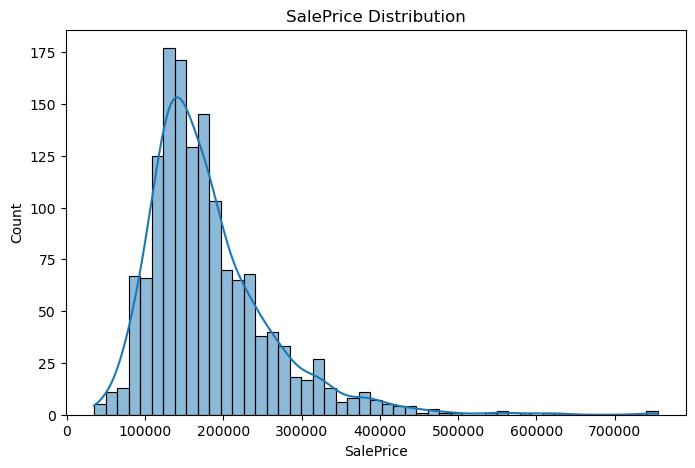

In [9]:
#  Распределение целевой переменной
plt.figure(figsize=(8, 5))
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("SalePrice Distribution");

In [10]:
# длинный хвост справа (есть дорогие дома-выбросы).
train_df["SalePrice"].skew()

np.float64(1.8828757597682129)

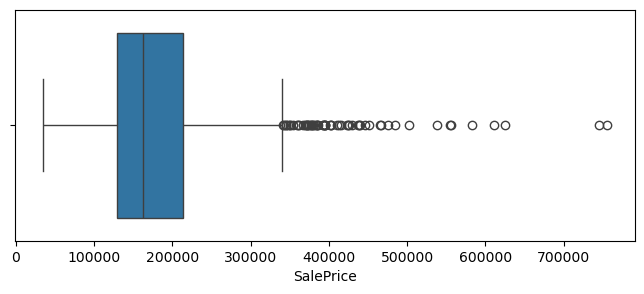

In [11]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=train_df["SalePrice"]);

In [12]:
# Посчитаем количество пропусков.
missing_df = pd.DataFrame({
    "Train Missing": train_df.isnull().sum(),
    "Train %": round(train_df.isnull().mean() * 100, 2),
    "Test Missing": test_df.isnull().sum(),
    "Test %": round(test_df.isnull().mean() * 100, 2)
})

missing_df = missing_df[
    (missing_df["Train Missing"] > 0) |
    (missing_df["Test Missing"] > 0)
].sort_values("Train %", ascending=False)

missing_df

,Train Missing,Train %,Test Missing,Test %
PoolQC,1453,99.52,1456.0,99.79
MiscFeature,1406,96.30,1408.0,96.50
Alley,1369,93.77,1352.0,92.67
Fence,1179,80.75,1169.0,80.12
MasVnrType,872,59.73,894.0,61.27
FireplaceQu,690,47.26,730.0,50.03
LotFrontage,259,17.74,227.0,15.56
GarageFinish,81,5.55,78.0,5.35
GarageCond,81,5.55,78.0,5.35
GarageYrBlt,81,5.55,78.0,5.35


In [13]:
# Посмотрим корреляции числовых признаков с SalePrice, возьмем по модулю
corr = train_df.select_dtypes(include=np.number).corr()

sale_corr = (
    corr["SalePrice"]
    .abs()
    .sort_values(ascending=False)
)

sale_corr.head(20)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
Name: SalePrice, dtype: float64

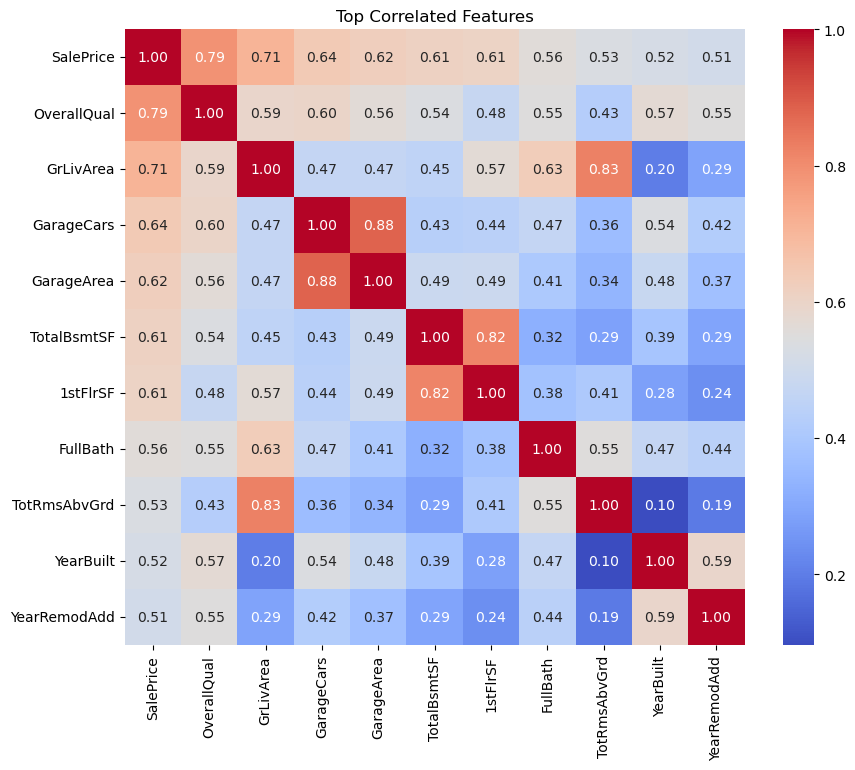

In [14]:
top_features = sale_corr.abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Correlated Features");

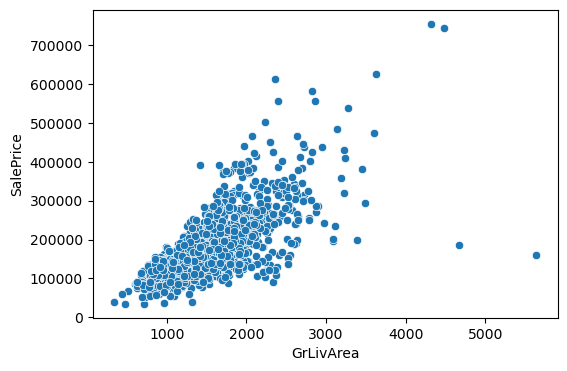

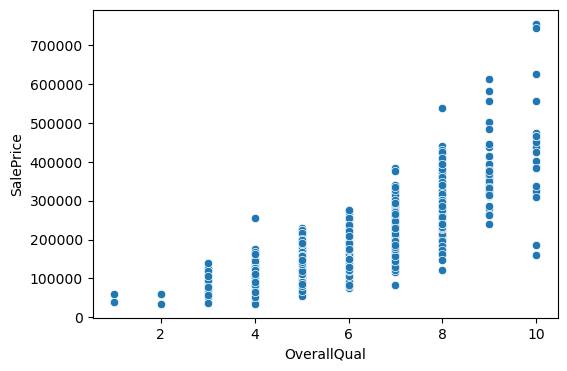

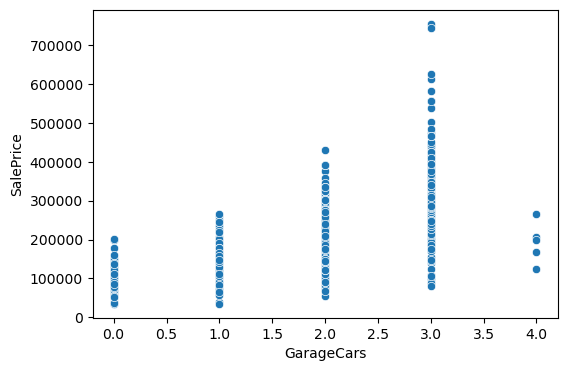

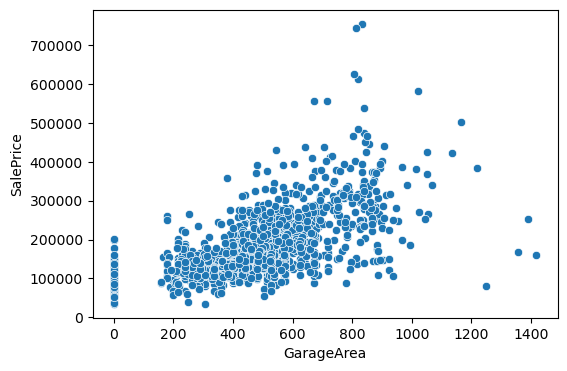

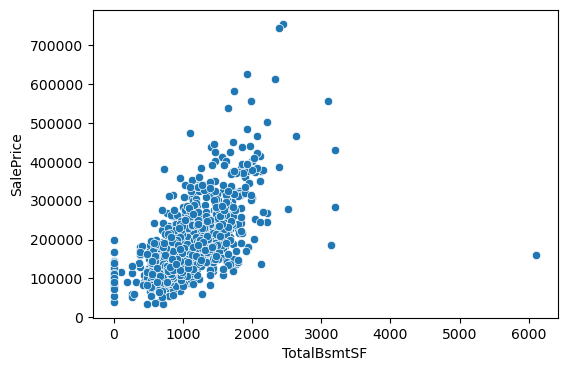

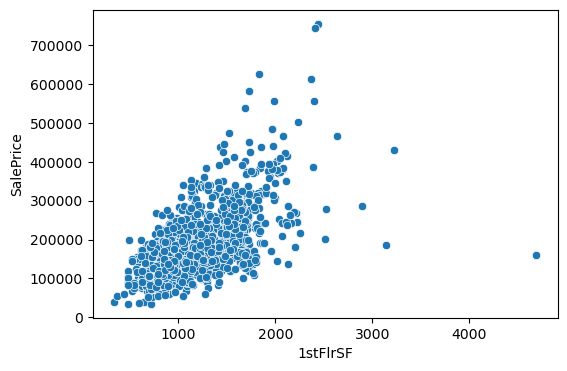

In [15]:
#  Построим Scatterplot для лучших признаков
important_features = [
    "GrLivArea",
    "OverallQual",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF"
]

for feature in important_features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=train_df,
        x=feature,
        y="SalePrice"
    )

In [16]:
#  Посмотрим категориальные признаки
cat_features = train_df.select_dtypes(include="object").columns
cat_features.shape

(43,)

In [17]:
# Посмотрим количество уникальных значений в категориальных признаках
cat_unique = train_df[cat_features].nunique().sort_values(ascending=False)

cat_unique

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

In [18]:
# Выберем несколько категориальных признаков для визуального анализа.
# Признаки выбраны по смыслу и предположительно могут влиять на SalePrice.

eda_cat_features = [
    "Neighborhood",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageFinish",
    "HouseStyle"
]

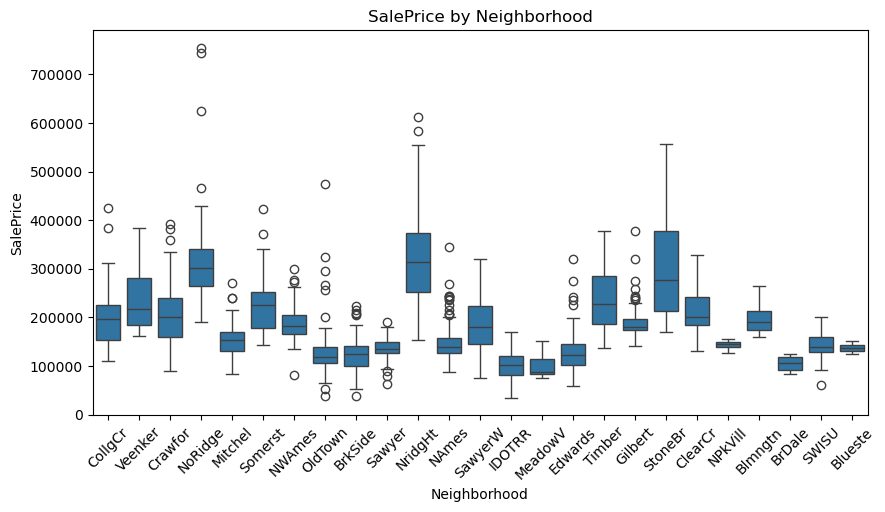

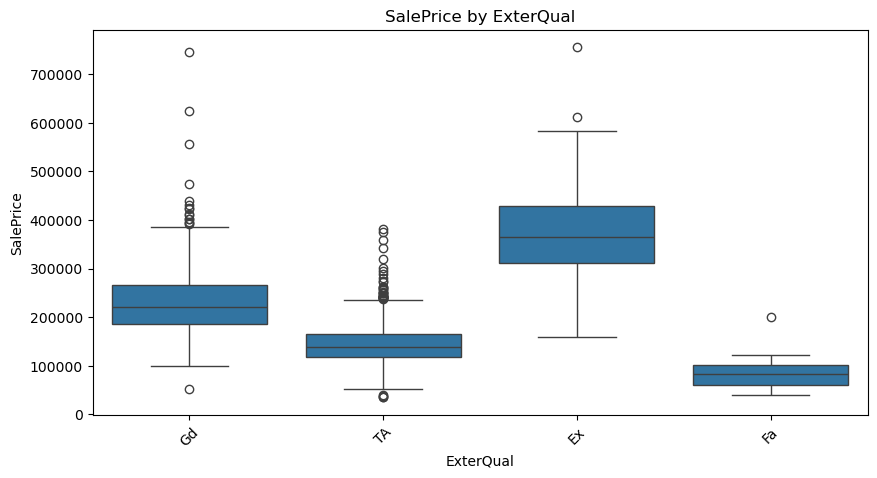

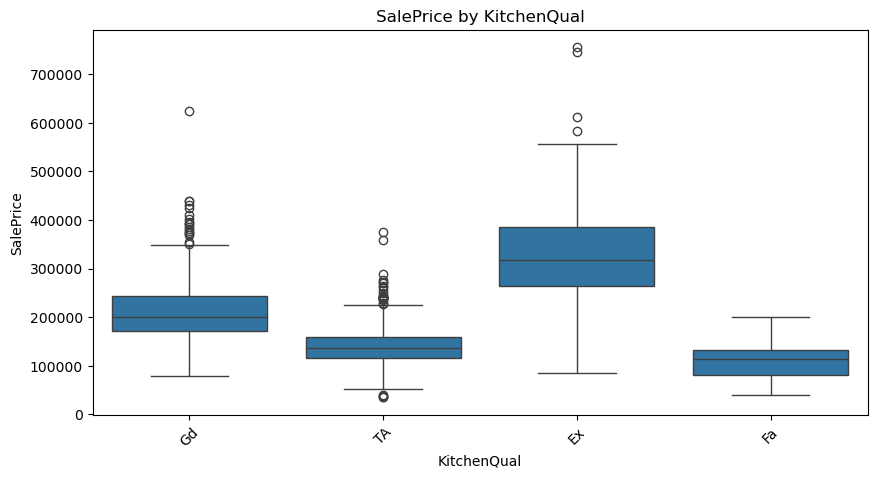

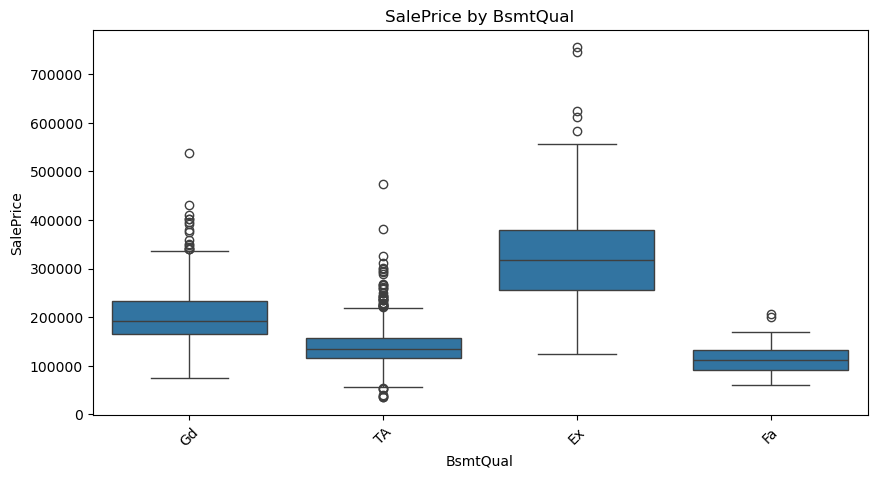

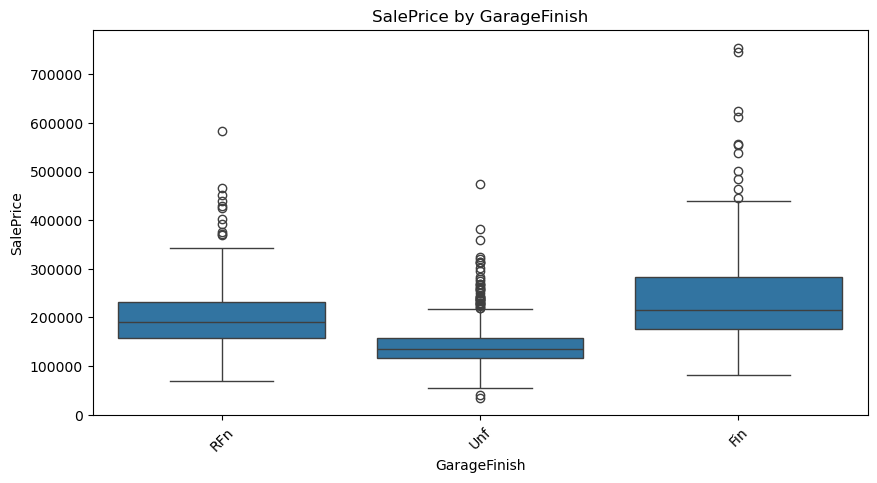

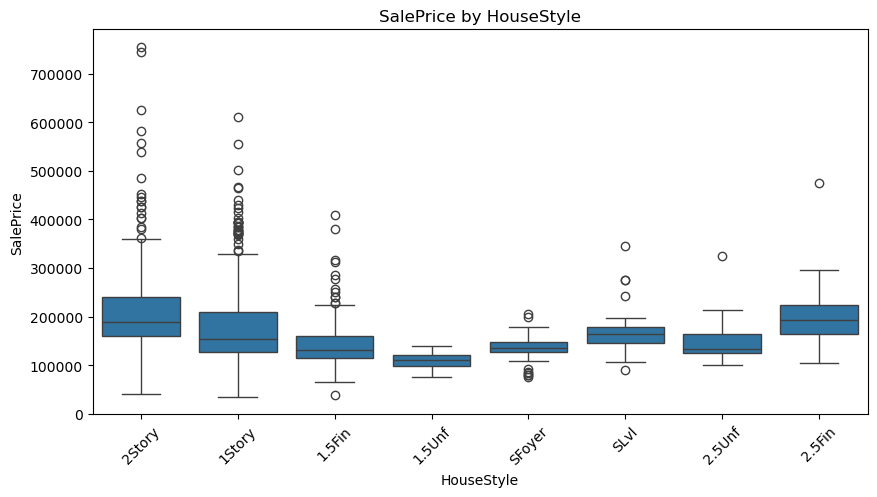

In [19]:
# Посмотрим распределение SalePrice для выбранных категориальных признаков
for feature in eda_cat_features:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        data=train_df,
        x=feature,
        y="SalePrice"
    )

    plt.title(f"SalePrice by {feature}")
    plt.xticks(rotation=45);

### Выводы по EDA

- Целевая переменная `SalePrice` имеет правостороннюю асимметрию: большинство домов находится в среднем ценовом диапазоне, но присутствуют дорогие объекты и выбросы.
- В данных присутствуют пропуски, которые потребуют отдельного анализа на этапе подготовки данных.
- Наиболее сильную связь с `SalePrice` показывают признаки, характеризующие качество дома, площадь жилых помещений и размер гаража.
- Scatterplot подтверждает положительную зависимость между площадью, качеством дома и его стоимостью.
- Категориальные признаки также влияют на цену недвижимости. Особенно заметны различия между районами и уровнями качества отделки.
- На следующем этапе необходимо обработать пропуски и подготовить данные для обучения моделей.

### 2.2 Обработка пропусков

В датасете есть признаки, где пропуск означает не ошибку в данных, а отсутствие объекта: например, отсутствие гаража, подвала, камина, бассейна или забора.

Такие пропуски будем заполнять отдельным значением `"None"`.

In [20]:
# Функция заполнения категориальных признаков значением "None"
def fill_none_features(df, features):

    for feature in features:
        df[feature] = df[feature].fillna("None")

    return df

# Признаки, где пропуск означает отсутствие объекта
none_features = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

# Заполним пропуски значением "None"
train_df = fill_none_features(train_df, none_features)
test_df = fill_none_features(test_df, none_features)

In [21]:
# Посмотрим, какие пропуски остались после заполнения значением "None"
missing_df = pd.DataFrame({
    "Train Missing": train_df.isnull().sum(),
    "Train %": round(train_df.isnull().mean() * 100, 2),
    "Test Missing": test_df.isnull().sum(),
    "Test %": round(test_df.isnull().mean() * 100, 2)
})

missing_df = missing_df[
    (missing_df["Train Missing"] > 0) |
    (missing_df["Test Missing"] > 0)
].sort_values("Train %", ascending=False)

missing_df

,Train Missing,Train %,Test Missing,Test %
LotFrontage,259,17.74,227.0,15.56
GarageYrBlt,81,5.55,78.0,5.35
MasVnrArea,8,0.55,15.0,1.03
Electrical,1,0.07,0.0,0.00
BsmtFullBath,0,0.00,2.0,0.14
BsmtFinSF1,0,0.00,1.0,0.07
BsmtFinSF2,0,0.00,1.0,0.07
Exterior2nd,0,0.00,1.0,0.07
BsmtHalfBath,0,0.00,2.0,0.14
BsmtUnfSF,0,0.00,1.0,0.07


Теперь обработаем числовые признаки, где пропуск означает отсутствие объекта.  
Например, если у дома нет гаража, то площадь гаража и год постройки гаража отсутствуют.

In [22]:
# Заполнение числовых признаков нулём
def fill_zero_features(df, features):

    for feature in features:
        df[feature] = df[feature].fillna(0)

    return df

# Числовые признаки, где пропуск означает отсутствие объекта
zero_features = [
    "GarageYrBlt",
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

# Заполним пропуски нулём
train_df = fill_zero_features(train_df, zero_features)
test_df = fill_zero_features(test_df, zero_features)

In [23]:
# Посмотрим, какие пропуски остались после заполнения числовых признаков нулём
missing_df = pd.DataFrame({
    "Train Missing": train_df.isnull().sum(),
    "Train %": round(train_df.isnull().mean() * 100, 2),
    "Test Missing": test_df.isnull().sum(),
    "Test %": round(test_df.isnull().mean() * 100, 2)
})

missing_df = missing_df[
    (missing_df["Train Missing"] > 0) |
    (missing_df["Test Missing"] > 0)
].sort_values("Train %", ascending=False)

missing_df

,Train Missing,Train %,Test Missing,Test %
LotFrontage,259,17.74,227.0,15.56
Electrical,1,0.07,0.0,0.00
Exterior1st,0,0.00,1.0,0.07
Functional,0,0.00,2.0,0.14
Exterior2nd,0,0.00,1.0,0.07
KitchenQual,0,0.00,1.0,0.07
MSZoning,0,0.00,4.0,0.27
SaleType,0,0.00,1.0,0.07
Utilities,0,0.00,2.0,0.14


#### Обработка признака LotFrontage

Признак `LotFrontage` показывает длину участка вдоль улицы.

Заполнять пропуски средним значением по всему датасету не совсем корректно, так как размеры участков могут существенно различаться в разных районах.

Поэтому будем заполнять пропуски медианным значением внутри каждого района (`Neighborhood`).

In [24]:
# Трансформер для заполнения LotFrontage медианой по району
class LotFrontageImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):

        # Рассчитаем медиану LotFrontage для каждого района
        # только по данным, переданным в fit
        self.neighborhood_medians_ = (
            X.groupby("Neighborhood")["LotFrontage"].median()
        )

        # Общая медиана будет использоваться,
        # если в новых данных встретится неизвестный район
        self.global_median_ = X["LotFrontage"].median()

        return self


    def transform(self, X):

        X = X.copy()

        # Для каждого объекта сопоставим медиану его района
        neighborhood_values = X["Neighborhood"].map(
            self.neighborhood_medians_
        )

        # Заполним пропуски медианой соответствующего района
        X["LotFrontage"] = X["LotFrontage"].fillna(
            neighborhood_values
        )

        # Если район не встречался при fit,
        # используем общую медиану обучающих данных
        X["LotFrontage"] = X["LotFrontage"].fillna(
            self.global_median_
        )

        return X

In [25]:
# Посмотрим, какие пропуски будут обработаны внутри Pipeline
missing_df = pd.DataFrame({
    "Train Missing": train_df.isnull().sum(),
    "Train %": round(train_df.isnull().mean() * 100, 2),
    "Test Missing": test_df.isnull().sum(),
    "Test %": round(test_df.isnull().mean() * 100, 2)
})

missing_df = missing_df[
    (missing_df["Train Missing"] > 0) |
    (missing_df["Test Missing"] > 0)
].sort_values("Train %", ascending=False)

missing_df

,Train Missing,Train %,Test Missing,Test %
LotFrontage,259,17.74,227.0,15.56
Electrical,1,0.07,0.0,0.00
Exterior1st,0,0.00,1.0,0.07
Functional,0,0.00,2.0,0.14
Exterior2nd,0,0.00,1.0,0.07
KitchenQual,0,0.00,1.0,0.07
MSZoning,0,0.00,4.0,0.27
SaleType,0,0.00,1.0,0.07
Utilities,0,0.00,2.0,0.14


#### Обработка оставшихся категориальных признаков

В оставшихся категориальных признаках количество пропусков очень небольшое.

Для таких случаев будем использовать наиболее часто встречающееся значение (моду).

Чтобы избежать утечки данных при кросс-валидации, мода будет рассчитываться внутри `Pipeline` только по обучающей части каждого fold.

In [26]:
# Заполнение пропусков модой
# Категориальные признаки, пропуски в которых
# будут заполняться модой внутри Pipeline
mode_features = [
    "Electrical",
    "Exterior1st",
    "Exterior2nd",
    "Functional",
    "KitchenQual",
    "MSZoning",
    "SaleType",
    "Utilities"
]

In [27]:
# Признаки, пропуски в которых будут обработаны внутри Pipeline
pipeline_missing_features = [
    "LotFrontage",
    *mode_features
]

# Найдём признаки с пропусками
train_missing_features = train_df.columns[
    train_df.isnull().any()
].tolist()

test_missing_features = test_df.columns[
    test_df.isnull().any()
].tolist()

# Проверим, нет ли неожиданных пропусков
unexpected_train_missing = [
    feature
    for feature in train_missing_features
    if feature not in pipeline_missing_features
]

unexpected_test_missing = [
    feature
    for feature in test_missing_features
    if feature not in pipeline_missing_features
]

print("Неожиданные пропуски в train:", unexpected_train_missing)
print("Неожиданные пропуски в test:", unexpected_test_missing)

Неожиданные пропуски в train: []
Неожиданные пропуски в test: []


#### Вывод

Пропуски были разделены по смыслу признаков и способу обработки:

- отсутствие объектов (гаража, подвала, бассейна и др.) заполнено значением `"None"`;
- числовые признаки, связанные с отсутствующими объектами, заполнены нулём;
- пропуски в `LotFrontage` будут заполняться медианой внутри района (`Neighborhood`);
- оставшиеся редкие категориальные пропуски будут заполняться модой.

Статистические значения для `LotFrontage` и категориальных признаков рассчитываются внутри `Pipeline` только по обучающей части данных. Это позволяет избежать использования информации из validation fold при кросс-валидации.

### 2.3 Feature Engineering

Цель данного этапа — добавить признаки, которые могут лучше описывать характеристики недвижимости и повысить качество модели.

#### Общая площадь дома

In [28]:
# Общая площадь дома
# сейчас площадь разбита на несколько признаков
def create_total_sf(df):

    df["TotalSF"] = (
        df["TotalBsmtSF"] +
        df["1stFlrSF"] +
        df["2ndFlrSF"]
    )

    return df

train_df = create_total_sf(train_df)
test_df = create_total_sf(test_df)

In [29]:
train_df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


In [30]:
# Корреляция нового признака с целевой переменной
train_df[["TotalSF", "SalePrice"]].corr()

,TotalSF,SalePrice
TotalSF,1.00000,0.78226
SalePrice,0.78226,1.00000


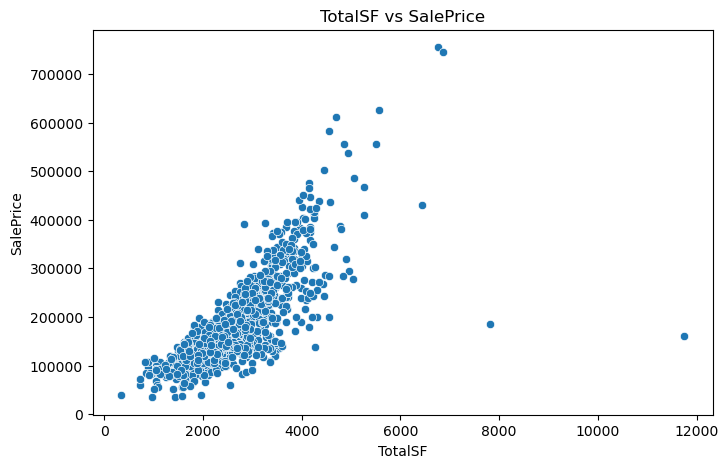

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x="TotalSF",
    y="SalePrice"
)

plt.title("TotalSF vs SalePrice");

Новый признак `TotalSF` объединяет площадь подвала, первого и второго этажей.

График показывает положительную зависимость между общей площадью дома и стоимостью недвижимости, поэтому признак может быть полезен для модели.

#### Возраст дома

Стоимость недвижимости может зависеть не только от её площади, но и от возраста здания.
Создадим признак, который показывает возраст дома на момент продажи.

In [32]:
# Возраст дома на момент продажи
def create_house_age(df):

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    return df

train_df = create_house_age(train_df)
test_df = create_house_age(test_df)

In [33]:
train_df[["YearBuilt", "YrSold", "HouseAge"]].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


In [34]:
# Корреляция нового признака с целевой переменной
train_df[["HouseAge", "SalePrice"]].corr()

,HouseAge,SalePrice
HouseAge,1.00000,-0.52335
SalePrice,-0.52335,1.00000


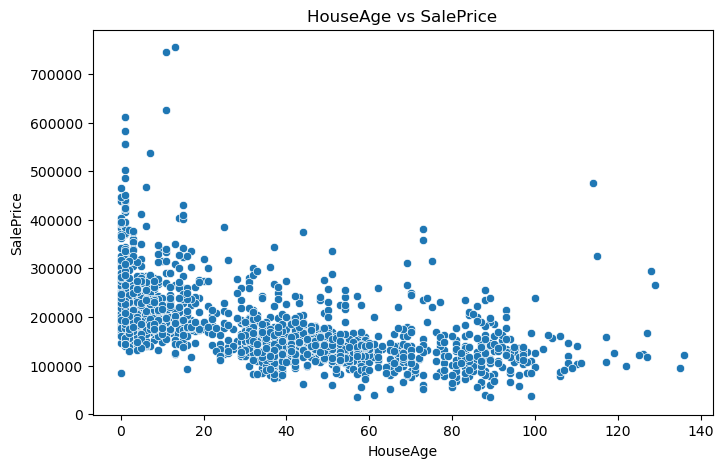

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x="HouseAge",
    y="SalePrice"
)

plt.title("HouseAge vs SalePrice");

Возраст дома имеет обратную связь со стоимостью недвижимости: более новые дома, как правило, стоят дороже.

Поэтому признак `HouseAge` может быть полезен для модели.

#### Возраст последнего ремонта
Признак показывает, сколько лет прошло с момента последнего ремонта на дату продажи дома.
Даже старый дом может иметь высокую стоимость после реконструкции, поэтому данный признак может содержать дополнительную информацию для модели.

In [36]:
# Возраст последнего ремонта на момент продажи
def create_remod_age(df):

    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

    return df

train_df = create_remod_age(train_df)
test_df = create_remod_age(test_df)

In [37]:
train_df[["YearRemodAdd", "YrSold", "RemodAge"]].head()

,YearRemodAdd,YrSold,RemodAge
0,2003,2008,5
1,1976,2007,31
2,2002,2008,6
3,1970,2006,36
4,2000,2008,8


In [38]:
# Корреляция нового признака с целевой переменной
train_df[["RemodAge", "SalePrice"]].corr()

,RemodAge,SalePrice
RemodAge,1.000000,-0.509079
SalePrice,-0.509079,1.000000


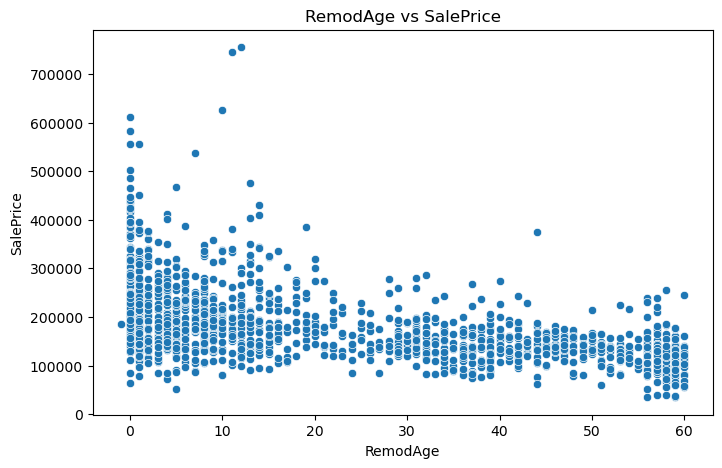

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x="RemodAge",
    y="SalePrice"
)

plt.title("RemodAge vs SalePrice");

После ремонта стоимость недвижимости обычно возрастает, поэтому возраст последнего ремонта может быть важным фактором при прогнозировании цены дома.

#### Общее количество ванных комнат
Количество санузлов является важной характеристикой жилого дома.
Объединим информацию из нескольких признаков в один показатель общего количества ванных комнат.

In [40]:
# Общее количество ванных комнат
def create_total_bathrooms(df):

    df["TotalBathrooms"] = (
        df["FullBath"] +
        0.5 * df["HalfBath"] +
        df["BsmtFullBath"] +
        0.5 * df["BsmtHalfBath"]
    )

    return df

train_df = create_total_bathrooms(train_df)
test_df = create_total_bathrooms(test_df)

In [41]:
train_df[["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", "TotalBathrooms"]].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


In [42]:
# Корреляция нового признака с целевой переменной
train_df[["TotalBathrooms", "SalePrice"]].corr()

,TotalBathrooms,SalePrice
TotalBathrooms,1.000000,0.631731
SalePrice,0.631731,1.000000


Text(0.5, 1.0, 'TotalBathrooms vs SalePrice')

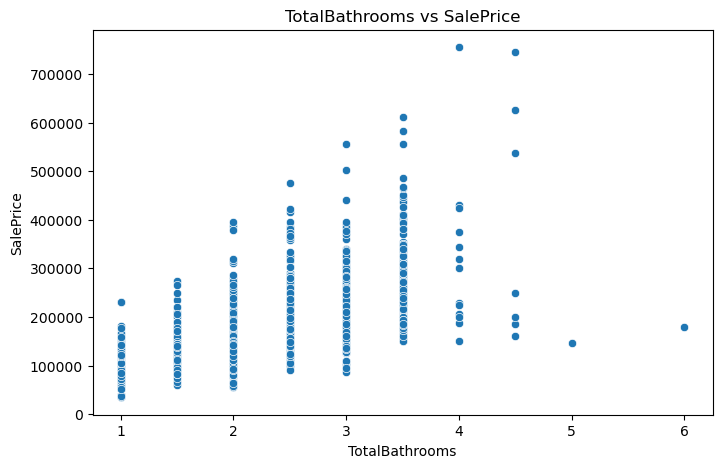

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train_df,
    x="TotalBathrooms",
    y="SalePrice"
)

plt.title("TotalBathrooms vs SalePrice")

Признак `TotalBathrooms` объединяет информацию о всех санузлах в доме.

Общее количество ванных комнат может лучше отражать удобство и функциональность жилья, чем отдельные исходные признаки.

#### Вывод

На этапе Feature Engineering были созданы новые признаки на основе существующих данных:

- `TotalSF` — общая площадь дома;
- `HouseAge` — возраст дома на момент продажи;
- `RemodAge` — возраст последнего ремонта;
- `TotalBathrooms` — общее количество ванных комнат.

Новые признаки позволяют объединить информацию из нескольких исходных признаков и лучше описывают характеристики недвижимости.

Созданные признаки имеют понятный смысл и потенциально могут улучшить качество модели.

### Выводы по разделу 2

В рамках подготовки данных был проведён исследовательский анализ датасета, выполнена обработка пропущенных значений и созданы новые признаки.

Основные результаты:

- изучена структура данных и выявлены признаки, связанные со стоимостью недвижимости;
- проанализированы числовые и категориальные признаки;
- пропуски, обозначающие отсутствие объекта, обработаны с учётом смысла данных;
- для `LotFrontage` и редких категориальных пропусков подготовлена обработка внутри Pipeline, чтобы статистические значения рассчитывались только по обучающей части данных;
- созданы новые признаки, характеризующие площадь дома, возраст здания, возраст последнего ремонта и количество ванных комнат.

После подготовки в данных остаются только те пропуски, которые будут обрабатываться внутри Pipeline. Неожиданных пропусков в train и test не осталось.

# 3. Построение Pipeline
Для обработки признаков и обучения моделей будем использовать Pipeline, что позволит объединить все этапы подготовки данных и моделирования в единую структуру.

### 3.1 Подготовка признаков

In [44]:
# Разделим признаки и целевую переменную
X_train = train_df.drop("SalePrice", axis=1)
y_train = train_df["SalePrice"]

X_test = test_df.copy()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1460, 84)
y_train shape: (1460,)
X_test shape: (1459, 84)


In [45]:
# Числовые признаки
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Категориальные признаки
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 41
Categorical features: 43


#### Вывод

Признаки были разделены на числовые и категориальные группы.
Далее для каждой группы будет построен отдельный пайплайн предобработки, после чего они будут объединены с помощью ColumnTransformer.

### 3.2 Построение Pipeline

Для числовых и категориальных признаков создадим отдельные пайплайны предобработки.

Для `LotFrontage` будем использовать отдельный трансформер `LotFrontageImputer`, который рассчитывает медианные значения по `Neighborhood` только на обучающей части данных.

После этого числовой и категориальный preprocessing объединим с помощью `ColumnTransformer`, а все этапы подготовки данных — в общий `Pipeline`.

In [46]:
# Pipeline для числовых признаков
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline для категориальных признаков
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        sparse_output=False,
        handle_unknown="ignore"
    ))
])

# Объединим обработку числовых и категориальных признаков
column_transformer = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Общий Pipeline подготовки данных
preprocessor = Pipeline([
    ("lot_frontage_imputer", LotFrontageImputer()),
    ("column_transformer", column_transformer)
])

### 3.3 Стратегия валидации
Так как размер обучающей выборки относительно небольшой, использование одной train/test выборки может привести к нестабильной оценке качества модели.

Поэтому будем применять 5-fold кросс-валидацию.

In [47]:
# Настройка кросс-валидации
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=CV_SHUFFLE,
    random_state=RANDOM_STATE if CV_SHUFFLE else None
)

cv

KFold(n_splits=5, random_state=42, shuffle=True)

Кросс-валидация позволяет более надёжно оценить качество моделей за счёт многократного разбиения данных на обучающие и валидационные выборки.

### Выводы по разделу 3

Для дальнейшего обучения моделей была подготовлена единая схема предобработки данных с использованием `Pipeline`.

Основные результаты:

- признаки разделены на числовые и категориальные;
- для `LotFrontage` создан отдельный трансформер, который заполняет пропуски медианой по `Neighborhood`;
- для числовых признаков настроены заполнение оставшихся пропусков медианой и стандартизация;
- для категориальных признаков настроены заполнение пропусков наиболее частым значением и One-Hot Encoding;
- числовой и категориальный preprocessing объединены с помощью `ColumnTransformer`;
- `LotFrontageImputer` и `ColumnTransformer` объединены в общий `Pipeline`, поэтому статистики предобработки рассчитываются только по обучающей части данных при каждом обучении модели или fold кросс-валидации;
- для оценки моделей настроена 5-fold кросс-валидация.

Такая схема позволяет одинаково обрабатывать данные для различных моделей, снижает риск утечки данных и делает сравнение результатов более корректным.

# 4. Обучение и сравнение моделей
В данном разделе будут обучены и сравнены различные модели машинного обучения для прогнозирования стоимости недвижимости.
Качество моделей будет оцениваться с помощью кросс-валидации.

### 4.1 Baseline модель - Linear Regression
В качестве базовой модели используем линейную регрессию.
Результаты данной модели будут служить отправной точкой для сравнения с более сложными алгоритмами.

In [48]:
# Список для сохранения результатов моделей
results = []

In [49]:
# Pipeline с линейной регрессией
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [50]:
# Оценим качество модели с помощью кросс-валидации
# cross_val_score возвращает отрицательное значение ошибки,
# поэтому меняем знак на положительный

rmse_scores = -cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    linear_model,
    X_train,
    y_train,
    cv=cv,
    scoring=R2_SCORING
)

linear_rmse = rmse_scores.mean()
linear_r2 = r2_scores.mean()
linear_std = rmse_scores.std()

results.append({
    "Model": "Linear Regression",
    "Target": "Original",
    "RMSE": round(linear_rmse, 2),
    "R2": round(linear_r2, 4),
    "STD": round(linear_std, 2)
})

print(f"RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f}")
print(f"R2 scores: {r2_scores}")
print(f"Mean R2: {r2_scores.mean():.2f}")
pd.DataFrame(results)

RMSE scores: [65310.6759992  28557.19990109 50702.40257779 34808.01879718
 26620.28080604]
Mean RMSE: 41199.72
R2 scores: [0.44389791 0.8800586  0.53468039 0.80704283 0.86442361]
Mean R2: 0.71


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.72,0.706,14730.15


### 4.2 Логарифмирование целевой переменной
Логарифмирование позволяет уменьшить влияние очень дорогих объектов и сделать распределение более близким к нормальному.
Проверим, как логарифмирование целевой переменной повлияет на качество линейной регрессии.

In [51]:
# Логарифмирование целевой переменной
y_train_log = np.log1p(y_train)

y_train_log.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64

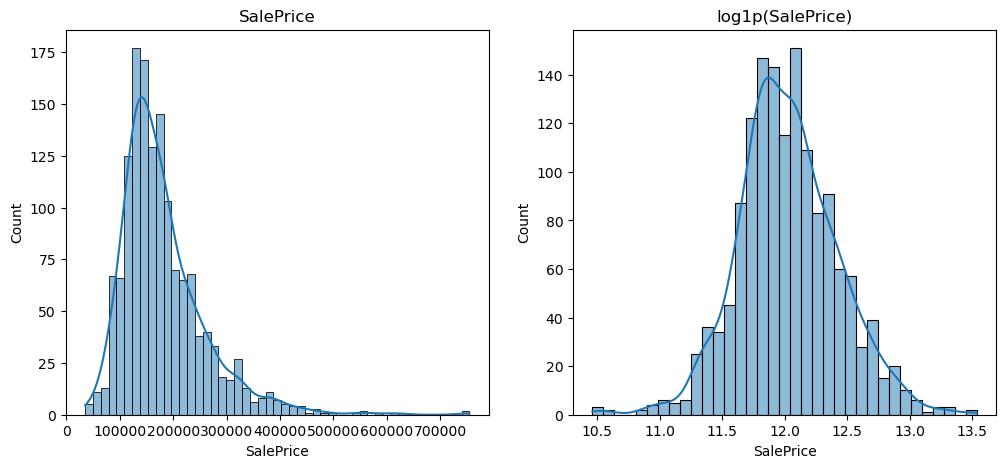

In [52]:
# Посмотрим распределение до и после преобразования.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("SalePrice")

sns.histplot(y_train_log, kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)");

In [53]:
# Pipeline с линейной регрессией
linear_model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model_log

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [54]:
# Оценим качество модели после логарифмирования целевой переменной
rmse_scores_log = -cross_val_score(
    linear_model_log,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores_log = cross_val_score(
    linear_model_log,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

# Средние значения метрик
linear_log_rmse = rmse_scores_log.mean()
linear_log_r2 = r2_scores_log.mean()
linear_log_std = rmse_scores_log.std()

results.append({
    "Model": "Linear Regression + Log Target",
    "Target": "Log",
    "RMSE": round(linear_log_rmse, 2),
    "R2": round(linear_log_r2, 2),
    "STD": round(linear_log_std, 2)
})

print(f"Mean RMSE: {linear_log_rmse:.2f}")
print(f"Mean R2: {linear_log_r2:.2f}")
pd.DataFrame(results)

Mean RMSE: 0.15
Mean R2: 0.84


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.72,0.706,14730.15
1,Linear Regression + Log Target,Log,0.15,0.840,0.04


#### Вывод

После логарифмирования целевой переменной распределение `log1p(SalePrice)` стало более симметричным и менее выраженно скошенным вправо.

После такого преобразования модель решает уже немного другую задачу: она прогнозирует `log1p(SalePrice)`, а не исходный `SalePrice`.

Поэтому значения RMSE и R² модели, обученной на исходной целевой переменной, нельзя напрямую сравнивать со значениями этих метрик для модели, обученной на логарифмированной целевой переменной.

В дальнейших экспериментах будем использовать логарифмированную целевую переменную. Все последующие модели будут обучаться и оцениваться в одной и той же логарифмической шкале, поэтому основной метрикой для их сравнения будет RMSE, а R² будем использовать как дополнительную метрику.

### 4.3 Ridge Regression
Ridge Regression — это линейная модель с L2-регуляризацией.
Регуляризация помогает уменьшить переобучение и сделать модель более устойчивой к большим коэффициентам признаков.

In [55]:
# Pipeline с Ridge Regression
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE))
])

ridge_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [56]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    ridge_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

ridge_rmse = rmse_scores.mean()
ridge_r2 = r2_scores.mean()
ridge_std = rmse_scores.std()

results.append({
    "Model": "Ridge Regression",
    "Target": "Log",
    "RMSE": round(ridge_rmse, 4),
    "R2": round(ridge_r2, 4),
    "STD": round(ridge_std, 4)
})

print(f"Mean RMSE: {ridge_rmse:.4f}")
print(f"Mean R2: {ridge_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.1479
Mean R2: 0.8457


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407


#### Вывод
Ridge Regression использует регуляризацию, поэтому может быть устойчивее обычной линейной регрессии при большом количестве признаков после One-Hot Encoding.
На следующем этапе сравним Ridge с другими линейными моделями регуляризации.

### 4.4 Lasso Regression
Lasso Regression использует L1-регуляризацию.
В отличие от Ridge Regression, Lasso может занулять коэффициенты признаков, выполняя отбор наиболее важных признаков автоматически.

In [57]:
# Pipeline с Lasso Regression
lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(random_state=RANDOM_STATE))
])

lasso_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [58]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    lasso_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    lasso_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

lasso_rmse = rmse_scores.mean()
lasso_r2 = r2_scores.mean()
lasso_std = rmse_scores.std()

results.append({
    "Model": "Lasso Regression",
    "Target": "Log",
    "RMSE": round(lasso_rmse, 4),
    "R2": round(lasso_r2, 4),
    "STD": round(lasso_std, 4)
})

print(f"Mean RMSE: {lasso_rmse:.4f}")
print(f"Mean R2: {lasso_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.3988
Mean R2: -0.0035


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407
3,Lasso Regression,Log,0.3988,-0.0035,0.0251


#### Вывод

При использовании параметров по умолчанию Lasso Regression показала качество хуже базовой линейной регрессии.

Вероятно, регуляризация оказалась слишком сильной для данной задачи. В дальнейшем будет выполнен подбор гиперпараметров модели.

### 4.5 ElasticNet
ElasticNet объединяет L1- и L2-регуляризацию.
Модель сочетает преимущества Ridge Regression и Lasso Regression: позволяет уменьшать переобучение и одновременно выполнять отбор признаков.

In [59]:
# Pipeline с ElasticNet
elastic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(random_state=RANDOM_STATE))
])

elastic_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [60]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    elastic_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    elastic_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

elastic_rmse = rmse_scores.mean()
elastic_r2 = r2_scores.mean()
elastic_std = rmse_scores.std()

results.append({
    "Model": "ElasticNet",
    "Target": "Log",
    "RMSE": round(elastic_rmse, 4),
    "R2": round(elastic_r2, 4),
    "STD": round(elastic_std, 4)
})

print(f"Mean RMSE: {elastic_rmse:.4f}")
print(f"Mean R2: {elastic_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.3988
Mean R2: -0.0035


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407
3,Lasso Regression,Log,0.3988,-0.0035,0.0251
4,ElasticNet,Log,0.3988,-0.0035,0.0251


#### Вывод

ElasticNet с параметрами по умолчанию не смог превзойти Linear Regression и Ridge Regression.
Вероятно, для данной модели требуется подбор гиперпараметров регуляризации, который будет выполнен на последующих этапах проекта.



#### Вывод по линейным моделям

Среди рассмотренных линейных моделей наилучший результат показала Ridge Regression.

После перехода к логарифмированной целевой переменной Linear Regression оценивалась уже в другой шкале, поэтому её метрики нельзя напрямую сравнивать с моделью, обученной на исходном `SalePrice`.

Lasso Regression и ElasticNet с параметрами по умолчанию показали значительно более низкое качество, что может быть связано со слишком сильной регуляризацией. Для данных моделей потребуется дополнительный подбор гиперпараметров.

### 4.6 KNN Regressor
KNN (K-Nearest Neighbors) выполняет прогноз на основе ближайших объектов в пространстве признаков.
Для нового объекта модель находит несколько наиболее похожих наблюдений и использует их значения для расчёта предсказания.
Так как алгоритм основан на расстояниях между объектами, для него особенно важна стандартизация признаков, которая уже реализована в Pipeline.

In [61]:
# Pipeline с KNN Regressor
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor())
])

knn_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [ ]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    knn_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    knn_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

knn_rmse = rmse_scores.mean()
knn_r2 = r2_scores.mean()
knn_std = rmse_scores.std()

results.append({
    "Model": "KNN Regressor",
    "Target": "Log",
    "RMSE": round(knn_rmse, 4),
    "R2": round(knn_r2, 4),
    "STD": round(knn_std, 4)
})

print(f"Mean RMSE: {knn_rmse:.4f}")
print(f"Mean R2: {knn_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.1744
Mean R2: 0.8070


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407
3,Lasso Regression,Log,0.3988,-0.0035,0.0251
4,ElasticNet,Log,0.3988,-0.0035,0.0251
5,KNN Regressor,Log,0.1744,0.8070,0.0181


#### Вывод

KNN Regressor показал более низкое качество по сравнению с Ridge Regression, но при этом продемонстрировал стабильные результаты на различных разбиениях данных.

В дальнейшем качество модели может быть улучшено за счёт подбора гиперпараметров, таких как количество соседей, способ взвешивания и метрика расстояния.

### 4.7 Decision Tree Regressor
Decision Tree Regressor строит дерево решений, последовательно разбивая объекты на группы со схожими значениями целевой переменной.

В отличие от линейных моделей, дерево способно учитывать нелинейные зависимости между признаками.

In [63]:
# Pipeline с Decision Tree Regressor
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

tree_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [64]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    tree_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    tree_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

tree_rmse = rmse_scores.mean()
tree_r2 = r2_scores.mean()
tree_std = rmse_scores.std()

results.append({
    "Model": "Decision Tree",
    "Target": "Log",
    "RMSE": round(tree_rmse, 4),
    "R2": round(tree_r2, 4),
    "STD": round(tree_std, 4)
})

print(f"Mean RMSE: {tree_rmse:.4f}")
print(f"Mean R2: {tree_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.2147
Mean R2: 0.7019


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407
3,Lasso Regression,Log,0.3988,-0.0035,0.0251
4,ElasticNet,Log,0.3988,-0.0035,0.0251
5,KNN Regressor,Log,0.1744,0.8070,0.0181
6,Decision Tree,Log,0.2147,0.7019,0.0187


#### Вывод

Decision Tree Regressor показал качество ниже, чем линейные модели с логарифмированной целевой переменной и KNN Regressor.
Вероятно, дерево решений с параметрами по умолчанию переобучается и плохо обобщает данные на новых выборках.
Для улучшения качества модели потребуется подбор гиперпараметров, таких как глубина дерева и минимальное количество объектов в узлах.
На следующем этапе рассмотрим Random Forest, который позволяет снизить переобучение за счёт объединения множества деревьев решений.

### 4.8 Random Forest Regressor
Random Forest представляет собой ансамбль деревьев решений.
Модель обучает множество деревьев на различных подвыборках данных и объединяет их прогнозы, что позволяет уменьшить переобучение и повысить качество предсказаний.

In [65]:
# Pipeline с Random Forest Regressor
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS))
])

rf_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [66]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    rf_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    rf_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

rf_rmse = rmse_scores.mean()
rf_r2 = r2_scores.mean()
rf_std = rmse_scores.std()

results.append({
    "Model": "Random Forest",
    "Target": "Log",
    "RMSE": round(rf_rmse, 4),
    "R2": round(rf_r2, 4),
    "STD": round(rf_std, 4)
})

print(f"Mean RMSE: {rf_rmse:.4f}")
print(f"Mean R2: {rf_r2:.4f}")

pd.DataFrame(results)

Mean RMSE: 0.1429
Mean R2: 0.8673


,Model,Target,RMSE,R2,STD
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
2,Ridge Regression,Log,0.1479,0.8457,0.0407
3,Lasso Regression,Log,0.3988,-0.0035,0.0251
4,ElasticNet,Log,0.3988,-0.0035,0.0251
5,KNN Regressor,Log,0.1744,0.8070,0.0181
6,Decision Tree,Log,0.2147,0.7019,0.0187
7,Random Forest,Log,0.1429,0.8673,0.0186


#### Вывод

Random Forest показал лучший результат среди рассмотренных моделей.
По сравнению с одним деревом решений качество модели существенно выросло, что подтверждает эффективность ансамблевого подхода.
Модель также продемонстрировала стабильные результаты на различных разбиениях данных, поэтому Random Forest становится текущим лидером по качеству прогнозирования стоимости недвижимости.

### 4.9 CatBoost Regressor
CatBoost — это градиентный бустинг, который хорошо работает с табличными данными и умеет обрабатывать категориальные признаки.
В отличие от предыдущих моделей, для CatBoost не будем использовать общий preprocessor с One-Hot Encoding. Вместо этого передадим категориальные признаки напрямую.

In [67]:
# ColumnTransformer для CatBoost
catboost_column_transformer = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", SimpleImputer(strategy="most_frequent"), categorical_features)
])

# Preprocessor для CatBoost
catboost_preprocessor = Pipeline([
    ("lot_frontage_imputer", LotFrontageImputer()),
    ("column_transformer", catboost_column_transformer)
])

# Индексы категориальных признаков после preprocessor
cat_features_idx = list(
    range(
        len(numeric_features),
        len(numeric_features) + len(categorical_features)
    )
)
# Pipeline с CatBoost Regressor
catboost_model = Pipeline([
    ("preprocessor", catboost_preprocessor),
    ("model", CatBoostRegressor(random_state=RANDOM_STATE, verbose=False, cat_features=cat_features_idx, thread_count=N_JOBS))
])

catboost_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [68]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    catboost_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    catboost_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

catboost_rmse = rmse_scores.mean()
catboost_r2 = r2_scores.mean()
catboost_std = rmse_scores.std()

results.append({
    "Model": "CatBoost",
    "Target": "Log",
    "RMSE": round(catboost_rmse, 4),
    "R2": round(catboost_r2, 4),
    "STD": round(catboost_std, 4)
})

print(f"Mean RMSE: {catboost_rmse:.4f}")
print(f"Mean R2: {catboost_r2:.4f}")


pd.DataFrame(results).sort_values(by="R2", ascending=False)

Mean RMSE: 0.1241
Mean R2: 0.9004


,Model,Target,RMSE,R2,STD
8,CatBoost,Log,0.1241,0.9004,0.0154
7,Random Forest,Log,0.1429,0.8673,0.0186
2,Ridge Regression,Log,0.1479,0.8457,0.0407
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
5,KNN Regressor,Log,0.1744,0.8070,0.0181
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
6,Decision Tree,Log,0.2147,0.7019,0.0187
4,ElasticNet,Log,0.3988,-0.0035,0.0251
3,Lasso Regression,Log,0.3988,-0.0035,0.0251


#### Вывод

CatBoost показал лучший результат среди всех рассмотренных моделей.

По сравнению с Random Forest качество модели заметно улучшилось, что свидетельствует о преимуществах градиентного бустинга для задачи прогнозирования стоимости недвижимости.

Модель также продемонстрировала стабильные результаты на различных разбиениях данных и становится текущим лидером по качеству прогнозирования.

### 4.10 LightGBM Regressor
LightGBM — это алгоритм градиентного бустинга, разработанный для эффективной работы с большими объёмами данных и большим количеством признаков.
Модель строит деревья решений последовательно, исправляя ошибки предыдущих деревьев и постепенно улучшая качество прогнозов.

In [69]:
# ColumnTransformer
# ↓
# часть данных становится numpy array
# ↓
# LightGBM ожидает DataFrame с именами колонок
# ↓
# получает массив
# ↓
# выводит предупреждение
# На качество модели это никак не влияет.
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names*"
)

In [70]:
# Pipeline с LightGBM Regressor
lgbm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS))
])

lgbm_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [71]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    lgbm_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    lgbm_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

# Средние значения метрик
lgbm_rmse = rmse_scores.mean()
lgbm_r2 = r2_scores.mean()
lgbm_std = rmse_scores.std()

results.append({
    "Model": "LightGBM",
    "Target": "Log",
    "RMSE": round(lgbm_rmse, 4),
    "R2": round(lgbm_r2, 4),
    "STD": round(lgbm_std, 4)
})

print(f"Mean RMSE: {lgbm_rmse:.4f}")
print(f"Mean R2: {lgbm_r2:.4f}")

pd.DataFrame(results).sort_values(by="R2", ascending=False)

Mean RMSE: 0.1330
Mean R2: 0.8854


,Model,Target,RMSE,R2,STD
8,CatBoost,Log,0.1241,0.9004,0.0154
9,LightGBM,Log,0.1330,0.8854,0.0167
7,Random Forest,Log,0.1429,0.8673,0.0186
2,Ridge Regression,Log,0.1479,0.8457,0.0407
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
5,KNN Regressor,Log,0.1744,0.8070,0.0181
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
6,Decision Tree,Log,0.2147,0.7019,0.0187
4,ElasticNet,Log,0.3988,-0.0035,0.0251
3,Lasso Regression,Log,0.3988,-0.0035,0.0251


#### Вывод

LightGBM показал высокое качество прогнозирования и вошёл в число лучших моделей проекта.

Несмотря на результат лучше большинства ранее рассмотренных алгоритмов, модель уступила CatBoost по качеству прогнозирования.

В дальнейшем качество LightGBM может быть улучшено за счёт подбора гиперпараметров.

### 4.11 XGBoost Regressor
XGBoost — один из наиболее популярных алгоритмов градиентного бустинга.
Модель последовательно строит деревья решений, исправляя ошибки предыдущих итераций и повышая качество прогнозирования.
Благодаря высокой эффективности и гибкости XGBoost часто используется в соревнованиях по машинному обучению и задачах прогнозирования на табличных данных.

In [72]:
# Pipeline с XGBoost Regressor
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS))
])

xgb_model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('lot_frontage_imputer', ...), ('column_transformer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [73]:
# Оценим качество модели с помощью кросс-валидации
rmse_scores = -cross_val_score(
    xgb_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

# Средние значения метрик
xgb_rmse = rmse_scores.mean()
xgb_r2 = r2_scores.mean()
xgb_std = rmse_scores.std()

results.append({
    "Model": "XGBoost",
    "Target": "Log",
    "RMSE": round(xgb_rmse, 4),
    "R2": round(xgb_r2, 4),
    "STD": round(xgb_std, 4)
})

print(f"Mean RMSE: {xgb_rmse:.4f}")
print(f"Mean R2: {xgb_r2:.4f}")

pd.DataFrame(results).sort_values(by="R2", ascending=False)

Mean RMSE: 0.1434
Mean R2: 0.8671


,Model,Target,RMSE,R2,STD
8,CatBoost,Log,0.1241,0.9004,0.0154
9,LightGBM,Log,0.1330,0.8854,0.0167
7,Random Forest,Log,0.1429,0.8673,0.0186
10,XGBoost,Log,0.1434,0.8671,0.0142
2,Ridge Regression,Log,0.1479,0.8457,0.0407
1,Linear Regression + Log Target,Log,0.1500,0.8400,0.0400
5,KNN Regressor,Log,0.1744,0.8070,0.0181
0,Linear Regression,Original,41199.7200,0.7060,14730.1500
6,Decision Tree,Log,0.2147,0.7019,0.0187
3,Lasso Regression,Log,0.3988,-0.0035,0.0251


#### Вывод

XGBoost показал высокое качество прогнозирования и вошёл в число лучших моделей на базовых параметрах.

По результатам кросс-валидации модель получила RMSE = 0.1434 и R² = 0.8671. Результат оказался очень близким к Random Forest, однако немного хуже него по обеим метрикам.

При этом XGBoost уступил CatBoost и LightGBM, которые показали более высокое качество на базовых параметрах.

В дальнейшем проверим, насколько качество XGBoost можно улучшить с помощью подбора гиперпараметров.

### Вывод по разделу

В рамках проекта были рассмотрены различные алгоритмы машинного обучения: линейные модели, метод ближайших соседей, дерево решений, Random Forest и модели градиентного бустинга.

Для моделей, обученных на логарифмированной целевой переменной, в качестве основной метрики сравнения используем RMSE, а R² — как дополнительную метрику.

Лучшие результаты на базовых параметрах:

| Модель | RMSE | R² |
|---------|-----:|---:|
| CatBoost | 0.1241 | 0.9004 |
| LightGBM | 0.1330 | 0.8854 |
| Random Forest | 0.1429 | 0.8673 |
| XGBoost | 0.1434 | 0.8671 |
| Ridge Regression | 0.1479 | 0.8457 |

Лучший результат среди моделей с базовыми параметрами показал CatBoost: RMSE = 0.1241 и R² = 0.9004.

После перехода к логарифмированной целевой переменной все последующие модели сравнивались в одной и той же шкале. Ансамблевые методы и градиентный бустинг в целом показали более высокое качество по сравнению с большинством рассмотренных базовых моделей.

Полученные результаты пока не являются окончательными. В следующем разделе выполним подбор гиперпараметров и проверим, насколько можно улучшить качество каждой модели.

# 5. Подбор гиперпараметров

В предыдущем разделе модели сравнивались с параметрами по умолчанию.

Однако качество многих алгоритмов существенно зависит от выбора гиперпараметров. Для поиска оптимальных параметров будем использовать библиотеку Optuna, которая позволяет эффективно исследовать пространство параметров и находить лучшие комбинации на основе кросс-валидации.

In [74]:
# Список для сохранения результатов после подбора гиперпараметров
tuning_results = []

### 5.1 Ridge Regression

In [75]:
# Для Ridge Regression подберём параметр `alpha`,
# который отвечает за силу L2-регуляризации.

# Поищем лучшие настройки Ridge Regression
def objective_ridge(trial):

    params = {
        "alpha": trial.suggest_float(
            "alpha",
            1e-4,
            100,
            log=True
        )
    }

    ridge_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(
            **params,
            random_state=RANDOM_STATE
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        ridge_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [76]:
study_ridge = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

study_ridge.optimize(
    objective_ridge,
    n_trials=N_TRIALS
)

In [77]:
# Сохраним лучшие параметры и лучшее значение RMSE
ridge_best_params = study_ridge.best_params
ridge_best_rmse = study_ridge.best_value

print(ridge_best_params)
print(f"Best RMSE: {ridge_best_rmse:.4f}")

{'alpha': 21.822942025785657}
Best RMSE: 0.1465


In [78]:
# Проверим R2 лучшей Ridge модели
ridge_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(
        **ridge_best_params,
        random_state=RANDOM_STATE
    ))
])

r2_scores = cross_val_score(
    ridge_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

ridge_best_r2 = r2_scores.mean()

In [79]:
# Сохраним результат
tuning_results.append({
    "Model": "Ridge Regression",
    "Base R2": round(ridge_r2, 4),
    "Tuned R2": round(ridge_best_r2, 4),
    "R2 Gain": round(ridge_best_r2 - ridge_r2, 4),
    "Base RMSE": round(ridge_rmse, 4),
    "Tuned RMSE": round(ridge_best_rmse, 4),
    "Best Params": ridge_best_params
})

pd.DataFrame(tuning_results)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
0,Ridge Regression,0.8457,0.8486,0.003,0.1479,0.1465,{'alpha': 21.822942025785657}


#### Вывод

Подбор гиперпараметра `alpha` позволил незначительно улучшить качество Ridge Regression.

Коэффициент детерминации R² вырос с 0.8457 до 0.8486, а значение RMSE снизилось с 0.1479 до 0.1465.

Полученный результат показывает, что Ridge Regression уже демонстрировала хорошее качество на параметрах по умолчанию, поэтому дополнительный выигрыш от настройки оказался небольшим.

### 5.2 Lasso Regression

Для Lasso Regression подберём параметр `alpha`.
Параметр `alpha` отвечает за силу L1-регуляризации. При слишком большом значении `alpha` модель может занулить слишком много коэффициентов и потерять качество.

In [80]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [81]:
# Поищем лучшие настройки Lasso Regression
def objective_lasso(trial):

    # Optuna на каждой итерации предлагает новое значение alpha.
    # log=True означает, что значения будут подбираться
    # в логарифмическом масштабе.
    params = {
        "alpha": trial.suggest_float(
            "alpha",
            1e-4,
            1,
            log=True
        )
    }

    # Создаём Pipeline с параметрами, которые предложила Optuna
    lasso_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Lasso(
            **params,
            random_state=RANDOM_STATE,
            max_iter=10000
        ))
    ])

    # Optuna будет минимизировать среднее значение RMSE
    rmse_scores = -cross_val_score(
        lasso_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [82]:
# Создаём объект исследования Optuna
study_lasso = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_lasso.optimize(
    objective_lasso,
    n_trials=N_TRIALS
)

In [83]:
# Сохраним лучшие параметры и лучшее значение RMSE
lasso_best_params = study_lasso.best_params
lasso_best_rmse = study_lasso.best_value

print(lasso_best_params)
print(f"Best RMSE: {lasso_best_rmse:.4f}")

{'alpha': 0.00042079886696066364}
Best RMSE: 0.1415


In [84]:
# Создадим Lasso модель с лучшими параметрами
lasso_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(
        **lasso_best_params,
        random_state=RANDOM_STATE,
        max_iter=10000
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    lasso_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

lasso_best_r2 = r2_scores.mean()

In [85]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "Lasso Regression",
    "Base R2": round(lasso_r2, 4),
    "Tuned R2": round(lasso_best_r2, 4),
    "R2 Gain": round(lasso_best_r2 - lasso_r2, 4),
    "Base RMSE": round(lasso_rmse, 4),
    "Tuned RMSE": round(lasso_best_rmse, 4),
    "Best Params": lasso_best_params
})

pd.DataFrame(tuning_results)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
0,Ridge Regression,0.8457,0.8486,0.003,0.1479,0.1465,{'alpha': 21.822942025785657}
1,Lasso Regression,-0.0035,0.8566,0.860,0.3988,0.1415,{'alpha': 0.00042079886696066364}


#### Вывод

Подбор гиперпараметра `alpha` существенно улучшил качество Lasso Regression.

Коэффициент детерминации R² вырос с -0.0035 до 0.8566, а значение RMSE снизилось с 0.3988 до 0.1415.

Полученный результат показывает, что качество Lasso Regression крайне чувствительно к выбору параметра регуляризации. После настройки модель превзошла ранее рассмотренные линейные модели по основной метрике RMSE.

### 5.3 ElasticNet
ElasticNet объединяет преимущества Ridge Regression и Lasso Regression.

Модель использует одновременно L1- и L2-регуляризацию. Поэтому для настройки необходимо подобрать не только силу регуляризации, но и соотношение между двумя типами штрафов.

In [86]:
# Поищем лучшие настройки ElasticNet
def objective_elasticnet(trial):

    # Подбираем силу регуляризации
    alpha = trial.suggest_float(
        "alpha",
        1e-4,
        1,
        log=True
    )

    # Подбираем баланс между L1 и L2 регуляризацией
    l1_ratio = trial.suggest_float(
        "l1_ratio",
        0.01,
        1.0
    )

    elasticnet_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            random_state=RANDOM_STATE,
            max_iter=50000
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        elasticnet_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [87]:
# Создаём исследование Optuna
study_elasticnet = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_elasticnet.optimize(
    objective_elasticnet,
    n_trials=N_TRIALS
)

In [88]:
# Сохраним лучшие параметры и лучшее значение RMSE
elasticnet_best_params = study_elasticnet.best_params
elasticnet_best_rmse = study_elasticnet.best_value

print(elasticnet_best_params)
print(f"Best RMSE: {elasticnet_best_rmse:.4f}")

{'alpha': 0.0004425091452638345, 'l1_ratio': 0.9940130564424344}
Best RMSE: 0.1415


In [89]:
# Создадим модель с лучшими параметрами
elasticnet_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(
        **elasticnet_best_params,
        random_state=RANDOM_STATE,
        max_iter=50000
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    elasticnet_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

elasticnet_best_r2 = r2_scores.mean()

In [90]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "ElasticNet",
    "Base R2": round(elastic_r2, 4),
    "Tuned R2": round(elasticnet_best_r2, 4),
    "R2 Gain": round(elasticnet_best_r2 - elastic_r2, 4),
    "Base RMSE": round(elastic_rmse, 4),
    "Tuned RMSE": round(elasticnet_best_rmse, 4),
    "Best Params": elasticnet_best_params
})

pd.DataFrame(tuning_results)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
0,Ridge Regression,0.8457,0.8486,0.003,0.1479,0.1465,{'alpha': 21.822942025785657}
1,Lasso Regression,-0.0035,0.8566,0.860,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.860,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."


#### Вывод

Подбор гиперпараметров значительно улучшил качество ElasticNet.

Как и в случае с Lasso Regression, основная проблема была связана с параметрами по умолчанию, которые задавали слишком сильную регуляризацию.

После настройки ElasticNet показал качество на уровне Lasso Regression и заметно превзошёл Ridge Regression.

### 5.4 KNN Regressor
Для KNN Regressor подберём количество соседей, способ взвешивания соседей и метрику расстояния.

Качество KNN сильно зависит от выбора этих параметров, поэтому подбор гиперпараметров особенно важен для данной модели.

In [91]:
# Поищем лучшие настройки KNN Regressor
def objective_knn(trial):

    params = {
        "n_neighbors": trial.suggest_int(
            "n_neighbors",
            2,
            30
        ),
        "weights": trial.suggest_categorical(
            "weights",
            ["uniform", "distance"]
        ),
        "metric": trial.suggest_categorical(
            "metric",
            ["euclidean", "manhattan", "minkowski"]
        )
    }

    knn_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(
            **params
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        knn_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [92]:
# Создаём исследование Optuna
study_knn = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_knn.optimize(
    objective_knn,
    n_trials=N_TRIALS
)

In [93]:
# Сохраним лучшие параметры и лучшее значение RMSE
knn_best_params = study_knn.best_params
knn_best_rmse = study_knn.best_value

print(knn_best_params)
print(f"Best RMSE: {knn_best_rmse:.4f}")

{'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}
Best RMSE: 0.1626


In [94]:
# Создадим модель с лучшими параметрами
knn_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(
        **knn_best_params
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    knn_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

knn_best_r2 = r2_scores.mean()

In [95]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "KNN Regressor",
    "Base R2": round(knn_r2, 4),
    "Tuned R2": round(knn_best_r2, 4),
    "R2 Gain": round(knn_best_r2 - knn_r2, 4),
    "Base RMSE": round(knn_rmse, 4),
    "Tuned RMSE": round(knn_best_rmse, 4),
    "Best Params": knn_best_params
})

pd.DataFrame(tuning_results)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
0,Ridge Regression,0.8457,0.8486,0.003,0.1479,0.1465,{'alpha': 21.822942025785657}
1,Lasso Regression,-0.0035,0.8566,0.860,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.860,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
3,KNN Regressor,0.8070,0.8331,0.026,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."


#### Вывод

Подбор гиперпараметров позволил улучшить качество KNN Regressor.

Наилучшие результаты были получены при использовании 8 ближайших соседей и взвешивания по расстоянию, что позволило увеличить коэффициент детерминации с 0.8070 до 0.8331 и снизить значение RMSE.

Несмотря на улучшение качества, KNN Regressor продолжает уступать лучшим линейным моделям после настройки гиперпараметров.

### 5.5 Decision Tree Regressor
Для Decision Tree Regressor подберём параметры, отвечающие за сложность дерева.

Основная задача подбора — уменьшить переобучение и улучшить способность модели обобщать данные на новых наблюдениях.

In [96]:
# Поищем лучшие настройки Decision Tree Regressor
def objective_tree(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }

    tree_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            **params,
            random_state=RANDOM_STATE
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        tree_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [97]:
# Создаём исследование Optuna
study_tree = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_tree.optimize(
    objective_tree,
    n_trials=N_TRIALS
)

In [98]:
# Сохраним лучшие параметры и лучшее значение RMSE
tree_best_params = study_tree.best_params
tree_best_rmse = study_tree.best_value

print(tree_best_params)
print(f"Best RMSE: {tree_best_rmse:.4f}")

{'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 5}
Best RMSE: 0.1812


In [99]:
# Создадим модель с лучшими параметрами
tree_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        **tree_best_params,
        random_state=RANDOM_STATE
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    tree_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

tree_best_r2 = r2_scores.mean()

In [100]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "Decision Tree",
    "Base R2": round(tree_r2, 4),
    "Tuned R2": round(tree_best_r2, 4),
    "R2 Gain": round(tree_best_r2 - tree_r2, 4),
    "Base RMSE": round(tree_rmse, 4),
    "Tuned RMSE": round(tree_best_rmse, 4),
    "Best Params": tree_best_params
})

pd.DataFrame(tuning_results)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Вывод

Подбор гиперпараметров позволил заметно улучшить качество Decision Tree Regressor.

Коэффициент детерминации R² вырос с 0.7019 до 0.7901, а значение RMSE снизилось с 0.2147 до 0.1812.

Лучший результат был получен при ограничении глубины дерева и увеличении минимального количества объектов для разбиения и листьев. Это позволило снизить переобучение по сравнению с деревом на параметрах по умолчанию.

Несмотря на улучшение, Decision Tree Regressor по-прежнему уступает более сильным моделям, рассмотренным в проекте.

### 5.6 Random Forest Regressor
Для Random Forest Regressor подберём основные параметры, влияющие на сложность деревьев и размер ансамбля.

Правильный подбор данных параметров позволяет повысить качество модели и снизить риск переобучения.

In [101]:
# Поищем лучшие настройки Random Forest Regressor
def objective_rf(trial):

    params = {
        # Количество деревьев в ансамбле
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        # Максимальная глубина дерева
        "max_depth": trial.suggest_int("max_depth", 3, 20),

        # Минимальное количество объектов для разбиения узла
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),

        # Минимальное количество объектов в листе
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }

    rf_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        rf_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [102]:
# Создаём исследование Optuna
study_rf = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_rf.optimize(
    objective_rf,
    n_trials=N_TRIALS
)

In [103]:
# Сохраним лучшие параметры и лучшее значение RMSE
rf_best_params = study_rf.best_params
rf_best_rmse = study_rf.best_value

print(rf_best_params)
print(f"Best RMSE: {rf_best_rmse:.4f}")

{'n_estimators': 447, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 2}
Best RMSE: 0.1424


In [104]:
# Создадим модель с лучшими параметрами
rf_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        **rf_best_params,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    rf_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

rf_best_r2 = r2_scores.mean()

In [105]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "Random Forest",
    "Base R2": round(rf_r2, 4),
    "Tuned R2": round(rf_best_r2, 4),
    "R2 Gain": round(rf_best_r2 - rf_r2, 4),
    "Base RMSE": round(rf_rmse, 4),
    "Tuned RMSE": round(rf_best_rmse, 4),
    "Best Params": rf_best_params
})

pd.DataFrame(tuning_results).sort_values(
    by="Tuned RMSE",
    ascending=True
)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
5,Random Forest,0.8673,0.8683,0.0010,0.1429,0.1424,"{'n_estimators': 447, 'max_depth': 18, 'min_sa..."
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Вывод

Подбор гиперпараметров позволил незначительно улучшить качество Random Forest Regressor.

Коэффициент детерминации R² вырос с 0.8673 до 0.8683, а значение RMSE снизилось с 0.1429 до 0.1424.

Полученный результат показывает, что модель уже демонстрировала достаточно высокое качество на параметрах по умолчанию, поэтому дополнительный выигрыш от оптимизации оказался небольшим.

### 5.7 CatBoost Regressor
Для CatBoost Regressor подберём основные гиперпараметры градиентного бустинга.

Как и в разделе 4, для CatBoost будем использовать отдельный preprocessor без One-Hot Encoding и масштабирования, так как модель умеет работать с категориальными признаками.

In [106]:
# Поищем лучшие настройки CatBoost Regressor
def objective_catboost(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20)
    }

    catboost_model = Pipeline([
        ("preprocessor", catboost_preprocessor),
        ("model", CatBoostRegressor(
            **params,
            random_state=RANDOM_STATE,
            verbose=False,
            thread_count=N_JOBS,
            cat_features=cat_features_idx
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        catboost_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [107]:
# Создаём исследование Optuna
study_catboost = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_catboost.optimize(
    objective_catboost,
    n_trials=N_TRIALS
)

In [108]:
# Сохраним лучшие параметры и лучшее значение RMSE
catboost_best_params = study_catboost.best_params
catboost_best_rmse = study_catboost.best_value

print(catboost_best_params)
print(f"Best RMSE: {catboost_best_rmse:.4f}")

{'iterations': 851, 'depth': 6, 'learning_rate': 0.09021041082589737, 'l2_leaf_reg': 2.3725494927763897}
Best RMSE: 0.1226


In [109]:
# Создадим модель с лучшими параметрами
catboost_best_model = Pipeline([
    ("preprocessor", catboost_preprocessor),
    ("model", CatBoostRegressor(
        **catboost_best_params,
        random_state=RANDOM_STATE,
        verbose=False,
        thread_count=N_JOBS,
        cat_features=cat_features_idx
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    catboost_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

catboost_best_r2 = r2_scores.mean()

In [110]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "CatBoost",
    "Base R2": round(catboost_r2, 4),
    "Tuned R2": round(catboost_best_r2, 4),
    "R2 Gain": round(catboost_best_r2 - catboost_r2, 4),
    "Base RMSE": round(catboost_rmse, 4),
    "Tuned RMSE": round(catboost_best_rmse, 4),
    "Best Params": catboost_best_params
})

pd.DataFrame(tuning_results).sort_values(
    by="Tuned RMSE",
    ascending=True
)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
6,CatBoost,0.9004,0.9028,0.0024,0.1241,0.1226,"{'iterations': 851, 'depth': 6, 'learning_rate..."
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
5,Random Forest,0.8673,0.8683,0.0010,0.1429,0.1424,"{'n_estimators': 447, 'max_depth': 18, 'min_sa..."
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Вывод

Подбор гиперпараметров позволил немного улучшить качество CatBoost Regressor.

Коэффициент детерминации R² вырос с 0.9004 до 0.9028, а значение RMSE снизилось с 0.1241 до 0.1226.

Улучшение оказалось небольшим, что говорит о том, что CatBoost уже на базовых параметрах хорошо подходил для данной задачи.

После настройки CatBoost сохраняет одно из лучших значений RMSE среди рассмотренных моделей.

### 5.8 LightGBM Regressor
Для LightGBM Regressor подберём основные параметры, отвечающие за размер ансамбля, сложность деревьев и регуляризацию модели.

Подбор данных параметров позволяет повысить качество прогнозирования и уменьшить риск переобучения.

In [111]:
# Поищем лучшие настройки LightGBM Regressor
def objective_lgbm(trial):

    params = {        
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50)
    }

    lgbm_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LGBMRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=-1
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        lgbm_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [112]:
# Создаём исследование Optuna
study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_lgbm.optimize(
    objective_lgbm,
    n_trials=N_TRIALS
)

In [113]:
# Сохраним лучшие параметры и лучшее значение RMSE
lgbm_best_params = study_lgbm.best_params
lgbm_best_rmse = study_lgbm.best_value

print(lgbm_best_params)
print(f"Best RMSE: {lgbm_best_rmse:.4f}")

{'n_estimators': 257, 'max_depth': 6, 'learning_rate': 0.03326586456503854, 'num_leaves': 55, 'min_child_samples': 21}
Best RMSE: 0.1317


In [114]:
# Создадим модель с лучшими параметрами
lgbm_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        **lgbm_best_params,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=-1
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    lgbm_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

lgbm_best_r2 = r2_scores.mean()

In [115]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "LightGBM",
    "Base R2": round(lgbm_r2, 4),
    "Tuned R2": round(lgbm_best_r2, 4),
    "R2 Gain": round(lgbm_best_r2 - lgbm_r2, 4),
    "Base RMSE": round(lgbm_rmse, 4),
    "Tuned RMSE": round(lgbm_best_rmse, 4),
    "Best Params": lgbm_best_params
})

pd.DataFrame(tuning_results).sort_values(
    by="Tuned RMSE",
    ascending=True
)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
6,CatBoost,0.9004,0.9028,0.0024,0.1241,0.1226,"{'iterations': 851, 'depth': 6, 'learning_rate..."
7,LightGBM,0.8854,0.8874,0.0020,0.1330,0.1317,"{'n_estimators': 257, 'max_depth': 6, 'learnin..."
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
5,Random Forest,0.8673,0.8683,0.0010,0.1429,0.1424,"{'n_estimators': 447, 'max_depth': 18, 'min_sa..."
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Вывод

Подбор гиперпараметров позволил немного улучшить качество LightGBM Regressor.

Коэффициент детерминации R² вырос с 0.8854 до 0.8874, а значение RMSE снизилось с 0.1330 до 0.1317.

Улучшение оказалось умеренным: модель уже показывала хорошее качество на базовых параметрах, а после настройки стала немного точнее.

Несмотря на улучшение, LightGBM по-прежнему уступает настроенному CatBoost по основной метрике RMSE.

### 5.9 XGBoost Regressor
Для XGBoost Regressor подберём основные гиперпараметры, отвечающие за сложность деревьев, скорость обучения и случайность при построении ансамбля.

Правильный подбор данных параметров позволяет повысить качество модели и уменьшить риск переобучения.

In [116]:
# Поищем лучшие настройки XGBoost Regressor
def objective_xgb(trial):

    params = {        
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),  # Доля объектов для обучения каждого дерева
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)  # Доля признаков для построения дерева
    }

    xgb_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        xgb_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [117]:
# Создаём исследование Optuna
study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_xgb.optimize(
    objective_xgb,
    n_trials=N_TRIALS
)

In [118]:
# Сохраним лучшие параметры и лучшее значение RMSE
xgb_best_params = study_xgb.best_params
xgb_best_rmse = study_xgb.best_value

print(xgb_best_params)
print(f"Best RMSE: {xgb_best_rmse:.4f}")

{'n_estimators': 414, 'max_depth': 4, 'learning_rate': 0.05748924681991978, 'subsample': 0.7962072844310213, 'colsample_bytree': 0.5232252063599989}
Best RMSE: 0.1235


In [119]:
# Создадим модель с лучшими параметрами
xgb_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **xgb_best_params,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    xgb_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

xgb_best_r2 = r2_scores.mean()

In [120]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "XGBoost",
    "Base R2": round(xgb_r2, 4),
    "Tuned R2": round(xgb_best_r2, 4),
    "R2 Gain": round(xgb_best_r2 - xgb_r2, 4),
    "Base RMSE": round(xgb_rmse, 4),
    "Tuned RMSE": round(xgb_best_rmse, 4),
    "Best Params": xgb_best_params
})

pd.DataFrame(tuning_results).sort_values(
    by="Tuned RMSE",
    ascending=True
)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
6,CatBoost,0.9004,0.9028,0.0024,0.1241,0.1226,"{'iterations': 851, 'depth': 6, 'learning_rate..."
8,XGBoost,0.8671,0.9003,0.0332,0.1434,0.1235,"{'n_estimators': 414, 'max_depth': 4, 'learnin..."
7,LightGBM,0.8854,0.8874,0.0020,0.1330,0.1317,"{'n_estimators': 257, 'max_depth': 6, 'learnin..."
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
5,Random Forest,0.8673,0.8683,0.0010,0.1429,0.1424,"{'n_estimators': 447, 'max_depth': 18, 'min_sa..."
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Вывод

Подбор гиперпараметров позволил существенно улучшить качество XGBoost Regressor.

Коэффициент детерминации R² вырос с 0.8671 до 0.9003, а значение RMSE снизилось с 0.1434 до 0.1235.

После настройки XGBoost стал одной из лучших моделей проекта и по качеству приблизился к CatBoost.

При этом по основной метрике RMSE настроенный CatBoost пока остаётся немного лучше.

### 5.10 CatBoost с общим preprocessor
Ранее для CatBoost использовался отдельный preprocessor без One-Hot Encoding, так как CatBoost умеет работать с категориальными признаками напрямую.

Теперь проверим альтернативный вариант: используем общий preprocessor, где категориальные признаки кодируются через One-Hot Encoding.

Это позволит сравнить нативную обработку категориальных признаков CatBoost с общей схемой обработки данных.

In [121]:
# CatBoost с общим preprocessor
catboost_ohe_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        random_state=RANDOM_STATE,
        thread_count=N_JOBS,
        verbose=False
    ))
])

# Посчитаем RMSE
rmse_scores = -cross_val_score(
    catboost_ohe_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING,
    n_jobs=N_JOBS
)

# Посчитаем R2
r2_scores = cross_val_score(
    catboost_ohe_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

catboost_ohe_rmse = rmse_scores.mean()
catboost_ohe_r2 = r2_scores.mean()

print(f"Mean RMSE: {catboost_ohe_rmse:.4f}")
print(f"Mean R2: {catboost_ohe_r2:.4f}")

Mean RMSE: 0.1234
Mean R2: 0.9011


In [122]:
# Поищем лучшие настройки CatBoost с общим preprocessor
def objective_catboost_ohe(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 20)
    }

    catboost_ohe_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", CatBoostRegressor(
            **params,
            random_state=RANDOM_STATE,
            thread_count=N_JOBS,
            verbose=False
        ))
    ])

    # Оценим модель с помощью RMSE
    rmse_scores = -cross_val_score(
        catboost_ohe_model,
        X_train,
        y_train_log,
        cv=cv,
        scoring=RMSE_SCORING,
        n_jobs=N_JOBS
    )

    return rmse_scores.mean()

In [123]:
# Создаём исследование Optuna
study_catboost_ohe = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE
    )
)

# Запускаем подбор гиперпараметров
study_catboost_ohe.optimize(
    objective_catboost_ohe,
    n_trials=N_TRIALS
)

In [124]:
# Сохраним лучшие параметры и лучшее значение RMSE
catboost_ohe_best_params = study_catboost_ohe.best_params
catboost_ohe_best_rmse = study_catboost_ohe.best_value

print(catboost_ohe_best_params)
print(f"Best RMSE: {catboost_ohe_best_rmse:.4f}")

{'iterations': 818, 'depth': 7, 'learning_rate': 0.034846684639687375, 'l2_leaf_reg': 5.786180679994022}
Best RMSE: 0.1224


In [125]:
# Создадим модель с лучшими параметрами
catboost_ohe_best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        **catboost_ohe_best_params,
        random_state=RANDOM_STATE,
        thread_count=N_JOBS,
        verbose=False
    ))
])

# Посчитаем R2 для лучшей модели
r2_scores = cross_val_score(
    catboost_ohe_best_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING,
    n_jobs=N_JOBS
)

catboost_ohe_best_r2 = r2_scores.mean()

In [126]:
# Сохраним результат подбора гиперпараметров
tuning_results.append({
    "Model": "CatBoost + OneHot",
    "Base R2": round(catboost_ohe_r2, 4),
    "Tuned R2": round(catboost_ohe_best_r2, 4),
    "R2 Gain": round(catboost_ohe_best_r2 - catboost_ohe_r2, 4),
    "Base RMSE": round(catboost_ohe_rmse, 4),
    "Tuned RMSE": round(catboost_ohe_best_rmse, 4),
    "Best Params": catboost_ohe_best_params
})

pd.DataFrame(tuning_results).sort_values(
    by="Tuned RMSE",
    ascending=True
)

,Model,Base R2,Tuned R2,R2 Gain,Base RMSE,Tuned RMSE,Best Params
9,CatBoost + OneHot,0.9011,0.9027,0.0016,0.1234,0.1224,"{'iterations': 818, 'depth': 7, 'learning_rate..."
6,CatBoost,0.9004,0.9028,0.0024,0.1241,0.1226,"{'iterations': 851, 'depth': 6, 'learning_rate..."
8,XGBoost,0.8671,0.9003,0.0332,0.1434,0.1235,"{'n_estimators': 414, 'max_depth': 4, 'learnin..."
7,LightGBM,0.8854,0.8874,0.0020,0.1330,0.1317,"{'n_estimators': 257, 'max_depth': 6, 'learnin..."
1,Lasso Regression,-0.0035,0.8566,0.8600,0.3988,0.1415,{'alpha': 0.00042079886696066364}
2,ElasticNet,-0.0035,0.8565,0.8600,0.3988,0.1415,"{'alpha': 0.0004425091452638345, 'l1_ratio': 0..."
5,Random Forest,0.8673,0.8683,0.0010,0.1429,0.1424,"{'n_estimators': 447, 'max_depth': 18, 'min_sa..."
0,Ridge Regression,0.8457,0.8486,0.0030,0.1479,0.1465,{'alpha': 21.822942025785657}
3,KNN Regressor,0.8070,0.8331,0.0260,0.1744,0.1626,"{'n_neighbors': 8, 'weights': 'distance', 'met..."
4,Decision Tree,0.7019,0.7901,0.0882,0.2147,0.1812,"{'max_depth': 15, 'min_samples_split': 18, 'mi..."


#### Сравнение способов обработки категориальных признаков для CatBoost

Дополнительно было проведено сравнение двух подходов к обработке категориальных признаков:

- встроенная обработка категорий средствами CatBoost;
- предварительное кодирование признаков с помощью One-Hot Encoding.

После подбора гиперпараметров получены следующие результаты:

| Модель | RMSE | R² |
|---------|-----:|---:|
| CatBoost + OneHot | 0.1224 | 0.9027 |
| CatBoost | 0.1226 | 0.9028 |

Разница между двумя вариантами очень небольшая.

CatBoost с One-Hot Encoding показал немного более низкий RMSE, тогда как CatBoost с нативной обработкой категориальных признаков получил немного более высокий R².

Поскольку основной метрикой проекта является RMSE, на данном этапе вариант с One-Hot Encoding показывает немного лучший результат.

### Вывод по разделу

В данном разделе был выполнен подбор гиперпараметров рассмотренных моделей с помощью библиотеки Optuna.

Полученные результаты показали, что влияние настройки гиперпараметров существенно зависит от алгоритма.

Для Lasso Regression и ElasticNet настройка регуляризации дала особенно большое улучшение по сравнению с параметрами по умолчанию. Существенно улучшилось и качество XGBoost Regressor: RMSE снизился с 0.1434 до 0.1235, а R² вырос с 0.8671 до 0.9003.

Для Ridge Regression, Random Forest, CatBoost и LightGBM улучшение оказалось небольшим, поскольку эти модели уже показывали достаточно хорошие результаты на базовых параметрах.

Дополнительно были сравнены два способа обработки категориальных признаков для CatBoost: нативная обработка категорий и предварительное One-Hot Encoding. Разница между ними оказалась очень небольшой.

Лучшие результаты после настройки:

| Модель | RMSE | R² |
|---------|-----:|---:|
| CatBoost + OneHot | 0.1224 | 0.9027 |
| CatBoost | 0.1226 | 0.9028 |
| XGBoost | 0.1235 | 0.9003 |
| LightGBM | 0.1317 | 0.8874 |
| Random Forest | 0.1424 | 0.8683 |

По основной метрике RMSE лучший результат на данном этапе показывает CatBoost с предварительным One-Hot Encoding.

При этом различия между CatBoost + OneHot, CatBoost и XGBoost невелики, поэтому в следующем разделе проверим, сможет ли объединение нескольких сильных моделей в ансамбль дополнительно улучшить качество прогнозирования.

# 6. Ансамбли моделей
Ансамблевые методы позволяют объединить прогнозы нескольких моделей и получить более устойчивый результат по сравнению с использованием отдельных алгоритмов.

В данном разделе рассмотрим два подхода к построению ансамблей: Voting Regressor и Stacking Regressor.

In [127]:
# Список для сохранения результатов ансамблей
ensemble_results = []

### 6.1 Voting Regressor
Voting Regressor объединяет несколько моделей и усредняет их прогнозы.

В ансамбль включим модели, которые показали лучшие результаты после подбора гиперпараметров.

In [128]:
# Создадим модели с лучшими параметрами из предыдущего раздела

catboost_voting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(**catboost_ohe_best_params, random_state=RANDOM_STATE, verbose=False, thread_count=N_JOBS))
])

xgb_voting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(**xgb_best_params, random_state=RANDOM_STATE, n_jobs=N_JOBS))
])

lgbm_voting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(**lgbm_best_params, random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS))
])

rf_voting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**rf_best_params, random_state=RANDOM_STATE, n_jobs=N_JOBS))
])

lasso_voting = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(**lasso_best_params, random_state=RANDOM_STATE, max_iter=50000))
])

In [129]:
# Объединим модели в Voting Regressor
voting_model = VotingRegressor([
    ("catboost", catboost_voting),
    ("xgboost", xgb_voting),
    ("lightgbm", lgbm_voting),
    ("random_forest", rf_voting),
    ("lasso", lasso_voting)
])

In [130]:
# Оценим качество Voting Regressor с помощью кросс-валидации
rmse_scores = -cross_val_score(
    voting_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    voting_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

In [131]:
# Средние значения метрик
voting_rmse = rmse_scores.mean()
voting_r2 = r2_scores.mean()
voting_std = rmse_scores.std()

In [132]:
# Сохраним результаты ансамбля
ensemble_results.append({
    "Model": "Voting Regressor",
    "RMSE": round(voting_rmse, 4),
    "R2": round(voting_r2, 4),
    "STD": round(voting_std, 4)
})

print(f"Mean RMSE: {voting_rmse:.4f}")
print(f"Mean R2: {voting_r2:.4f}")

pd.DataFrame(ensemble_results).sort_values(
    by="RMSE",
    ascending=True
)

Mean RMSE: 0.1244
Mean R2: 0.8973


,Model,RMSE,R2,STD
0,Voting Regressor,0.1244,0.8973,0.0223


#### Voting Regressor (Boosting Models Only)

In [133]:
# Создадим Voting Regressor только из бустинговых моделей
voting_boosting = VotingRegressor([
    ("catboost", catboost_voting),
    ("xgboost", xgb_voting),
    ("lightgbm", lgbm_voting)
])

In [134]:
# Оценим качество ансамбля с помощью кросс-валидации
rmse_scores = -cross_val_score(
    voting_boosting,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    voting_boosting,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

In [135]:
# Средние значения метрик
voting_boosting_rmse = rmse_scores.mean()
voting_boosting_r2 = r2_scores.mean()
voting_boosting_std = rmse_scores.std()

# Сохраним результаты ансамбля
ensemble_results.append({
    "Model": "Voting Regressor (Boosting)",
    "RMSE": round(voting_boosting_rmse, 4),
    "R2": round(voting_boosting_r2, 4),
    "STD": round(voting_boosting_std, 4)
})

pd.DataFrame(ensemble_results).sort_values(
    by="RMSE",
    ascending=True
)

,Model,RMSE,R2,STD
1,Voting Regressor (Boosting),0.1225,0.9021,0.0173
0,Voting Regressor,0.1244,0.8973,0.0223


#### Вывод

Было протестировано два варианта Voting Regressor.

Первый ансамбль включал пять моделей: CatBoost + OneHot, XGBoost, LightGBM, Random Forest и Lasso Regression. Второй ансамбль состоял только из трёх бустинговых моделей: CatBoost + OneHot, XGBoost и LightGBM.

Результаты:

| Модель | RMSE | R² |
|---------|-----:|---:|
| Voting Regressor (Boosting) | 0.1225 | 0.9021 |
| Voting Regressor | 0.1244 | 0.8973 |

Ансамбль, состоящий только из бустинговых моделей, показал более низкий RMSE и более высокий R².

Добавление Random Forest и Lasso Regression не улучшило результат, поэтому более сильным вариантом Voting Regressor оказался ансамбль из трёх бустинговых моделей.

### 6.2 Stacking Regressor
Stacking Regressor представляет собой более сложный ансамблевый метод.

В отличие от Voting Regressor, который просто усредняет прогнозы моделей, Stacking Regressor использует дополнительную модель, которая обучается на прогнозах базовых алгоритмов и формирует итоговый прогноз.

В качестве базовых моделей будем использовать лучшие бустинговые алгоритмы, а в качестве метамодели — Ridge Regression.

In [136]:
# Создадим базовые модели для стекинга

catboost_stack = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(**catboost_ohe_best_params, random_state=RANDOM_STATE, thread_count=N_JOBS))
])

xgb_stack = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(**xgb_best_params, random_state=RANDOM_STATE, n_jobs=N_JOBS))
])

lgbm_stack = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(**lgbm_best_params, random_state=RANDOM_STATE, verbose=-1, n_jobs=N_JOBS))
])

In [137]:
# Создадим Stacking Regressor

stacking_model = StackingRegressor(
    estimators=[
        ("catboost", catboost_stack),
        ("xgboost", xgb_stack),
        ("lightgbm", lgbm_stack)
    ],

    # Метамодель
    final_estimator=Ridge(
        alpha=ridge_best_params["alpha"]
    ),

    # Используем кросс-валидацию внутри стекинга
    cv=N_SPLITS,
    n_jobs=N_JOBS
)

In [138]:
# Оценим качество Stacking Regressor с помощью кросс-валидации

rmse_scores = -cross_val_score(
    stacking_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=RMSE_SCORING
)

r2_scores = cross_val_score(
    stacking_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=R2_SCORING
)

0:	learn: 0.3819169	total: 42.9ms	remaining: 35.1s
1:	learn: 0.3736484	total: 85.3ms	remaining: 34.8s
2:	learn: 0.3655086	total: 130ms	remaining: 35.4s
3:	learn: 0.3573403	total: 193ms	remaining: 39.2s
4:	learn: 0.3500874	total: 243ms	remaining: 39.5s
5:	learn: 0.3433136	total: 294ms	remaining: 39.8s
6:	learn: 0.3358394	total: 343ms	remaining: 39.7s
7:	learn: 0.3288133	total: 387ms	remaining: 39.1s
8:	learn: 0.3225293	total: 458ms	remaining: 41.2s
9:	learn: 0.3158853	total: 514ms	remaining: 41.5s
10:	learn: 0.3095964	total: 555ms	remaining: 40.8s
11:	learn: 0.3036417	total: 609ms	remaining: 40.9s
12:	learn: 0.2980127	total: 660ms	remaining: 40.9s
13:	learn: 0.2924691	total: 706ms	remaining: 40.5s
14:	learn: 0.2875317	total: 758ms	remaining: 40.6s
15:	learn: 0.2821544	total: 802ms	remaining: 40.2s
16:	learn: 0.2766659	total: 844ms	remaining: 39.8s
17:	learn: 0.2714601	total: 888ms	remaining: 39.5s
18:	learn: 0.2668747	total: 953ms	remaining: 40.1s
19:	learn: 0.2621334	total: 1.04s	remai

In [139]:
# Средние значения метрик

stacking_rmse = rmse_scores.mean()
stacking_r2 = r2_scores.mean()
stacking_std = rmse_scores.std()

# Сохраним результаты ансамбля

ensemble_results.append({
    "Model": "Stacking Regressor",
    "RMSE": round(stacking_rmse, 4),
    "R2": round(stacking_r2, 4),
    "STD": round(stacking_std, 4)
})

print(f"Mean RMSE: {stacking_rmse:.4f}")
print(f"Mean R2: {stacking_r2:.4f}")

pd.DataFrame(ensemble_results).sort_values(
    by="RMSE",
    ascending=True
)

Mean RMSE: 0.1233
Mean R2: 0.9013


,Model,RMSE,R2,STD
1,Voting Regressor (Boosting),0.1225,0.9021,0.0173
2,Stacking Regressor,0.1233,0.9013,0.0169
0,Voting Regressor,0.1244,0.8973,0.0223


### Вывод по разделу

В данном разделе были исследованы ансамблевые методы, основанные на объединении сильных моделей, полученных на предыдущих этапах проекта.

Были рассмотрены два подхода: Voting Regressor и Stacking Regressor.

Результаты показали, что добавление в ансамбль более слабых моделей не обязательно улучшает качество. Voting Regressor, состоящий только из CatBoost + OneHot, XGBoost и LightGBM, показал лучший результат среди рассмотренных ансамблей.

| Модель | RMSE | R² |
|---------|-----:|---:|
| Voting Regressor (Boosting) | 0.1225 | 0.9021 |
| Stacking Regressor | 0.1233 | 0.9013 |
| Voting Regressor | 0.1244 | 0.8973 |

Stacking Regressor также показал высокое качество, но немного уступил Voting Regressor из трёх бустинговых моделей по основной метрике RMSE.

Таким образом, для данного датасета простое усреднение прогнозов сильных бустинговых моделей оказалось немного эффективнее более сложной схемы стекинга.

# 7. Глубокие нейронные сети (DNN)

В данном разделе построим полносвязную нейронную сеть (Deep Neural Network) для прогнозирования стоимости недвижимости.

Начнём с простой архитектуры MLP, после чего последовательно исследуем влияние глубины сети, Batch Normalization, Dropout, функций активации, оптимизаторов и параметров обучения на качество модели.

### 7.1 Подготовка данных для DNN

In [140]:
# Разделим данные на обучающую и валидационную выборки
X_train_dnn, X_valid_dnn, y_train_dnn, y_valid_dnn = train_test_split(
    X_train,
    y_train_log,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [141]:
# Обучим preprocessor только на обучающей выборке
X_train_dnn_processed = preprocessor.fit_transform(X_train_dnn)

# Для валидационной выборки используем уже обученный preprocessor
X_valid_dnn_processed = preprocessor.transform(X_valid_dnn)

print(f"Train shape: {X_train_dnn_processed.shape}")
print(f"Validation shape: {X_valid_dnn_processed.shape}")

Train shape: (1168, 305)
Validation shape: (292, 305)


In [142]:
# Преобразуем признаки в тензоры PyTorch
# float32 является стандартным типом данных для обучения нейронных сетей
X_train_tensor = torch.tensor(
    X_train_dnn_processed,
    dtype=torch.float32
)

X_valid_tensor = torch.tensor(
    X_valid_dnn_processed,
    dtype=torch.float32
)

# Преобразуем целевую переменную в тензоры
# reshape(-1, 1) превращает одномерный вектор в столбец
y_train_tensor = torch.tensor(
    y_train_dnn.values,
    dtype=torch.float32
).reshape(-1, 1)

y_valid_tensor = torch.tensor(
    y_valid_dnn.values,
    dtype=torch.float32
).reshape(-1, 1)

In [143]:
# Проверим размеры полученных тензоров
print(f"X train: {X_train_tensor.shape}")
print(f"y train: {y_train_tensor.shape}")

print(f"X validation: {X_valid_tensor.shape}")
print(f"y validation: {y_valid_tensor.shape}")

X train: torch.Size([1168, 305])
y train: torch.Size([1168, 1])
X validation: torch.Size([292, 305])
y validation: torch.Size([292, 1])


### 7.2 Базовая DNN

Начнём с простой полносвязной нейронной сети (MLP), состоящей из двух линейных слоёв и функции активации между ними.

Эта модель будет использоваться как базовая DNN, относительно которой далее будем оценивать влияние усложнения архитектуры и изменения параметров обучения.

In [144]:
# Количество входных признаков после preprocessing
input_size = X_train_tensor.shape[1]

# Размер скрытого слоя
hidden_size = 128

# Зафиксируем инициализацию весов
set_seed()

# Создадим базовую нейронную сеть
model = nn.Sequential(
    
    # Первый линейный слой:
    # преобразует 305 входных признаков в 128 значений
    nn.Linear(input_size, hidden_size),
    
    # Функция активации
    nn.ReLU(),
    
    # Выходной слой:
    # преобразует 128 значений в одно предсказание стоимости дома
    nn.Linear(hidden_size, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=305, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=1, bias=True)
)


In [145]:
# Проверим прохождение данных через сеть
with torch.no_grad():
    output = model(X_train_tensor)

print(f"Input shape:  {X_train_tensor.shape}")
print(f"Output shape: {output.shape}")

Input shape:  torch.Size([1168, 305])
Output shape: torch.Size([1168, 1])


### 7.3 Подготовка данных для обучения

In [146]:
# Объединим признаки и целевую переменную в Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)


# Создадим DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=make_generator()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [147]:
# Получим один batch из train_loader
X_batch, y_batch = next(iter(train_loader))

print(f"X batch: {X_batch.shape}")
print(f"y batch: {y_batch.shape}")

X batch: torch.Size([32, 305])
y batch: torch.Size([32, 1])


In [148]:
# Функция потерь для задачи регрессии
loss_fn = nn.MSELoss()

# Оптимизатор
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### 7.4 Обучение базовой DNN

In [149]:
# Количество эпох обучения
EPOCHS = 100

# Сюда будем сохранять loss после каждой эпохи
train_loss = []
val_loss = []

# Возвращаем DataLoader к исходному состоянию generator
if train_loader.generator is not None:
    train_loader.generator.manual_seed(
        train_loader.generator.initial_seed()
    )

for epoch in range(EPOCHS):

    # --------------------
    # Обучение
    # --------------------

    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Обнуляем градиенты от предыдущего шага
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Считаем ошибку
        loss = loss_fn(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Обновляем веса модели
        optimizer.step()

        # Накапливаем loss по всем объектам batch
        running_train_loss += loss.item() * X_batch.size(0)


    # Средний train loss за эпоху
    epoch_train_loss = running_train_loss / len(train_loader.dataset)

    train_loss.append(epoch_train_loss)


    # --------------------
    # Валидация
    # --------------------

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in valid_loader:

            # Получаем предсказания
            predictions = model(X_batch)

            # Считаем ошибку
            loss = loss_fn(predictions, y_batch)

            # Накапливаем loss
            running_val_loss += loss.item() * X_batch.size(0)


    # Средний validation loss за эпоху
    epoch_val_loss = running_val_loss / len(valid_loader.dataset)

    val_loss.append(epoch_val_loss)


    # Выводим результат каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

Epoch  10/100 | Train Loss: 0.0207 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0111 | Val Loss: 0.0174
Epoch  30/100 | Train Loss: 0.0083 | Val Loss: 0.0165
Epoch  40/100 | Train Loss: 0.0072 | Val Loss: 0.0168
Epoch  50/100 | Train Loss: 0.0066 | Val Loss: 0.0176
Epoch  60/100 | Train Loss: 0.0056 | Val Loss: 0.0177
Epoch  70/100 | Train Loss: 0.0047 | Val Loss: 0.0185
Epoch  80/100 | Train Loss: 0.0045 | Val Loss: 0.0198
Epoch  90/100 | Train Loss: 0.0041 | Val Loss: 0.0201
Epoch 100/100 | Train Loss: 0.0114 | Val Loss: 0.0226


### 7.5 Оценка базовой DNN

Оценим качество базовой нейронной сети на валидационной выборке с помощью метрик RMSE и R².

Также построим график изменения ошибки на обучающей и валидационной выборках, чтобы оценить процесс обучения модели и возможное переобучение.

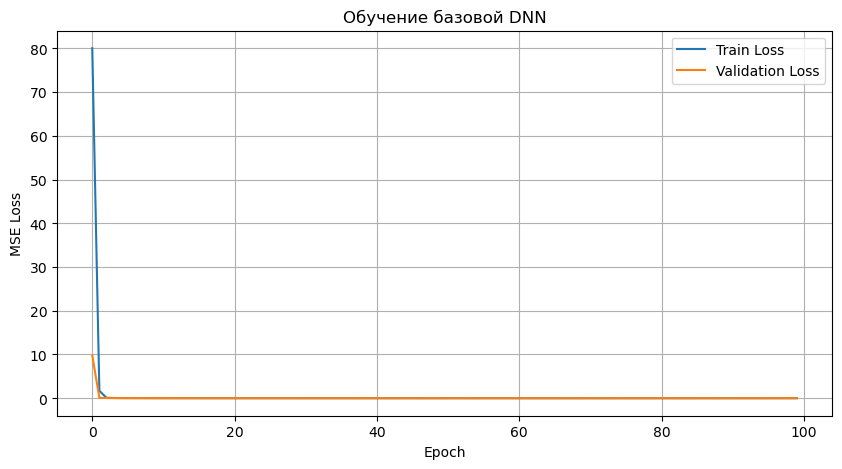

In [150]:
# Построим график изменения ошибки в процессе обучения
plt.figure(figsize=(10, 5))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Обучение базовой DNN")
plt.legend()
plt.grid()

plt.show()

In [151]:
# Переведём модель в режим оценки
model.eval()

# Получим предсказания на валидационной выборке
with torch.no_grad():
    y_pred = model(X_valid_tensor)


# Преобразуем тензоры PyTorch в NumPy
y_pred = y_pred.numpy().flatten()
y_true = y_valid_tensor.numpy().flatten()


# Посчитаем метрики
dnn_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
dnn_r2 = r2_score(y_true, y_pred)

print(f"RMSE: {dnn_rmse:.4f}")
print(f"R²:   {dnn_r2:.4f}")

RMSE: 0.1504
R²:   0.8788


**Вывод:** базовая DNN с одним скрытым слоем показала RMSE = 0.1504 и R² = 0.8788 на валидационной выборке.

В процессе обучения Train Loss продолжал снижаться, тогда как Validation Loss после первоначального улучшения перестал устойчиво уменьшаться. Это указывает на постепенное переобучение модели.

Далее исследуем более сложные архитектуры и методы регуляризации, чтобы проверить, можно ли улучшить качество нейронной сети.

### 7.6 Эксперименты с архитектурой и параметрами DNN

#### 7.6.1 Увеличение количества слоёв

Проверим, как увеличение глубины нейронной сети влияет на качество модели.

Для корректного сравнения с базовой DNN сохраним прежние параметры обучения и функцию активации, изменив только количество линейных слоёв.

In [152]:
# Зафиксируем инициализацию весов
set_seed()

# Создадим более глубокую нейронную сеть
deep_model = nn.Sequential(

    # Входной слой
    nn.Linear(input_size, 256),
    nn.ReLU(),

    # Скрытые слои
    nn.Linear(256, 128),
    nn.ReLU(),

    nn.Linear(128, 64),
    nn.ReLU(),

    # Выходной слой
    nn.Linear(64, 1)
)

print(deep_model)

Sequential(
  (0): Linear(in_features=305, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=1, bias=True)
)


#### Функция обучения DNN

Поскольку далее будет проведено несколько экспериментов с архитектурой и параметрами нейронной сети, вынесем цикл обучения и валидации в отдельную функцию.

Это позволит использовать одинаковый процесс обучения для разных моделей и избежать дублирования кода.

In [153]:
def train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs
):
    """
    Обучает нейронную сеть и сохраняет историю Train Loss и Validation Loss.
    """

    # Возвращаем DataLoader к исходному состоянию generator
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(
            train_loader.generator.initial_seed()
        )

    # Списки для сохранения истории обучения
    train_loss = []
    val_loss = []


    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            # Обнуляем градиенты от предыдущего шага
            optimizer.zero_grad()

            # Forward pass
            predictions = model(X_batch)

            # Считаем ошибку
            loss = loss_fn(predictions, y_batch)

            # Backpropagation
            loss.backward()

            # Обновляем веса модели
            optimizer.step()

            # Накапливаем loss с учётом размера batch
            running_train_loss += loss.item() * X_batch.size(0)


        # Средний Train Loss за эпоху
        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )

        train_loss.append(epoch_train_loss)


        # --------------------
        # Валидация
        # --------------------

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                # Получаем предсказания
                predictions = model(X_batch)

                # Считаем ошибку
                loss = loss_fn(predictions, y_batch)

                # Накапливаем loss с учётом размера batch
                running_val_loss += loss.item() * X_batch.size(0)


        # Средний Validation Loss за эпоху
        epoch_val_loss = (
            running_val_loss / len(valid_loader.dataset)
        )

        val_loss.append(epoch_val_loss)


        # Выводим результаты каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}"
            )


    return train_loss, val_loss

In [154]:
# Создадим оптимизатор для глубокой модели
deep_optimizer = torch.optim.Adam(
    deep_model.parameters(),
    lr=0.001
)

In [155]:
# Обучим глубокую нейронную сеть
deep_train_loss, deep_val_loss = train_model(
    model=deep_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=deep_optimizer,
    epochs=EPOCHS
)

Epoch  10/100 | Train Loss: 0.0147 | Val Loss: 0.0247
Epoch  20/100 | Train Loss: 0.0088 | Val Loss: 0.0204
Epoch  30/100 | Train Loss: 0.0093 | Val Loss: 0.0209
Epoch  40/100 | Train Loss: 0.0213 | Val Loss: 0.0249
Epoch  50/100 | Train Loss: 0.0086 | Val Loss: 0.0204
Epoch  60/100 | Train Loss: 0.0122 | Val Loss: 0.0254
Epoch  70/100 | Train Loss: 0.0098 | Val Loss: 0.0387
Epoch  80/100 | Train Loss: 0.0070 | Val Loss: 0.0239
Epoch  90/100 | Train Loss: 0.0138 | Val Loss: 0.0300
Epoch 100/100 | Train Loss: 0.0312 | Val Loss: 0.0518


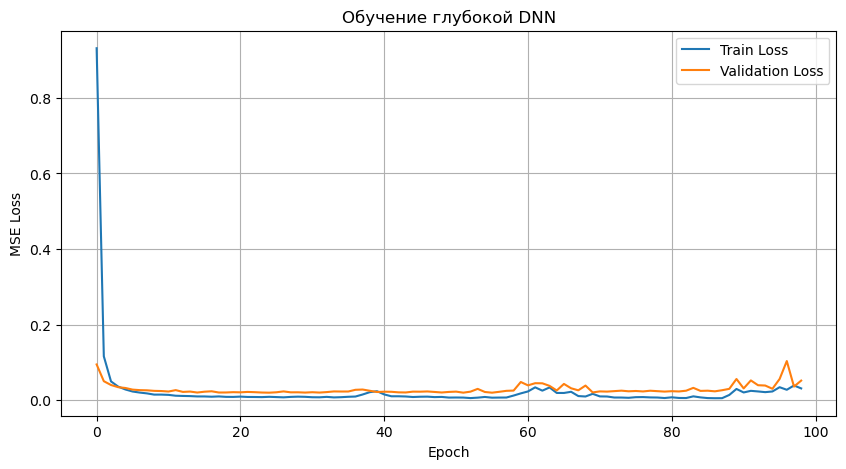

In [156]:
# Построим график изменения ошибки в процессе обучения
plt.figure(figsize=(10, 5))

plt.plot(deep_train_loss[1:], label="Train Loss")
plt.plot(deep_val_loss[1:], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Обучение глубокой DNN")
plt.legend()
plt.grid()

plt.show()

In [157]:
# Переведём модель в режим оценки
deep_model.eval()

# Получим предсказания на валидационной выборке
with torch.no_grad():
    y_pred = deep_model(X_valid_tensor)


# Преобразуем тензоры PyTorch в NumPy
y_pred = y_pred.numpy().flatten()
y_true = y_valid_tensor.numpy().flatten()


# Посчитаем метрики
deep_dnn_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
deep_dnn_r2 = r2_score(y_true, y_pred)

print(f"RMSE: {deep_dnn_rmse:.4f}")
print(f"R²:   {deep_dnn_r2:.4f}")

RMSE: 0.2277
R²:   0.7222


**Вывод:** увеличение глубины нейронной сети не привело к улучшению качества модели.

Базовая DNN показала RMSE = 0.1504 и R² = 0.8788, тогда как глубокая DNN получила RMSE = 0.2277 и R² = 0.7222.

По графику обучения видно, что глубокая сеть обучается менее стабильно: после первоначального снижения ошибки Validation Loss начинает колебаться и периодически увеличиваться.

Таким образом, простое увеличение количества слоёв ухудшило качество модели. Далее проверим методы, которые могут сделать обучение глубокой сети более стабильным и улучшить её обобщающую способность.

#### 7.6.2 Batch Normalization

Добавим Batch Normalization после линейных слоёв глубокой DNN.

Batch Normalization нормализует значения внутри скрытых слоёв по данным текущего batch и может сделать процесс обучения глубокой нейронной сети более стабильным.

Для сравнения с предыдущей моделью сохраним ту же архитектуру и параметры обучения, добавив только Batch Normalization.

In [158]:
# Зафиксируем инициализацию весов
set_seed()

# Создадим глубокую нейронную сеть с Batch Normalization
batchnorm_model = nn.Sequential(

    # Первый скрытый слой
    nn.Linear(input_size, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    # Второй скрытый слой
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    # Третий скрытый слой
    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    # Выходной слой
    nn.Linear(64, 1)
)

print(batchnorm_model)

Sequential(
  (0): Linear(in_features=305, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=1, bias=True)
)


In [159]:
# Создадим оптимизатор
batchnorm_optimizer = torch.optim.Adam(
    batchnorm_model.parameters(),
    lr=0.001
)


# Обучим модель
batchnorm_train_loss, batchnorm_val_loss = train_model(
    model=batchnorm_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=batchnorm_optimizer,
    epochs=EPOCHS
)

Epoch  10/100 | Train Loss: 1.1495 | Val Loss: 0.4261
Epoch  20/100 | Train Loss: 0.1033 | Val Loss: 0.2558
Epoch  30/100 | Train Loss: 0.0975 | Val Loss: 0.0787
Epoch  40/100 | Train Loss: 0.0498 | Val Loss: 0.1234
Epoch  50/100 | Train Loss: 0.0422 | Val Loss: 0.0665
Epoch  60/100 | Train Loss: 0.0498 | Val Loss: 0.1114
Epoch  70/100 | Train Loss: 0.0279 | Val Loss: 0.0938
Epoch  80/100 | Train Loss: 0.0271 | Val Loss: 0.0874
Epoch  90/100 | Train Loss: 0.0286 | Val Loss: 0.1064
Epoch 100/100 | Train Loss: 0.0308 | Val Loss: 0.0439


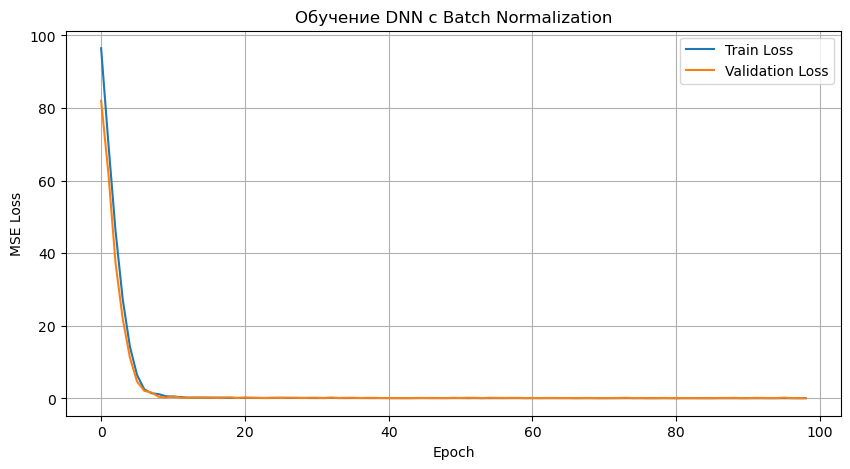

In [160]:
# Построим график изменения ошибки в процессе обучения
plt.figure(figsize=(10, 5))

plt.plot(batchnorm_train_loss[1:], label="Train Loss")
plt.plot(batchnorm_val_loss[1:], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Обучение DNN с Batch Normalization")
plt.legend()
plt.grid()

plt.show()

In [161]:
# Переведём модель в режим оценки
batchnorm_model.eval()

# Получим предсказания на валидационной выборке
with torch.no_grad():
    y_pred = batchnorm_model(X_valid_tensor)


# Преобразуем тензоры PyTorch в NumPy
y_pred = y_pred.numpy().flatten()
y_true = y_valid_tensor.numpy().flatten()


# Посчитаем метрики
batchnorm_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
batchnorm_r2 = r2_score(y_true, y_pred)

print(f"RMSE: {batchnorm_rmse:.4f}")
print(f"R²:   {batchnorm_r2:.4f}")

RMSE: 0.2095
R²:   0.7649


**Вывод:** добавление Batch Normalization улучшило качество глубокой DNN по сравнению с той же архитектурой без нормализации.

Модель с Batch Normalization показала RMSE = 0.2095 и R² = 0.7649, тогда как глубокая DNN без нормализации получила RMSE = 0.2277 и R² = 0.7222.

Однако результат всё ещё хуже базовой DNN с одним скрытым слоем, которая показала RMSE = 0.1504 и R² = 0.8788.

Таким образом, Batch Normalization частично улучшила обучение глубокой архитектуры, но не позволила ей превзойти более простую базовую модель. Далее проверим другой способ регуляризации — Dropout.

#### 7.6.3 Dropout

Проверим влияние Dropout на качество базовой DNN.

Dropout является методом регуляризации: во время обучения он случайным образом отключает часть нейронов, что может уменьшить переобучение модели.

Проверим несколько значений вероятности отключения нейронов: 0.1, 0.2 и 0.3. Остальные параметры модели и обучения оставим без изменений.

In [162]:
# Функция для создания DNN с заданным значением Dropout
def create_dropout_model(dropout_rate):

    # Зафиксируем инициализацию весов
    set_seed()

    model = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(128, 1)
    )

    return model

In [163]:
# Значения Dropout для эксперимента
dropout_rates = [0.1, 0.2, 0.3]

# Список для сохранения результатов
dropout_results = []

In [164]:
for dropout_rate in dropout_rates:

    print(f"\nDropout = {dropout_rate}")

    # Создаём новую модель
    dropout_model = create_dropout_model(dropout_rate)

    # Для каждой новой модели создаём свой optimizer
    dropout_optimizer = torch.optim.Adam(
        dropout_model.parameters(),
        lr=0.001
    )

    # Обучаем модель
    dropout_train_loss, dropout_val_loss = train_model(
        model=dropout_model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=dropout_optimizer,
        epochs=EPOCHS
    )

    # Переводим модель в режим оценки
    dropout_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = dropout_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    dropout_results.append({
        "Dropout": dropout_rate,
        "RMSE": rmse,
        "R2": r2
    })


Dropout = 0.1
Epoch  10/100 | Train Loss: 0.2792 | Val Loss: 0.0255
Epoch  20/100 | Train Loss: 0.2630 | Val Loss: 0.0273
Epoch  30/100 | Train Loss: 0.2520 | Val Loss: 0.0267
Epoch  40/100 | Train Loss: 0.2686 | Val Loss: 0.0367
Epoch  50/100 | Train Loss: 0.2313 | Val Loss: 0.0319
Epoch  60/100 | Train Loss: 0.2269 | Val Loss: 0.0304
Epoch  70/100 | Train Loss: 0.2435 | Val Loss: 0.0382
Epoch  80/100 | Train Loss: 0.2374 | Val Loss: 0.0390
Epoch  90/100 | Train Loss: 0.2457 | Val Loss: 0.0314
Epoch 100/100 | Train Loss: 0.2609 | Val Loss: 0.0265

Dropout = 0.2
Epoch  10/100 | Train Loss: 0.5346 | Val Loss: 0.0280
Epoch  20/100 | Train Loss: 0.5534 | Val Loss: 0.0406
Epoch  30/100 | Train Loss: 0.5467 | Val Loss: 0.0309
Epoch  40/100 | Train Loss: 0.5462 | Val Loss: 0.0548
Epoch  50/100 | Train Loss: 0.5519 | Val Loss: 0.0467
Epoch  60/100 | Train Loss: 0.5056 | Val Loss: 0.0385
Epoch  70/100 | Train Loss: 0.5069 | Val Loss: 0.0432
Epoch  80/100 | Train Loss: 0.4863 | Val Loss: 0.080

In [165]:
# Выведем результаты эксперимента
dropout_results_df = pd.DataFrame(dropout_results)

dropout_results_df

,Dropout,RMSE,R2
0,0.1,0.162741,0.858076
1,0.2,0.193311,0.799748
2,0.3,0.229511,0.717727


**Вывод:** среди протестированных значений Dropout лучший результат показала модель с `Dropout = 0.1` (RMSE = 0.1627, R² = 0.8581).

Однако даже этот результат оказался хуже базовой DNN без регуляризации, которая показала RMSE = 0.1504 и R² = 0.8788.

При увеличении значения Dropout качество последовательно ухудшалось: более сильное отключение нейронов оказалось избыточным для данной архитектуры.

Таким образом, добавление Dropout в текущую базовую архитектуру не улучшило качество модели.

#### Сохранение лучших весов модели

В предыдущих экспериментах было замечено, что минимальный Validation Loss часто достигается до последней эпохи обучения. Поэтому оценка модели только после последней эпохи может не отражать её лучший результат.

Для дальнейших экспериментов изменим функцию обучения так, чтобы сохранять веса модели с минимальным Validation Loss и восстанавливать их после завершения обучения.

In [166]:
def train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs
):
    """
    Обучает нейронную сеть, сохраняет историю обучения
    и восстанавливает лучшие веса по Validation Loss.
    """

    # Возвращаем DataLoader к исходному состоянию generator
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(
            train_loader.generator.initial_seed()
        )

    # Списки для сохранения истории обучения
    train_loss = []
    val_loss = []

    # Лучшее значение Validation Loss
    best_val_loss = float("inf")

    # Здесь будем хранить лучшие веса модели
    best_model_state = None


    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = loss_fn(predictions, y_batch)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)


        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )

        train_loss.append(epoch_train_loss)


        # --------------------
        # Валидация
        # --------------------

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                predictions = model(X_batch)

                loss = loss_fn(predictions, y_batch)

                running_val_loss += loss.item() * X_batch.size(0)


        epoch_val_loss = (
            running_val_loss / len(valid_loader.dataset)
        )

        val_loss.append(epoch_val_loss)


        # Сохраняем веса модели,
        # если получили лучший Validation Loss
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )


        # Выводим результаты каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}"
            )


    # Восстанавливаем лучшие найденные веса
    model.load_state_dict(best_model_state)

    return train_loss, val_loss

#### 7.6.4 Размеры линейных слоёв и функции активации

Проверим влияние размера скрытого слоя и функции активации на качество нейронной сети.

Сначала сравним несколько размеров скрытого слоя, сохранив функцию активации ReLU и остальные параметры обучения без изменений. Затем для лучшего размера скрытого слоя сравним несколько функций активации.

In [167]:
# Функция для создания DNN с заданным размером скрытого слоя
def create_model(hidden_size):

    # Зафиксируем инициализацию весов
    set_seed()
    
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, 1)
    )

    return model

In [168]:
# Размеры скрытого слоя для эксперимента
hidden_sizes = [64, 128, 256]

# Список для сохранения результатов
hidden_size_results = []


for hidden_size in hidden_sizes:

    print(f"\nHidden size = {hidden_size}")

    # Создаём новую модель
    current_model = create_model(hidden_size)

    # Для каждой модели создаём новый optimizer
    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=0.001
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=EPOCHS
    )

    # После train_model() модель уже содержит
    # лучшие веса по Validation Loss
    current_model.eval()

    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    hidden_size_results.append({
        "Hidden Size": hidden_size,
        "RMSE": rmse,
        "R2": r2
    })


Hidden size = 64
Epoch  10/100 | Train Loss: 0.0293 | Val Loss: 0.0267
Epoch  20/100 | Train Loss: 0.0152 | Val Loss: 0.0200
Epoch  30/100 | Train Loss: 0.0104 | Val Loss: 0.0188
Epoch  40/100 | Train Loss: 0.0083 | Val Loss: 0.0187
Epoch  50/100 | Train Loss: 0.0075 | Val Loss: 0.0194
Epoch  60/100 | Train Loss: 0.0069 | Val Loss: 0.0192
Epoch  70/100 | Train Loss: 0.0061 | Val Loss: 0.0200
Epoch  80/100 | Train Loss: 0.0059 | Val Loss: 0.0209
Epoch  90/100 | Train Loss: 0.0054 | Val Loss: 0.0206
Epoch 100/100 | Train Loss: 0.0060 | Val Loss: 0.0205

Hidden size = 128
Epoch  10/100 | Train Loss: 0.0207 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0111 | Val Loss: 0.0174
Epoch  30/100 | Train Loss: 0.0083 | Val Loss: 0.0165
Epoch  40/100 | Train Loss: 0.0072 | Val Loss: 0.0168
Epoch  50/100 | Train Loss: 0.0066 | Val Loss: 0.0176
Epoch  60/100 | Train Loss: 0.0056 | Val Loss: 0.0177
Epoch  70/100 | Train Loss: 0.0047 | Val Loss: 0.0185
Epoch  80/100 | Train Loss: 0.0045 | Val Loss

In [169]:
# Выведем результаты эксперимента
hidden_size_results_df = pd.DataFrame(hidden_size_results)

hidden_size_results_df

,Hidden Size,RMSE,R2
0,64,0.136150,0.900667
1,128,0.128339,0.911737
2,256,0.128350,0.911722


**Вывод:** лучший результат среди протестированных размеров скрытого слоя показала модель со 128 нейронами: RMSE = 0.1283 и R² = 0.9117.

Уменьшение скрытого слоя до 64 нейронов ухудшило качество модели.

Увеличение скрытого слоя до 256 нейронов практически не изменило результат: значения RMSE и R² оказались почти идентичными варианту со 128 нейронами.

Поэтому для следующих экспериментов будем использовать скрытый слой из 128 нейронов как более компактный вариант при сопоставимом качестве.

##### Сравнение функций активации

Зафиксируем лучший размер скрытого слоя (128 нейронов) и проверим несколько функций активации: ReLU, LeakyReLU и ELU.

Остальные параметры архитектуры и обучения оставим без изменений, чтобы оценить влияние только функции активации.

In [170]:
# Функция для создания DNN с заданной функцией активации
def create_activation_model(activation):

    # Зафиксируем инициализацию весов
    set_seed()

    model = nn.Sequential(
        nn.Linear(input_size, 128),
        activation,
        nn.Linear(128, 1)
    )

    return model

In [171]:
# Функции активации для эксперимента
activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(),
    "ELU": nn.ELU()
}

# Список для сохранения результатов
activation_results = []

In [172]:
for activation_name, activation in activations.items():

    print(f"\nActivation = {activation_name}")

    # Создаём новую модель
    current_model = create_activation_model(activation)

    # Для каждой модели создаём новый optimizer
    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=0.001
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=EPOCHS
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    activation_results.append({
        "Activation": activation_name,
        "RMSE": rmse,
        "R2": r2
    })


Activation = ReLU
Epoch  10/100 | Train Loss: 0.0207 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0111 | Val Loss: 0.0174
Epoch  30/100 | Train Loss: 0.0083 | Val Loss: 0.0165
Epoch  40/100 | Train Loss: 0.0072 | Val Loss: 0.0168
Epoch  50/100 | Train Loss: 0.0066 | Val Loss: 0.0176
Epoch  60/100 | Train Loss: 0.0056 | Val Loss: 0.0177
Epoch  70/100 | Train Loss: 0.0047 | Val Loss: 0.0185
Epoch  80/100 | Train Loss: 0.0045 | Val Loss: 0.0198
Epoch  90/100 | Train Loss: 0.0041 | Val Loss: 0.0201
Epoch 100/100 | Train Loss: 0.0114 | Val Loss: 0.0226

Activation = LeakyReLU
Epoch  10/100 | Train Loss: 0.0211 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0125 | Val Loss: 0.0177
Epoch  30/100 | Train Loss: 0.0098 | Val Loss: 0.0170
Epoch  40/100 | Train Loss: 0.0082 | Val Loss: 0.0171
Epoch  50/100 | Train Loss: 0.0074 | Val Loss: 0.0174
Epoch  60/100 | Train Loss: 0.0070 | Val Loss: 0.0180
Epoch  70/100 | Train Loss: 0.0061 | Val Loss: 0.0189
Epoch  80/100 | Train Loss: 0.0058 | Va

In [173]:
# Выведем результаты эксперимента
activation_results_df = pd.DataFrame(activation_results)

activation_results_df

,Activation,RMSE,R2
0,ReLU,0.128339,0.911737
1,LeakyReLU,0.129479,0.910162
2,ELU,0.125934,0.915013


**Вывод:** среди протестированных функций активации лучший результат показала ELU: RMSE = 0.1259 и R² = 0.9150.

ReLU показала немного худший результат, а LeakyReLU в данном эксперименте не дала улучшения относительно ReLU.

Для дальнейших экспериментов будем использовать один скрытый слой из 128 нейронов и функцию активации ELU.

#### 7.6.5 Оптимизаторы

Проверим влияние различных алгоритмов оптимизации на качество DNN.

Зафиксируем выбранную архитектуру из предыдущих экспериментов: один скрытый слой из 128 нейронов и функцию активации ELU. Сравним оптимизаторы SGD, Adam и AdamW, сохранив остальные параметры обучения без изменений.

In [174]:
# Функция для создания DNN с выбранной архитектурой
def create_best_model():

    # Зафиксируем инициализацию весов
    set_seed()

    model = nn.Sequential(
        nn.Linear(input_size, 128),
        nn.ELU(),
        nn.Linear(128, 1)
    )

    return model

In [175]:
# Оптимизаторы для эксперимента
optimizers = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "AdamW": torch.optim.AdamW
}

# Список для сохранения результатов
optimizer_results = []

In [176]:
for optimizer_name, optimizer_class in optimizers.items():

    print(f"\nOptimizer = {optimizer_name}")

    # Для каждого эксперимента создаём новую модель
    current_model = create_best_model()

    # Создаём выбранный оптимизатор
    current_optimizer = optimizer_class(
        current_model.parameters(),
        lr=0.001
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=EPOCHS
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    optimizer_results.append({
        "Optimizer": optimizer_name,
        "RMSE": rmse,
        "R2": r2
    })


Optimizer = SGD
Epoch  10/100 | Train Loss: 0.2452 | Val Loss: 0.2186
Epoch  20/100 | Train Loss: 0.1585 | Val Loss: 0.1461
Epoch  30/100 | Train Loss: 0.1192 | Val Loss: 0.1130
Epoch  40/100 | Train Loss: 0.0961 | Val Loss: 0.0948
Epoch  50/100 | Train Loss: 0.0807 | Val Loss: 0.0845
Epoch  60/100 | Train Loss: 0.0696 | Val Loss: 0.0728
Epoch  70/100 | Train Loss: 0.0613 | Val Loss: 0.0651
Epoch  80/100 | Train Loss: 0.0546 | Val Loss: 0.0604
Epoch  90/100 | Train Loss: 0.0494 | Val Loss: 0.0550
Epoch 100/100 | Train Loss: 0.0451 | Val Loss: 0.0514

Optimizer = Adam
Epoch  10/100 | Train Loss: 0.0186 | Val Loss: 0.0192
Epoch  20/100 | Train Loss: 0.0115 | Val Loss: 0.0168
Epoch  30/100 | Train Loss: 0.0095 | Val Loss: 0.0160
Epoch  40/100 | Train Loss: 0.0088 | Val Loss: 0.0162
Epoch  50/100 | Train Loss: 0.0084 | Val Loss: 0.0162
Epoch  60/100 | Train Loss: 0.0083 | Val Loss: 0.0165
Epoch  70/100 | Train Loss: 0.0081 | Val Loss: 0.0167
Epoch  80/100 | Train Loss: 0.0078 | Val Loss: 

In [177]:
# Выведем результаты эксперимента
optimizer_results_df = pd.DataFrame(optimizer_results)

optimizer_results_df

,Optimizer,RMSE,R2
0,SGD,0.226728,0.724530
1,Adam,0.125934,0.915013
2,AdamW,0.125907,0.915050


**Вывод:** при одинаковом learning rate = 0.001 оптимизаторы Adam и AdamW показали значительно лучшие результаты, чем SGD.

AdamW получил немного лучший результат: RMSE = 0.1259 и R² = 0.9151. Результат Adam оказался практически идентичным: RMSE = 0.1259 и R² = 0.9150.

SGD при learning rate = 0.001 обучался значительно медленнее и за 100 эпох не достиг качества адаптивных оптимизаторов. При этом его ошибка продолжала снижаться к концу обучения, поэтому результат SGD нельзя считать оценкой его максимально возможного качества без дополнительной настройки learning rate и количества эпох.

Для дальнейших экспериментов будем использовать AdamW.

#### 7.6.6 Scheduler

Проверим использование scheduler для изменения learning rate в процессе обучения.

Используем `CosineAnnealingLR`, который постепенно изменяет learning rate по косинусному закону от начального значения к минимальному.

В качестве основы используем выбранную ранее архитектуру с 128 нейронами, функцией активации ELU и оптимизатором AdamW.

In [178]:
def train_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs,
    scheduler=None
):
    """
    Обучает нейронную сеть, сохраняет историю обучения
    и восстанавливает лучшие веса по Validation Loss.
    """

    # Возвращаем DataLoader к исходному состоянию generator
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(
            train_loader.generator.initial_seed()
        )

    # Списки для сохранения истории обучения
    train_loss = []
    val_loss = []

    # Лучшее значение Validation Loss
    best_val_loss = float("inf")

    # Здесь будем хранить лучшие веса модели
    best_model_state = None


    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            predictions = model(X_batch)

            loss = loss_fn(predictions, y_batch)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)


        # Средний Train Loss за эпоху
        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )

        train_loss.append(epoch_train_loss)


        # --------------------
        # Валидация
        # --------------------

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                predictions = model(X_batch)

                loss = loss_fn(predictions, y_batch)

                running_val_loss += loss.item() * X_batch.size(0)


        # Средний Validation Loss за эпоху
        epoch_val_loss = (
            running_val_loss / len(valid_loader.dataset)
        )

        val_loss.append(epoch_val_loss)


        # Сохраняем лучшие веса модели
        if epoch_val_loss < best_val_loss:

            best_val_loss = epoch_val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )


        # Изменяем learning rate после завершения эпохи
        if scheduler is not None:
            scheduler.step()


        # Выводим результаты каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}"
            )


    # Восстанавливаем лучшие найденные веса
    model.load_state_dict(best_model_state)

    return train_loss, val_loss

In [179]:
# Создадим модель
scheduler_model = create_best_model()

# Создадим оптимизатор
scheduler_optimizer = torch.optim.AdamW(
    scheduler_model.parameters(),
    lr=0.001
)

In [180]:
# Создадим косинусовый scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    scheduler_optimizer,
    T_max=EPOCHS,
    eta_min=1e-5
)

In [181]:
# Обучим модель с scheduler
scheduler_train_loss, scheduler_val_loss = train_model(
    model=scheduler_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    loss_fn=loss_fn,
    optimizer=scheduler_optimizer,
    epochs=EPOCHS,
    scheduler=scheduler
)

Epoch  10/100 | Train Loss: 0.0187 | Val Loss: 0.0192
Epoch  20/100 | Train Loss: 0.0116 | Val Loss: 0.0169
Epoch  30/100 | Train Loss: 0.0095 | Val Loss: 0.0161
Epoch  40/100 | Train Loss: 0.0087 | Val Loss: 0.0162
Epoch  50/100 | Train Loss: 0.0083 | Val Loss: 0.0159
Epoch  60/100 | Train Loss: 0.0080 | Val Loss: 0.0160
Epoch  70/100 | Train Loss: 0.0078 | Val Loss: 0.0161
Epoch  80/100 | Train Loss: 0.0075 | Val Loss: 0.0162
Epoch  90/100 | Train Loss: 0.0074 | Val Loss: 0.0160
Epoch 100/100 | Train Loss: 0.0073 | Val Loss: 0.0160


In [182]:
# Переведём модель в режим оценки
scheduler_model.eval()

# Получим предсказания
with torch.no_grad():
    y_pred = scheduler_model(X_valid_tensor)

# Преобразуем предсказания в NumPy
y_pred = y_pred.numpy().flatten()

# Посчитаем метрики
scheduler_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
scheduler_r2 = r2_score(y_true, y_pred)

print(f"RMSE: {scheduler_rmse:.4f}")
print(f"R²:   {scheduler_r2:.4f}")

RMSE: 0.1260
R²:   0.9150


**Вывод:** использование `CosineAnnealingLR` не привело к заметному улучшению качества модели.

Модель с scheduler показала RMSE = 0.1260 и R² = 0.9150, тогда как AdamW без scheduler получил практически идентичный результат: RMSE = 0.1259 и R² = 0.9151.

Таким образом, в данном эксперименте изменение learning rate по косинусному закону не дало явного преимущества по итоговым метрикам.

Тем не менее для следующих экспериментов сохраним scheduler в схеме обучения и будем изменять остальные параметры по одному.

#### 7.6.7 Параметры обучения

Проверим влияние основных параметров обучения нейронной сети: learning rate, batch size, количества эпох и функции потерь.

Чтобы оценивать влияние каждого параметра отдельно, будем изменять по одному параметру, сохраняя остальные настройки модели неизменными.

##### Выбор Learning Rate

Проверим влияние скорости обучения на качество DNN.

Сравним несколько значений learning rate, сохранив остальные выбранные параметры модели без изменений.

In [183]:
# Значения Learning Rate для эксперимента
learning_rates = [0.0001, 0.001, 0.01]

# Список для сохранения результатов
lr_results = []


for lr in learning_rates:

    print(f"\nLearning Rate = {lr}")

    # Создаём новую модель
    current_model = create_best_model()

    # Создаём оптимизатор с текущим Learning Rate
    current_optimizer = torch.optim.AdamW(
        current_model.parameters(),
        lr=lr
    )

    # Создаём scheduler
    current_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        current_optimizer,
        T_max=EPOCHS,
        eta_min=1e-5
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=EPOCHS,
        scheduler=current_scheduler
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    lr_results.append({
        "Learning Rate": lr,
        "RMSE": rmse,
        "R2": r2
    })


Learning Rate = 0.0001
Epoch  10/100 | Train Loss: 4.4040 | Val Loss: 2.8667
Epoch  20/100 | Train Loss: 0.0579 | Val Loss: 0.0470
Epoch  30/100 | Train Loss: 0.0407 | Val Loss: 0.0335
Epoch  40/100 | Train Loss: 0.0322 | Val Loss: 0.0273
Epoch  50/100 | Train Loss: 0.0273 | Val Loss: 0.0241
Epoch  60/100 | Train Loss: 0.0242 | Val Loss: 0.0224
Epoch  70/100 | Train Loss: 0.0222 | Val Loss: 0.0212
Epoch  80/100 | Train Loss: 0.0209 | Val Loss: 0.0206
Epoch  90/100 | Train Loss: 0.0200 | Val Loss: 0.0201
Epoch 100/100 | Train Loss: 0.0194 | Val Loss: 0.0198

Learning Rate = 0.001
Epoch  10/100 | Train Loss: 0.0187 | Val Loss: 0.0192
Epoch  20/100 | Train Loss: 0.0116 | Val Loss: 0.0169
Epoch  30/100 | Train Loss: 0.0095 | Val Loss: 0.0161
Epoch  40/100 | Train Loss: 0.0087 | Val Loss: 0.0162
Epoch  50/100 | Train Loss: 0.0083 | Val Loss: 0.0159
Epoch  60/100 | Train Loss: 0.0080 | Val Loss: 0.0160
Epoch  70/100 | Train Loss: 0.0078 | Val Loss: 0.0161
Epoch  80/100 | Train Loss: 0.0075 

In [184]:
# Выведем результаты эксперимента
lr_results_df = pd.DataFrame(lr_results)

lr_results_df

,Learning Rate,RMSE,R2
0,0.0001,0.140868,0.893662
1,0.0010,0.125951,0.914991
2,0.0100,0.129731,0.909812


**Вывод:** лучший результат среди протестированных значений learning rate показал `lr = 0.001`: RMSE = 0.1260 и R² = 0.9150.

При `lr = 0.0001` обучение происходило заметно медленнее, и модель показала более низкое качество.

Увеличение learning rate до `0.01` также не улучшило результат и привело к немного более высокому RMSE.

Для дальнейших экспериментов будем использовать `learning_rate = 0.001`.

##### Выбор Batch Size

Проверим влияние размера batch на качество обучения DNN.

Зафиксируем выбранные ранее архитектуру и параметры модели и сравним несколько значений batch size: 16, 32 и 64.

In [185]:
# Значения Batch Size для эксперимента
batch_sizes = [16, 32, 64]

# Список для сохранения результатов
batch_size_results = []


for batch_size in batch_sizes:

    print(f"\nBatch Size = {batch_size}")

    # Создаём DataLoader с текущим Batch Size
    current_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=make_generator()
    )

    # Создаём новую модель
    current_model = create_best_model()

    # Создаём оптимизатор
    current_optimizer = torch.optim.AdamW(
        current_model.parameters(),
        lr=0.001
    )

    # Создаём scheduler
    current_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        current_optimizer,
        T_max=EPOCHS,
        eta_min=1e-5
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=current_train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=EPOCHS,
        scheduler=current_scheduler
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    batch_size_results.append({
        "Batch Size": batch_size,
        "RMSE": rmse,
        "R2": r2
    })


Batch Size = 16
Epoch  10/100 | Train Loss: 0.0142 | Val Loss: 0.0175
Epoch  20/100 | Train Loss: 0.0100 | Val Loss: 0.0167
Epoch  30/100 | Train Loss: 0.0096 | Val Loss: 0.0169
Epoch  40/100 | Train Loss: 0.0087 | Val Loss: 0.0171
Epoch  50/100 | Train Loss: 0.0085 | Val Loss: 0.0173
Epoch  60/100 | Train Loss: 0.0075 | Val Loss: 0.0172
Epoch  70/100 | Train Loss: 0.0068 | Val Loss: 0.0171
Epoch  80/100 | Train Loss: 0.0059 | Val Loss: 0.0167
Epoch  90/100 | Train Loss: 0.0054 | Val Loss: 0.0168
Epoch 100/100 | Train Loss: 0.0053 | Val Loss: 0.0163

Batch Size = 32
Epoch  10/100 | Train Loss: 0.0187 | Val Loss: 0.0192
Epoch  20/100 | Train Loss: 0.0116 | Val Loss: 0.0169
Epoch  30/100 | Train Loss: 0.0095 | Val Loss: 0.0161
Epoch  40/100 | Train Loss: 0.0087 | Val Loss: 0.0162
Epoch  50/100 | Train Loss: 0.0083 | Val Loss: 0.0159
Epoch  60/100 | Train Loss: 0.0080 | Val Loss: 0.0160
Epoch  70/100 | Train Loss: 0.0078 | Val Loss: 0.0161
Epoch  80/100 | Train Loss: 0.0075 | Val Loss: 0

In [186]:
# Выведем результаты эксперимента
batch_size_results_df = pd.DataFrame(batch_size_results)

batch_size_results_df

,Batch Size,RMSE,R2
0,16,0.126350,0.914452
1,32,0.125951,0.914991
2,64,0.125142,0.916080


**Вывод:** все протестированные значения batch size показали близкие результаты.

Лучший результат в данном эксперименте получил `batch_size = 64`: RMSE = 0.1251 и R² = 0.9161.

Различия между batch size 16, 32 и 64 невелики, однако увеличение batch size до 64 дало небольшое улучшение обеих метрик.

Для дальнейших экспериментов будем использовать `batch_size = 64`.

##### Выбор количества эпох

Проверим влияние продолжительности обучения на качество DNN.

Сравним 50, 100 и 200 эпох. Поскольку функция обучения сохраняет веса с минимальным Validation Loss, итоговая модель будет соответствовать лучшему состоянию, найденному за указанное количество эпох.

In [187]:
# Создадим DataLoader с выбранным Batch Size
best_train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=make_generator()
)

In [188]:
# Количество эпох для эксперимента
epochs_values = [50, 100, 200]

# Список для сохранения результатов
epochs_results = []


for epochs in epochs_values:

    print(f"\nEpochs = {epochs}")

    # Создаём новую модель
    current_model = create_best_model()

    # Создаём оптимизатор
    current_optimizer = torch.optim.AdamW(
        current_model.parameters(),
        lr=0.001
    )

    # Создаём scheduler
    current_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        current_optimizer,
        T_max=epochs,
        eta_min=1e-5
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=best_train_loader,
        valid_loader=valid_loader,
        loss_fn=loss_fn,
        optimizer=current_optimizer,
        epochs=epochs,
        scheduler=current_scheduler
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем метрики
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    epochs_results.append({
        "Epochs": epochs,
        "RMSE": rmse,
        "R2": r2
    })


Epochs = 50
Epoch  10/50 | Train Loss: 0.0236 | Val Loss: 0.0213
Epoch  20/50 | Train Loss: 0.0155 | Val Loss: 0.0177
Epoch  30/50 | Train Loss: 0.0128 | Val Loss: 0.0174
Epoch  40/50 | Train Loss: 0.0117 | Val Loss: 0.0170
Epoch  50/50 | Train Loss: 0.0115 | Val Loss: 0.0169

Epochs = 100
Epoch  10/100 | Train Loss: 0.0234 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0148 | Val Loss: 0.0175
Epoch  30/100 | Train Loss: 0.0117 | Val Loss: 0.0175
Epoch  40/100 | Train Loss: 0.0101 | Val Loss: 0.0163
Epoch  50/100 | Train Loss: 0.0093 | Val Loss: 0.0161
Epoch  60/100 | Train Loss: 0.0089 | Val Loss: 0.0158
Epoch  70/100 | Train Loss: 0.0086 | Val Loss: 0.0157
Epoch  80/100 | Train Loss: 0.0084 | Val Loss: 0.0157
Epoch  90/100 | Train Loss: 0.0084 | Val Loss: 0.0157
Epoch 100/100 | Train Loss: 0.0083 | Val Loss: 0.0157

Epochs = 200
Epoch  10/200 | Train Loss: 0.0234 | Val Loss: 0.0211
Epoch  20/200 | Train Loss: 0.0147 | Val Loss: 0.0175
Epoch  30/200 | Train Loss: 0.0115 | Val Loss:

In [189]:
# Выведем результаты эксперимента
epochs_results_df = pd.DataFrame(epochs_results)

epochs_results_df

,Epochs,RMSE,R2
0,50,0.130117,0.909274
1,100,0.125142,0.916080
2,200,0.125199,0.916003


**Вывод:** увеличение количества эпох с 50 до 100 заметно улучшило качество модели.

Лучший результат был получен при 100 эпохах: RMSE = 0.1251 и R² = 0.9161.

Увеличение максимального количества эпох до 200 практически не изменило результат: RMSE составил 0.1252, а R² — 0.9160.

Поскольку функция обучения сохраняет лучшие веса по Validation Loss, итоговая модель использует состояние с минимальной ошибкой на валидационной выборке, а не обязательно веса последней эпохи.

Для дальнейших экспериментов будем использовать 100 эпох, так как увеличение до 200 эпох не дало дополнительного улучшения.

##### Выбор функции потерь

Проверим влияние функции потерь на качество DNN.

До сих пор для обучения использовалась `MSELoss`, которая сильнее штрафует большие ошибки. Сравним её с `L1Loss` и `SmoothL1Loss`.

Остальные выбранные параметры модели оставим без изменений.

In [190]:
# Функции потерь для эксперимента
loss_functions = {
    "MSELoss": nn.MSELoss(),
    "L1Loss": nn.L1Loss(),
    "SmoothL1Loss": nn.SmoothL1Loss()
}

# Список для сохранения результатов
loss_results = []

In [191]:
for loss_name, current_loss_fn in loss_functions.items():

    print(f"\nLoss Function = {loss_name}")

    # Создаём новую модель
    current_model = create_best_model()

    # Создаём оптимизатор
    current_optimizer = torch.optim.AdamW(
        current_model.parameters(),
        lr=0.001
    )

    # Создаём scheduler
    current_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        current_optimizer,
        T_max=100,
        eta_min=1e-5
    )

    # Обучаем модель
    current_train_loss, current_val_loss = train_model(
        model=current_model,
        train_loader=best_train_loader,
        valid_loader=valid_loader,
        loss_fn=current_loss_fn,
        optimizer=current_optimizer,
        epochs=100,
        scheduler=current_scheduler
    )

    # Переводим модель в режим оценки
    current_model.eval()

    # Получаем предсказания
    with torch.no_grad():
        y_pred = current_model(X_valid_tensor)

    # Преобразуем предсказания в NumPy
    y_pred = y_pred.numpy().flatten()

    # Считаем одинаковые метрики для всех моделей
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Сохраняем результаты
    loss_results.append({
        "Loss Function": loss_name,
        "RMSE": rmse,
        "R2": r2
    })


Loss Function = MSELoss
Epoch  10/100 | Train Loss: 0.0234 | Val Loss: 0.0211
Epoch  20/100 | Train Loss: 0.0148 | Val Loss: 0.0175
Epoch  30/100 | Train Loss: 0.0117 | Val Loss: 0.0175
Epoch  40/100 | Train Loss: 0.0101 | Val Loss: 0.0163
Epoch  50/100 | Train Loss: 0.0093 | Val Loss: 0.0161
Epoch  60/100 | Train Loss: 0.0089 | Val Loss: 0.0158
Epoch  70/100 | Train Loss: 0.0086 | Val Loss: 0.0157
Epoch  80/100 | Train Loss: 0.0084 | Val Loss: 0.0157
Epoch  90/100 | Train Loss: 0.0084 | Val Loss: 0.0157
Epoch 100/100 | Train Loss: 0.0083 | Val Loss: 0.0157

Loss Function = L1Loss
Epoch  10/100 | Train Loss: 0.0869 | Val Loss: 0.1075
Epoch  20/100 | Train Loss: 0.0705 | Val Loss: 0.0964
Epoch  30/100 | Train Loss: 0.0798 | Val Loss: 0.0898
Epoch  40/100 | Train Loss: 0.0653 | Val Loss: 0.0870
Epoch  50/100 | Train Loss: 0.0608 | Val Loss: 0.0871
Epoch  60/100 | Train Loss: 0.0534 | Val Loss: 0.0870
Epoch  70/100 | Train Loss: 0.0516 | Val Loss: 0.0830
Epoch  80/100 | Train Loss: 0.046

In [192]:
# Выведем результаты эксперимента
loss_results_df = pd.DataFrame(loss_results)

loss_results_df

,Loss Function,RMSE,R2
0,MSELoss,0.125142,0.916080
1,L1Loss,0.126994,0.913577
2,SmoothL1Loss,0.125583,0.915487


**Вывод:** среди протестированных функций потерь лучший результат показала `MSELoss`: RMSE = 0.1251 и R² = 0.9161.

`SmoothL1Loss` показала очень близкий результат: RMSE = 0.1256 и R² = 0.9155.

`L1Loss` оказалась немного хуже: RMSE = 0.1270 и R² = 0.9136.

Таким образом, для дальнейшего обучения DNN будем использовать `MSELoss`.

### 7.7 Результаты экспериментов с DNN

В ходе экспериментов были исследованы различные архитектуры нейронной сети, методы регуляризации и параметры обучения.

Наиболее удачной оказалась простая архитектура с одним скрытым слоем. Увеличение глубины сети, использование Batch Normalization и Dropout в проведённых экспериментах не привели к улучшению качества.

Далее последовательно были подобраны размер скрытого слоя, функция активации, оптимизатор, scheduler и основные параметры обучения.

In [193]:
# Соберём основные результаты экспериментов с DNN
dnn_results = [
    {
        "Experiment": "Baseline DNN",
        "Configuration": "128, ReLU",
        "RMSE": dnn_rmse,
        "R2": dnn_r2
    },
    {
        "Experiment": "Deep DNN",
        "Configuration": "256 → 128 → 64, ReLU",
        "RMSE": deep_dnn_rmse,
        "R2": deep_dnn_r2
    },
    {
        "Experiment": "BatchNorm",
        "Configuration": "256 → 128 → 64, ReLU + BatchNorm",
        "RMSE": batchnorm_rmse,
        "R2": batchnorm_r2
    },
    {
        "Experiment": "Dropout",
        "Configuration": "128, ReLU, Dropout = 0.1",
        "RMSE": dropout_results[0]["RMSE"],
        "R2": dropout_results[0]["R2"]
    },
    {
        "Experiment": "Hidden Size",
        "Configuration": "128, ReLU",
        "RMSE": hidden_size_results[1]["RMSE"],
        "R2": hidden_size_results[1]["R2"]
    },
    {
        "Experiment": "Activation",
        "Configuration": "128, ELU",
        "RMSE": activation_results[2]["RMSE"],
        "R2": activation_results[2]["R2"]
    },
    {
        "Experiment": "Optimizer",
        "Configuration": "AdamW",
        "RMSE": optimizer_results[2]["RMSE"],
        "R2": optimizer_results[2]["R2"]
    },
    {
        "Experiment": "Scheduler",
        "Configuration": "CosineAnnealingLR",
        "RMSE": scheduler_rmse,
        "R2": scheduler_r2
    },
    {
        "Experiment": "Learning Rate",
        "Configuration": "lr = 0.001",
        "RMSE": lr_results[1]["RMSE"],
        "R2": lr_results[1]["R2"]
    },
    {
        "Experiment": "Batch Size",
        "Configuration": "batch_size = 64",
        "RMSE": batch_size_results[2]["RMSE"],
        "R2": batch_size_results[2]["R2"]
    },
    {
        "Experiment": "Epochs",
        "Configuration": "epochs = 100",
        "RMSE": epochs_results[1]["RMSE"],
        "R2": epochs_results[1]["R2"]
    },
    {
        "Experiment": "Loss Function",
        "Configuration": "MSELoss",
        "RMSE": loss_results[0]["RMSE"],
        "R2": loss_results[0]["R2"]
    }
]

dnn_results_df = pd.DataFrame(dnn_results)

dnn_results_df.round(4)

,Experiment,Configuration,RMSE,R2
0,Baseline DNN,"128, ReLU",0.1504,0.8788
1,Deep DNN,"256 → 128 → 64, ReLU",0.2277,0.7222
2,BatchNorm,"256 → 128 → 64, ReLU + BatchNorm",0.2095,0.7649
3,Dropout,"128, ReLU, Dropout = 0.1",0.1627,0.8581
4,Hidden Size,"128, ReLU",0.1283,0.9117
5,Activation,"128, ELU",0.1259,0.9150
6,Optimizer,AdamW,0.1259,0.9151
7,Scheduler,CosineAnnealingLR,0.1260,0.9150
8,Learning Rate,lr = 0.001,0.1260,0.9150
9,Batch Size,batch_size = 64,0.1251,0.9161


**Вывод:** эксперименты показали, что для данного набора данных простая нейронная сеть с одним скрытым слоем работает лучше более сложных архитектур.

Увеличение глубины сети значительно ухудшило качество. Добавление Batch Normalization улучшило результат глубокой DNN по сравнению с той же архитектурой без нормализации, однако не позволило превзойти базовую модель. Использование Dropout также не дало улучшения относительно базовой DNN.

Наиболее удачной оказалась компактная архитектура с одним скрытым слоем из 128 нейронов и функцией активации ELU.

По результатам последовательных экспериментов на фиксированной validation-выборке были выбраны следующие параметры:

- скрытый слой: 128 нейронов;
- функция активации: ELU;
- оптимизатор: AdamW;
- scheduler: CosineAnnealingLR;
- learning rate: 0.001;
- batch size: 64;
- количество эпох: 100;
- функция потерь: MSELoss;
- сохранение лучших весов по минимальному Validation Loss.

При этих настройках модель показала RMSE = 0.1251 и R² = 0.9161 на validation-выборке.

Следует учитывать, что подбор параметров проводился на одном фиксированном разбиении train/validation. Поэтому полученные значения характеризуют качество модели именно на этом разбиении, а для более надёжной итоговой оценки DNN далее будет использована кросс-валидация.

### 7.8 Embedding для категориальных признаков

В предыдущих экспериментах категориальные признаки преобразовывались с помощью OneHotEncoder.

В этом эксперименте вместо One-Hot Encoding используем Embedding-слои. Каждая категория будет представлена целочисленным индексом, который нейронная сеть преобразует в обучаемый вектор признаков.

Числовые и категориальные признаки поэтому будем обрабатывать отдельно.

#### 7.8.1 Подготовка данных для Embedding

Разделим исходные признаки на числовые и категориальные.

Для числовых признаков сохраним используемый ранее подход: заполним пропуски медианой и выполним стандартизацию.

Для категориальных признаков заполним пропуски наиболее частым значением, после чего каждой категории присвоим целочисленный индекс для передачи в Embedding-слои.

In [194]:
# Отдельно обработаем LotFrontage для Embedding DNN
embedding_lot_frontage_imputer = LotFrontageImputer()

X_train_dnn_embedding = embedding_lot_frontage_imputer.fit_transform(
    X_train_dnn
)

X_valid_dnn_embedding = embedding_lot_frontage_imputer.transform(
    X_valid_dnn
)

In [195]:
# Определим числовые и категориальные признаки
numeric_features_dnn = X_train_dnn_embedding.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_dnn = X_train_dnn_embedding.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("Количество числовых признаков:", len(numeric_features_dnn))
print("Количество категориальных признаков:", len(categorical_features_dnn))

Количество числовых признаков: 41
Количество категориальных признаков: 43


In [196]:
# Создадим preprocessing для числовых признаков
embedding_numeric_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Обучим preprocessing на обучающей выборке
X_train_numeric = embedding_numeric_preprocessor.fit_transform(
    X_train_dnn_embedding[numeric_features_dnn]
)

# Преобразуем валидационную выборку
X_valid_numeric = embedding_numeric_preprocessor.transform(
    X_valid_dnn_embedding[numeric_features_dnn]
)


print("Numeric train:", X_train_numeric.shape)
print("Numeric validation:", X_valid_numeric.shape)

Numeric train: (1168, 41)
Numeric validation: (292, 41)


In [197]:
# Заполним пропуски в категориальных признаках
embedding_categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)


X_train_categorical = embedding_categorical_imputer.fit_transform(
    X_train_dnn_embedding[categorical_features_dnn]
)

X_valid_categorical = embedding_categorical_imputer.transform(
    X_valid_dnn_embedding[categorical_features_dnn]
)

In [198]:
# Закодируем категории целыми числами
embedding_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


X_train_categorical = embedding_encoder.fit_transform(
    X_train_categorical
)

X_valid_categorical = embedding_encoder.transform(
    X_valid_categorical
)


# Сдвинем все индексы на 1.
# Индекс 0 будет использоваться для неизвестных категорий.
X_train_categorical = X_train_categorical + 1
X_valid_categorical = X_valid_categorical + 1

In [199]:
print("Categorical train:", X_train_categorical.shape)
print("Categorical validation:", X_valid_categorical.shape)

print("\nПервые 5 объектов:")
print(X_train_categorical[:5])

Categorical train: (1168, 43)
Categorical validation: (292, 43)

Первые 5 объектов:
[[ 4.  2.  2.  4.  4.  1.  5.  1. 13.  3.  3.  1.  3.  2.  2.  9.  9.  3.
   4.  3.  2.  5.  5.  4.  6.  7.  2.  5.  2.  4.  4.  7.  4.  2.  3.  6.
   6.  3.  4.  5.  2.  9.  5.]
 [ 4.  2.  2.  1.  4.  1.  5.  1.  9.  3.  3.  1.  6.  2.  2. 13. 14.  3.
   3.  5.  3.  3.  5.  4.  7.  7.  2.  3.  2.  4.  4.  7.  6.  2.  3.  6.
   6.  3.  4.  5.  2.  9.  5.]
 [ 4.  2.  2.  4.  4.  1.  5.  1.  8.  2.  3.  1.  3.  2.  2.  9. 15.  3.
   4.  5.  2.  2.  5.  4.  7.  7.  2.  3.  2.  1.  4.  7.  4.  7.  2.  4.
   4.  2.  4.  3.  2.  9.  5.]
 [ 4.  2.  2.  4.  4.  1.  1.  1. 19.  2.  3.  1.  1.  2.  2. 14. 15.  2.
   4.  5.  1.  3.  5.  4.  1.  7.  2.  1.  2.  4.  3.  7.  6.  6.  4.  6.
   6.  3.  4.  3.  2.  9.  5.]
 [ 4.  2.  3.  4.  4.  1.  5.  1. 19.  3.  3.  1.  1.  2.  2.  4. 15.  3.
   4.  5.  1.  5.  5.  4.  4.  7.  2.  5.  2.  4.  3.  7.  3.  6.  4.  6.
   6.  3.  4.  5.  2.  9.  5.]]


#### 7.8.2 Размеры Embedding-слоёв

Для каждого категориального признака создадим отдельный Embedding-слой.

Количество входных значений каждого Embedding определяется количеством уникальных категорий соответствующего признака. Дополнительный индекс `0` зарезервирован для неизвестных категорий.

In [200]:
# Посчитаем количество категорий для каждого категориального признака
# +1 добавляем для индекса 0, зарезервированного под неизвестную категорию
category_sizes = [
    len(categories) + 1
    for categories in embedding_encoder.categories_
]


# Выведем информацию по категориальным признакам
for feature, size in zip(categorical_features_dnn, category_sizes):
    print(f"{feature:15} → {size} категорий")

MSZoning        → 6 категорий
Street          → 3 категорий
Alley           → 4 категорий
LotShape        → 5 категорий
LandContour     → 5 категорий
Utilities       → 3 категорий
LotConfig       → 6 категорий
LandSlope       → 4 категорий
Neighborhood    → 26 категорий
Condition1      → 10 категорий
Condition2      → 9 категорий
BldgType        → 6 категорий
HouseStyle      → 9 категорий
RoofStyle       → 7 категорий
RoofMatl        → 8 категорий
Exterior1st     → 16 категорий
Exterior2nd     → 17 категорий
MasVnrType      → 5 категорий
ExterQual       → 5 категорий
ExterCond       → 6 категорий
Foundation      → 7 категорий
BsmtQual        → 6 категорий
BsmtCond        → 6 категорий
BsmtExposure    → 6 категорий
BsmtFinType1    → 8 категорий
BsmtFinType2    → 8 категорий
Heating         → 7 категорий
HeatingQC       → 6 категорий
CentralAir      → 3 категорий
Electrical      → 5 категорий
KitchenQual     → 5 категорий
Functional      → 8 категорий
FireplaceQu     → 7 категорий
Garage

In [201]:
# Определим размер Embedding для каждого категориального признака
embedding_dims = [
    min(50, (size + 1) // 2)
    for size in category_sizes
]

In [202]:
# Посмотрим размеры будущих Embedding-слоёв
embedding_info = pd.DataFrame({
    "Feature": categorical_features_dnn,
    "Categories": category_sizes,
    "Embedding Dim": embedding_dims
})

embedding_info

,Feature,Categories,Embedding Dim
0,MSZoning,6,3
1,Street,3,2
2,Alley,4,2
3,LotShape,5,3
4,LandContour,5,3
5,Utilities,3,2
6,LotConfig,6,3
7,LandSlope,4,2
8,Neighborhood,26,13
9,Condition1,10,5


In [203]:
# Преобразуем числовые признаки в тензоры
X_train_numeric_tensor = torch.tensor(
    X_train_numeric,
    dtype=torch.float32
)

X_valid_numeric_tensor = torch.tensor(
    X_valid_numeric,
    dtype=torch.float32
)

In [204]:
# Преобразуем индексы категорий в целочисленные тензоры
X_train_categorical_tensor = torch.tensor(
    X_train_categorical,
    dtype=torch.int64
)

X_valid_categorical_tensor = torch.tensor(
    X_valid_categorical,
    dtype=torch.int64
)

In [205]:
print(
    "Numeric train:",
    X_train_numeric_tensor.shape,
    X_train_numeric_tensor.dtype
)

print(
    "Categorical train:",
    X_train_categorical_tensor.shape,
    X_train_categorical_tensor.dtype
)

Numeric train: torch.Size([1168, 41]) torch.float32
Categorical train: torch.Size([1168, 43]) torch.int64


#### 7.8.3 Архитектура DNN с Embedding-слоями

Для каждого категориального признака создадим отдельный `Embedding`-слой.

В методе `forward()` каждый категориальный признак будет преобразован в обучаемый вектор. Затем все Embedding-векторы объединим с числовыми признаками и передадим полученный вектор в полносвязную часть нейронной сети.

В качестве основы полносвязной части используем архитектуру, показавшую лучший результат в предыдущих экспериментах: один скрытый слой из 128 нейронов и функцию активации ELU.

In [206]:
class EmbeddingDNN(nn.Module):

    def __init__(
        self,
        num_numeric_features,
        category_sizes,
        embedding_dims,
        hidden_size=128
    ):
        super().__init__()

        # Создадим отдельный Embedding-слой
        # для каждого категориального признака
        self.embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=category_size,
                embedding_dim=embedding_dim
            )
            for category_size, embedding_dim
            in zip(category_sizes, embedding_dims)
        ])

        # Посчитаем общее количество признаков,
        # которое получится после всех Embedding-слоёв
        total_embedding_dim = sum(embedding_dims)

        # На вход полносвязной части поступят:
        # числовые признаки + все Embedding-векторы
        input_size = (
            num_numeric_features
            + total_embedding_dim
        )

        # Полносвязная часть сети
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, 1)
        )


    def forward(self, x_numeric, x_categorical):

        # Список для результатов Embedding-слоёв
        embedded_features = []

        # Каждый категориальный признак передаём
        # в соответствующий ему Embedding-слой
        for i, embedding in enumerate(self.embeddings):

            embedded = embedding(
                x_categorical[:, i]
            )

            embedded_features.append(embedded)

        # Объединим результаты всех Embedding-слоёв
        # в один вектор
        x_embeddings = torch.cat(
            embedded_features,
            dim=1
        )

        # Объединим числовые признаки
        # и категориальные Embedding-признаки
        x = torch.cat(
            [x_numeric, x_embeddings],
            dim=1
        )

        # Передадим общий вектор
        # в полносвязную часть сети
        output = self.fc(x)

        return output

In [207]:
# Зафиксируем инициализацию весов
set_seed()

num_numeric_features = X_train_numeric_tensor.shape[1]

embedding_model = EmbeddingDNN(
    num_numeric_features=num_numeric_features,
    category_sizes=category_sizes,
    embedding_dims=embedding_dims,
    hidden_size=128
)

embedding_model

EmbeddingDNN(
  (embeddings): ModuleList(
    (0): Embedding(6, 3)
    (1): Embedding(3, 2)
    (2): Embedding(4, 2)
    (3-4): 2 x Embedding(5, 3)
    (5): Embedding(3, 2)
    (6): Embedding(6, 3)
    (7): Embedding(4, 2)
    (8): Embedding(26, 13)
    (9): Embedding(10, 5)
    (10): Embedding(9, 5)
    (11): Embedding(6, 3)
    (12): Embedding(9, 5)
    (13): Embedding(7, 4)
    (14): Embedding(8, 4)
    (15): Embedding(16, 8)
    (16): Embedding(17, 9)
    (17-18): 2 x Embedding(5, 3)
    (19): Embedding(6, 3)
    (20): Embedding(7, 4)
    (21-23): 3 x Embedding(6, 3)
    (24-25): 2 x Embedding(8, 4)
    (26): Embedding(7, 4)
    (27): Embedding(6, 3)
    (28): Embedding(3, 2)
    (29-30): 2 x Embedding(5, 3)
    (31): Embedding(8, 4)
    (32): Embedding(7, 4)
    (33): Embedding(8, 4)
    (34): Embedding(5, 3)
    (35-36): 2 x Embedding(7, 4)
    (37): Embedding(4, 2)
    (38): Embedding(5, 3)
    (39-40): 2 x Embedding(6, 3)
    (41): Embedding(10, 5)
    (42): Embedding(7, 4)
  )

In [208]:
print(
    "Количество числовых признаков:",
    num_numeric_features
)

print(
    "Количество категориальных признаков:",
    len(category_sizes)
)

print(
    "Общий размер Embedding:",
    sum(embedding_dims)
)

print(
    "Размер входа Linear:",
    num_numeric_features + sum(embedding_dims)
)

Количество числовых признаков: 41
Количество категориальных признаков: 43
Общий размер Embedding: 164
Размер входа Linear: 205


In [209]:
# Проверим прямой проход через сеть
embedding_model.eval()

with torch.no_grad():

    test_output = embedding_model(
        X_train_numeric_tensor[:5],
        X_train_categorical_tensor[:5]
    )

print("Размер выхода:", test_output.shape)
print(test_output)

Размер выхода: torch.Size([5, 1])
tensor([[-0.3118],
        [ 0.3625],
        [ 0.4536],
        [ 0.2836],
        [-0.0261]])


#### 7.8.4 Подготовка DataLoader для DNN с Embedding

Для модели с Embedding каждый объект состоит из двух частей: числовых признаков и индексов категориальных признаков.

Поэтому `TensorDataset` будет одновременно хранить три тензора:

1. числовые признаки;
2. категориальные признаки;
3. целевую переменную.

При формировании каждого batch `DataLoader` будет возвращать эти три компонента вместе.

In [210]:
# Создадим Dataset для обучающей выборки.
#
# В отличие от обычной DNN, где Dataset содержал:
#     (X, y)
#
# теперь каждый объект состоит из трёх частей:
#     (числовые признаки, категориальные признаки, target)
#
# Например, для одного дома:
#     numeric     -> 41 числовой признак
#     categorical -> 43 индекса категорий
#     target      -> log1p(SalePrice)

embedding_train_dataset = TensorDataset(
    X_train_numeric_tensor,
    X_train_categorical_tensor,
    y_train_tensor
)


# Аналогично создадим Dataset для валидационной выборки
embedding_valid_dataset = TensorDataset(
    X_valid_numeric_tensor,
    X_valid_categorical_tensor,
    y_valid_tensor
)


# Используем batch_size = 16,
EMBEDDING_BATCH_SIZE = 16


# DataLoader разбивает обучающую выборку на  batch.

embedding_train_loader = DataLoader(
    embedding_train_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=True,
    generator=make_generator()
)


embedding_valid_loader = DataLoader(
    embedding_valid_dataset,
    batch_size=EMBEDDING_BATCH_SIZE,
    shuffle=False
)

In [211]:
# Получим один batch из DataLoader,
# чтобы проверить размеры данных перед обучением модели

X_numeric_batch, X_categorical_batch, y_batch = next(
    iter(embedding_train_loader)
)


print("Numeric batch:", X_numeric_batch.shape)
print("Categorical batch:", X_categorical_batch.shape)
print("Target batch:", y_batch.shape)

Numeric batch: torch.Size([16, 41])
Categorical batch: torch.Size([16, 43])
Target batch: torch.Size([16, 1])


#### Функция обучения DNN с Embedding

Для обучения модели с Embedding создадим отдельную функцию на основе используемого ранее цикла обучения.

Основное отличие заключается в том, что теперь модель получает два набора входных данных: числовые и категориальные признаки.

Как и в предыдущих экспериментах, будем сохранять веса модели с минимальным Validation Loss и восстанавливать их после завершения обучения.

In [212]:
def train_embedding_model(
    model,
    train_loader,
    valid_loader,
    loss_fn,
    optimizer,
    epochs,
    scheduler=None
):
    """
    Обучает DNN с Embedding-слоями,
    сохраняет историю обучения
    и восстанавливает лучшие веса по Validation Loss.
    """

    # Возвращаем DataLoader к исходному состоянию generator
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(
            train_loader.generator.initial_seed()
        )

    train_loss = []
    val_loss = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(epochs):

        # --------------------
        # Обучение
        # --------------------

        model.train()
        running_train_loss = 0.0

        # DataLoader возвращает отдельно числовые
        # и категориальные признаки
        for (
            X_numeric_batch,
            X_categorical_batch,
            y_batch
        ) in train_loader:

            optimizer.zero_grad()

            # Передаём в модель оба типа признаков
            predictions = model(
                X_numeric_batch,
                X_categorical_batch
            )

            loss = loss_fn(predictions, y_batch)

            loss.backward()
            optimizer.step()

            running_train_loss += (
                loss.item() * X_numeric_batch.size(0)
            )

        epoch_train_loss = (
            running_train_loss / len(train_loader.dataset)
        )

        train_loss.append(epoch_train_loss)


        # --------------------
        # Валидация
        # --------------------

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():

            for (
                X_numeric_batch,
                X_categorical_batch,
                y_batch
            ) in valid_loader:

                predictions = model(
                    X_numeric_batch,
                    X_categorical_batch
                )

                loss = loss_fn(predictions, y_batch)

                running_val_loss += (
                    loss.item() * X_numeric_batch.size(0)
                )

        epoch_val_loss = (
            running_val_loss / len(valid_loader.dataset)
        )

        val_loss.append(epoch_val_loss)


        # Сохраним лучшие веса по Validation Loss
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )


        # Обновим learning rate
        if scheduler is not None:
            scheduler.step()


        # Выведем результаты каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"Train Loss: {epoch_train_loss:.4f} | "
                f"Val Loss: {epoch_val_loss:.4f}"
            )


    # Восстановим лучшие веса модели
    model.load_state_dict(best_model_state)

    return train_loss, val_loss

#### 7.8.5 Обучение DNN с Embedding

Для модели с Embedding сохраним основные настройки архитектуры и обучения, использованные в предыдущих экспериментах:

- hidden size = 128;
- функция активации ELU;
- AdamW;
- learning rate = 0.001;
- CosineAnnealingLR;
- MSELoss.

Для данного эксперимента с Embedding отдельно используем:

- batch size = 16;
- 200 эпох.

Во время обучения будем сохранять веса модели с минимальным Validation Loss и восстанавливать их после завершения обучения.

In [213]:
# Зафиксируем инициализацию весов
set_seed()

# Создадим новую модель перед обучением
embedding_model = EmbeddingDNN(
    num_numeric_features=X_train_numeric_tensor.shape[1],
    category_sizes=category_sizes,
    embedding_dims=embedding_dims,
    hidden_size=128
)


# Функция потерь
embedding_loss_fn = nn.MSELoss()


# Оптимизатор
embedding_optimizer = torch.optim.AdamW(
    embedding_model.parameters(),
    lr=0.001
)


# Количество эпох
EMBEDDING_EPOCHS = 200


# Scheduler будет постепенно уменьшать learning rate
embedding_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    embedding_optimizer,
    T_max=EMBEDDING_EPOCHS,
    eta_min=1e-5
)


# Обучим модель
embedding_train_loss, embedding_val_loss = train_embedding_model(
    model=embedding_model,
    train_loader=embedding_train_loader,
    valid_loader=embedding_valid_loader,
    loss_fn=embedding_loss_fn,
    optimizer=embedding_optimizer,
    epochs=EMBEDDING_EPOCHS,
    scheduler=embedding_scheduler
)

Epoch  10/200 | Train Loss: 0.1027 | Val Loss: 0.0873
Epoch  20/200 | Train Loss: 0.0421 | Val Loss: 0.0507
Epoch  30/200 | Train Loss: 0.0234 | Val Loss: 0.0333
Epoch  40/200 | Train Loss: 0.0152 | Val Loss: 0.0255
Epoch  50/200 | Train Loss: 0.0119 | Val Loss: 0.0236
Epoch  60/200 | Train Loss: 0.0094 | Val Loss: 0.0249
Epoch  70/200 | Train Loss: 0.0097 | Val Loss: 0.0251
Epoch  80/200 | Train Loss: 0.0071 | Val Loss: 0.0215
Epoch  90/200 | Train Loss: 0.0054 | Val Loss: 0.0213
Epoch 100/200 | Train Loss: 0.0065 | Val Loss: 0.0232
Epoch 110/200 | Train Loss: 0.0040 | Val Loss: 0.0212
Epoch 120/200 | Train Loss: 0.0038 | Val Loss: 0.0238
Epoch 130/200 | Train Loss: 0.0026 | Val Loss: 0.0225
Epoch 140/200 | Train Loss: 0.0024 | Val Loss: 0.0233
Epoch 150/200 | Train Loss: 0.0021 | Val Loss: 0.0235
Epoch 160/200 | Train Loss: 0.0017 | Val Loss: 0.0234
Epoch 170/200 | Train Loss: 0.0015 | Val Loss: 0.0238
Epoch 180/200 | Train Loss: 0.0013 | Val Loss: 0.0237
Epoch 190/200 | Train Loss: 

#### 7.8.6 Оценка DNN с Embedding

Построим график изменения Train Loss и Validation Loss, чтобы оценить процесс обучения модели и наличие переобучения.

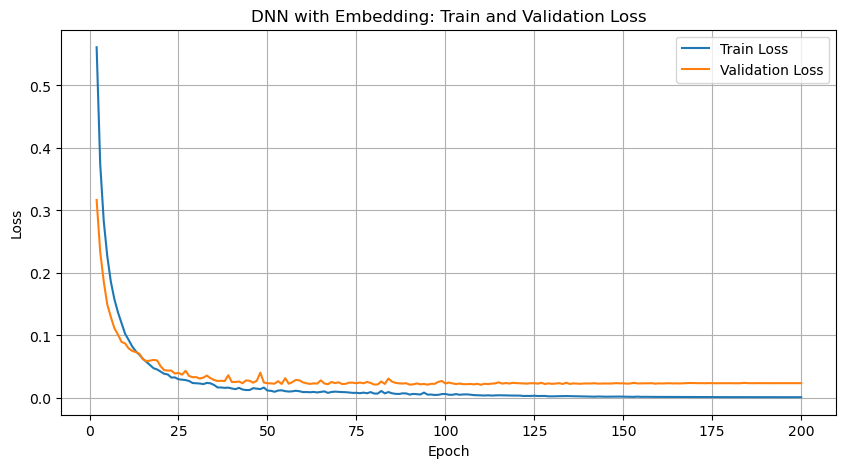

In [214]:
# Построим график изменения Loss во время обучения
plt.figure(figsize=(10, 5))

# Первую эпоху не выводим, чтобы большое начальное значение Loss
# не растягивало масштаб графика
plt.plot(
    range(2, EMBEDDING_EPOCHS + 1),
    embedding_train_loss[1:],
    label="Train Loss"
)

plt.plot(
    range(2, EMBEDDING_EPOCHS + 1),
    embedding_val_loss[1:],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN with Embedding: Train and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [215]:
# Получим предсказания модели на валидационной выборке
embedding_model.eval()

embedding_predictions = []
embedding_targets = []

with torch.no_grad():

    for (
        X_numeric_batch,
        X_categorical_batch,
        y_batch
    ) in embedding_valid_loader:

        predictions = embedding_model(
            X_numeric_batch,
            X_categorical_batch
        )

        # Сохраним предсказания и реальные значения каждого batch
        embedding_predictions.append(predictions)
        embedding_targets.append(y_batch)


# Объединим результаты всех batch
# и преобразуем их в одномерные NumPy-массивы
embedding_predictions = torch.cat(
    embedding_predictions
).numpy().flatten()

embedding_targets = torch.cat(
    embedding_targets
).numpy().flatten()

In [216]:
# Рассчитаем RMSE и R² на валидационной выборке
embedding_rmse = np.sqrt(
    mean_squared_error(
        embedding_targets,
        embedding_predictions
    )
)

embedding_r2 = r2_score(
    embedding_targets,
    embedding_predictions
)


print(f"Embedding DNN RMSE: {embedding_rmse:.4f}")
print(f"Embedding DNN R²:   {embedding_r2:.4f}")

Embedding DNN RMSE: 0.1457
Embedding DNN R²:   0.8862


In [217]:
# Найдём эпоху с минимальным Validation Loss
best_embedding_epoch = np.argmin(embedding_val_loss) + 1
best_embedding_val_loss = min(embedding_val_loss)

print(f"Лучшая эпоха: {best_embedding_epoch}")
print(
    f"Минимальный Validation Loss: "
    f"{best_embedding_val_loss:.4f}"
)

Лучшая эпоха: 110
Минимальный Validation Loss: 0.0212


#### Вывод

DNN с Embedding показала следующий результат на валидационной выборке:

- RMSE = 0.1457;
- R² = 0.8862;
- минимальный Validation Loss = 0.0212 на 110-й эпохе.

По мере обучения Train Loss продолжал снижаться, тогда как Validation Loss после достижения минимального значения перестал устойчиво улучшаться. Это указывает на постепенное переобучение модели.

Благодаря сохранению лучших весов итоговая модель использует состояние с минимальным Validation Loss, достигнутое на 110-й эпохе.

На том же фиксированном train/validation-разбиении DNN с One-Hot Encoding показала более высокий результат: RMSE = 0.1251 и R² = 0.9161.

Таким образом, в данном эксперименте использование Embedding для категориальных признаков не улучшило качество по сравнению с One-Hot Encoding. При этом Embedding представляет альтернативный способ обработки категориальных признаков непосредственно внутри нейронной сети и не требует расширения каждого категориального признака в набор One-Hot столбцов.

### 7.9 Итоговая оценка DNN с помощью кросс-валидации

Предыдущие эксперименты с DNN проводились на одной фиксированной обучающей и валидационной выборке. Это позволило последовательно исследовать архитектуру сети и параметры обучения.

Для более объективной итоговой оценки выбранной DNN проведём 5-fold кросс-валидацию.

На каждом fold preprocessing будет обучаться только на обучающей части данных, после чего будет создаваться и обучаться новая модель. Это позволит избежать утечки данных между обучающей и валидационной выборками.

#### 7.9.1 Класс итоговой DNN

Создадим отдельный класс для итоговой архитектуры DNN.

Используем конфигурацию, выбранную по результатам предыдущих экспериментов: один скрытый слой из 128 нейронов и функцию активации ELU.

In [218]:
class HousePriceDNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128
    ):
        super().__init__()

        # Полносвязная часть нейронной сети
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ELU(),
            nn.Linear(hidden_size, 1)
        )


    def forward(self, x):

        # Прямой проход через сеть
        return self.network(x)

#### 7.9.2 Подготовка к кросс-валидации

Для оценки модели используем 5-fold кросс-валидацию.

На каждой итерации исходная обучающая выборка будет разделяться на train и validation fold. Preprocessing будет заново обучаться только на train fold, после чего оба набора данных будут преобразовываться в тензоры PyTorch.

Для каждого fold также будет создаваться новая DNN со случайно инициализированными весами.

In [219]:
# Создадим разбиение для кросс-валидации
dnn_cv = KFold(
    n_splits=N_SPLITS,
    shuffle=CV_SHUFFLE,
    random_state=RANDOM_STATE if CV_SHUFFLE else None
)

#### 7.9.3 Функция кросс-валидации DNN

Создадим функцию для проведения кросс-валидации DNN.

На каждом fold функция будет отдельно обучать preprocessing, создавать новую модель и обучать её на train fold. После этого модель будет оцениваться на validation fold с помощью RMSE и R².

Такой подход позволяет оценить DNN по той же общей схеме 5-fold кросс-валидации, которая использовалась для классических моделей.

In [220]:
def cross_validate_dnn(
    X,
    y,
    preprocessor,
    cv,
    hidden_size=128,
    batch_size=16,
    epochs=200,
    learning_rate=0.001
):
    """
    Проводит кросс-валидацию DNN.

    На каждом fold отдельно обучаются preprocessing
    и новая нейронная сеть.
    """

    cv_results = []

    # Перебираем train и validation индексы каждого fold
    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X),
        start=1
    ):

        print(f"\n{'=' * 20} Fold {fold} {'=' * 20}")

        # Для каждого fold используем свой фиксированный seed
        fold_seed = RANDOM_STATE + fold


        # --------------------
        # Разделение данных
        # --------------------

        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]


        # --------------------
        # Preprocessing
        # --------------------

        # Создаём отдельную копию preprocessor для текущего fold
        fold_preprocessor = clone(preprocessor)

        # Обучаем preprocessing только на train fold
        X_fold_train_processed = (
            fold_preprocessor.fit_transform(X_fold_train)
        )

        X_fold_valid_processed = (
            fold_preprocessor.transform(X_fold_valid)
        )


        # --------------------
        # Tensor
        # --------------------

        X_fold_train_tensor = torch.tensor(
            X_fold_train_processed,
            dtype=torch.float32
        )

        X_fold_valid_tensor = torch.tensor(
            X_fold_valid_processed,
            dtype=torch.float32
        )

        y_fold_train_tensor = torch.tensor(
            y_fold_train.values,
            dtype=torch.float32
        ).reshape(-1, 1)

        y_fold_valid_tensor = torch.tensor(
            y_fold_valid.values,
            dtype=torch.float32
        ).reshape(-1, 1)


        # --------------------
        # DataLoader
        # --------------------

        fold_train_dataset = TensorDataset(
            X_fold_train_tensor,
            y_fold_train_tensor
        )

        fold_valid_dataset = TensorDataset(
            X_fold_valid_tensor,
            y_fold_valid_tensor
        )

        fold_train_loader = DataLoader(
            fold_train_dataset,
            batch_size=batch_size,
            shuffle=True,
            generator=make_generator(fold_seed)
        )

        fold_valid_loader = DataLoader(
            fold_valid_dataset,
            batch_size=batch_size,
            shuffle=False
        )


        # --------------------
        # Модель
        # --------------------

        # Размер входного слоя определяем после preprocessing,
        # так как количество OneHot-признаков может зависеть от fold
        input_size = X_fold_train_tensor.shape[1]

        # Фиксируем инициализацию весов текущего fold
        set_seed(fold_seed)
        
        fold_model = HousePriceDNN(
            input_size=input_size,
            hidden_size=hidden_size
        )


        # --------------------
        # Обучение
        # --------------------

        fold_loss_fn = nn.MSELoss()

        fold_optimizer = torch.optim.AdamW(
            fold_model.parameters(),
            lr=learning_rate
        )

        fold_scheduler = (
            torch.optim.lr_scheduler.CosineAnnealingLR(
                fold_optimizer,
                T_max=epochs,
                eta_min=1e-5
            )
        )

        train_model(
            model=fold_model,
            train_loader=fold_train_loader,
            valid_loader=fold_valid_loader,
            loss_fn=fold_loss_fn,
            optimizer=fold_optimizer,
            epochs=epochs,
            scheduler=fold_scheduler
        )


        # --------------------
        # Оценка модели
        # --------------------

        fold_model.eval()

        predictions = []

        with torch.no_grad():

            for X_batch, _ in fold_valid_loader:

                batch_predictions = fold_model(X_batch)

                predictions.append(batch_predictions)


        predictions = torch.cat(
            predictions
        ).numpy().flatten()

        y_true = y_fold_valid_tensor.numpy().flatten()


        # Метрики текущего fold
        fold_rmse = np.sqrt(
            mean_squared_error(
                y_true,
                predictions
            )
        )

        fold_r2 = r2_score(
            y_true,
            predictions
        )


        cv_results.append({
            "Fold": fold,
            "RMSE": fold_rmse,
            "R2": fold_r2
        })


        print(
            f"\nFold {fold} | "
            f"RMSE: {fold_rmse:.4f} | "
            f"R²: {fold_r2:.4f}"
        )


    return pd.DataFrame(cv_results)

#### 7.9.4 Запуск кросс-валидации

В предыдущих экспериментах на одном фиксированном train/validation-разбиении лучший результат был получен при `batch_size = 64` и 100 эпохах.

Для итоговой оценки DNN проведём отдельную 5-fold кросс-валидацию. На каждом fold preprocessing и нейронная сеть будут обучаться заново только на обучающей части данных.

Для итоговой кросс-валидации используем следующую конфигурацию:

- hidden size = 128;
- функция активации ELU;
- AdamW;
- learning rate = 0.001;
- CosineAnnealingLR;
- batch size = 16;
- 200 эпох;
- MSELoss;
- сохранение лучших весов по минимальному Validation Loss.

Параметры `batch_size = 16` и 200 эпох задаются отдельно для итоговой процедуры кросс-валидации и отличаются от настроек, показавших лучший результат на одном фиксированном validation-разбиении.

На каждом fold обучение выполняется в течение 200 эпох. При этом во время обучения сохраняются веса с минимальным Validation Loss, и после завершения всех эпох именно это лучшее состояние модели используется для оценки на validation fold.

In [221]:
dnn_cv_results = cross_validate_dnn(
    X=X_train,
    y=y_train_log,
    preprocessor=preprocessor,
    cv=dnn_cv,
    hidden_size=128,
    batch_size=16,
    epochs=200,
    learning_rate=0.001
)


==================== Fold 1 ====================
Epoch  10/200 | Train Loss: 0.0146 | Val Loss: 0.0172
Epoch  20/200 | Train Loss: 0.0100 | Val Loss: 0.0163
Epoch  30/200 | Train Loss: 0.0094 | Val Loss: 0.0161
Epoch  40/200 | Train Loss: 0.0097 | Val Loss: 0.0169
Epoch  50/200 | Train Loss: 0.0102 | Val Loss: 0.0190
Epoch  60/200 | Train Loss: 0.0117 | Val Loss: 0.0233
Epoch  70/200 | Train Loss: 0.0087 | Val Loss: 0.0189
Epoch  80/200 | Train Loss: 0.0141 | Val Loss: 0.0198
Epoch  90/200 | Train Loss: 0.0076 | Val Loss: 0.0190
Epoch 100/200 | Train Loss: 0.0050 | Val Loss: 0.0206
Epoch 110/200 | Train Loss: 0.0047 | Val Loss: 0.0191
Epoch 120/200 | Train Loss: 0.0044 | Val Loss: 0.0197
Epoch 130/200 | Train Loss: 0.0030 | Val Loss: 0.0193
Epoch 140/200 | Train Loss: 0.0030 | Val Loss: 0.0203
Epoch 150/200 | Train Loss: 0.0021 | Val Loss: 0.0205
Epoch 160/200 | Train Loss: 0.0019 | Val Loss: 0.0194
Epoch 170/200 | Train Loss: 0.0017 | Val Loss: 0.0197
Epoch 180/200 | Train Loss: 0.00

In [222]:
# Рассчитаем средние результаты кросс-валидации
dnn_cv_rmse = dnn_cv_results["RMSE"].mean()
dnn_cv_r2 = dnn_cv_results["R2"].mean()

# Рассчитаем стандартное отклонение RMSE между fold
dnn_cv_std = dnn_cv_results["RMSE"].std(ddof=0)


print(f"DNN CV RMSE: {dnn_cv_rmse:.4f}")
print(f"DNN CV R²:   {dnn_cv_r2:.4f}")
print(f"DNN CV STD:  {dnn_cv_std:.4f}")

DNN CV RMSE: 0.1388
DNN CV R²:   0.8713
DNN CV STD:  0.0256


#### Вывод

По результатам 5-fold кросс-валидации итоговая DNN показала:

- RMSE = 0.1388;
- R² = 0.8713;
- STD = 0.0256.

Средний результат кросс-валидации оказался хуже оценки, полученной ранее на одном фиксированном train/validation-разбиении, где DNN показала RMSE = 0.1251 и R² = 0.9161.

Это показывает, что качество нейронной сети заметно зависит от конкретного разбиения данных, поэтому результат на одном validation split оказался более оптимистичным.

Кросс-валидация оценивает модель на нескольких разных разбиениях и поэтому даёт более надёжное представление о её способности обобщаться на новых данных.

При этом итоговая DNN показывает достаточно хорошее качество, однако по результатам 5-fold кросс-валидации уступает лучшим бустинговым моделям проекта.

# 8. Итоговое сравнение моделей

В ходе проекта были исследованы различные подходы к решению задачи регрессии: линейные модели, методы ближайших соседей и деревьев решений, ансамблевые методы, градиентный бустинг и глубокие нейронные сети.

Для классических моделей был выполнен подбор гиперпараметров с помощью Optuna. Дополнительно были исследованы ансамбли Voting и Stacking, а также различные архитектуры и параметры DNN.

Для итогового сравнения используем результаты 5-fold кросс-валидации моделей, обученных на логарифмированной целевой переменной `SalePrice`.

### 8.1 Сравнение результатов

Соберём результаты лучших настроенных моделей, ансамблей и итоговой DNN в одну таблицу.

Для классических моделей используем результаты после подбора гиперпараметров, для ансамблей — результаты раздела 6, а для DNN — итоговую оценку 5-fold кросс-валидации.

In [223]:
final_results = [
    {
        "Model": "CatBoost + OneHot",
        "RMSE": catboost_ohe_best_rmse,
        "R2": catboost_ohe_best_r2
    },
    {
        "Model": "Stacking Regressor",
        "RMSE": stacking_rmse,
        "R2": stacking_r2
    },
    {
        "Model": "Voting Regressor (Boosting)",
        "RMSE": voting_boosting_rmse,
        "R2": voting_boosting_r2
    },
    {
        "Model": "CatBoost",
        "RMSE": catboost_best_rmse,
        "R2": catboost_best_r2
    },
    {
        "Model": "XGBoost",
        "RMSE": xgb_best_rmse,
        "R2": xgb_best_r2
    },
    {
        "Model": "LightGBM",
        "RMSE": lgbm_best_rmse,
        "R2": lgbm_best_r2
    },
    {
        "Model": "DNN",
        "RMSE": dnn_cv_rmse,
        "R2": dnn_cv_r2
    },
    {
        "Model": "Random Forest",
        "RMSE": rf_best_rmse,
        "R2": rf_best_r2
    }
]

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

final_results_df.round(4)

,Model,RMSE,R2
0,CatBoost + OneHot,0.1224,0.9027
1,Voting Regressor (Boosting),0.1225,0.9021
2,CatBoost,0.1226,0.9028
3,Stacking Regressor,0.1233,0.9013
4,XGBoost,0.1235,0.9003
5,LightGBM,0.1317,0.8874
6,DNN,0.1388,0.8713
7,Random Forest,0.1424,0.8683


### 8.2 Итоговые выводы

В ходе проекта были исследованы различные подходы к решению задачи прогнозирования стоимости домов: линейные модели, KNN, деревья решений, ансамблевые методы, градиентный бустинг и глубокие нейронные сети.

Основные результаты исследования:

- логарифмирование целевой переменной `SalePrice` сделало её распределение более симметричным; после этого все дальнейшие модели обучались и оценивались в логарифмической шкале;
- подбор гиперпараметров с помощью Optuna позволил улучшить результаты большинства классических моделей;
- лучшие результаты среди отдельных моделей показали алгоритмы градиентного бустинга;
- лучший RMSE среди рассмотренных моделей показал CatBoost с One-Hot Encoding: RMSE = 0.1224 и R² = 0.9027;
- Voting Regressor из бустинговых моделей показал очень близкий результат: RMSE = 0.1225 и R² = 0.9021;
- CatBoost с нативной обработкой категориальных признаков также показал сопоставимое качество: RMSE = 0.1226 и R² = 0.9028;
- Stacking Regressor не улучшил результат отдельных лучших моделей и получил RMSE = 0.1233 и R² = 0.9013;
- для DNN были исследованы различные архитектуры, функции активации, Batch Normalization, Dropout, оптимизаторы, scheduler и основные параметры обучения;
- итоговая DNN по результатам 5-fold кросс-валидации показала RMSE = 0.1388 и R² = 0.8713, уступив лучшим моделям градиентного бустинга;
- использование Embedding для категориальных признаков в проведённом эксперименте не улучшило качество DNN по сравнению с One-Hot Encoding.

По результатам исследования CatBoost с One-Hot Encoding показал лучший RMSE среди рассмотренных решений. При этом результаты CatBoost, Voting Regressor и CatBoost с One-Hot Encoding очень близки, поэтому усложнение модели с помощью ансамблей не привело к заметному улучшению качества.

В качестве итоговой модели проекта выбран CatBoost с One-Hot Encoding.

### 8.3 Заключение

В рамках проекта был пройден полный цикл построения модели машинного обучения для задачи регрессии: от анализа и подготовки данных до сравнения различных алгоритмов, подбора гиперпараметров и оценки качества с помощью кросс-валидации.

Эксперименты показали, что увеличение сложности модели не гарантирует улучшения качества. На относительно небольшом табличном наборе данных лучшие результаты показали решения на основе градиентного бустинга. Ансамбли Voting и Stacking дали сопоставимое качество, но не обеспечили заметного улучшения RMSE, а исследованные архитектуры глубоких нейронных сетей уступили лучшим бустинговым моделям.

Особое внимание в проекте уделялось корректной оценке качества. Использование кросс-валидации показало, что результат на одном train/validation-разбиении может быть слишком оптимистичным, что особенно хорошо проявилось при оценке DNN.

Лучший результат по основной метрике RMSE показал CatBoost с One-Hot Encoding: RMSE = 0.1224 и R² = 0.9027. Voting Regressor и CatBoost с нативной обработкой категориальных признаков показали очень близкие результаты, а более сложный Stacking Regressor не дал дополнительного улучшения качества.

В качестве итоговой модели проекта выбран CatBoost с One-Hot Encoding. Следующим этапом станет перенос выбранного решения из исследовательского notebook в отдельную структуру Python-проекта для обучения модели и построения прогнозов на новых данных.